# Occupation-resolved amplitude decay versus self-Kerr

Start with central photon numbers 2 and 3, then compare all initial occupations.
The first trace diagnostics show pure states `(2, 0, ...)` and `(3, 0, ...)`;
the Kerr comparison also includes states with additional storage photons, keeping
their full occupations in the tables and occupation-resolved view. Central photon number means **initial** manipulate-cavity
occupation; photons can subsequently move between modes.

This notebook includes the curated JOB IDs and all analysis helpers for a remote kernel.
It only reads existing documents, HDF5 files, and configurations. JOB-ID lists,
loaded traces, fitted results, and figures stay in memory; no manifest, cache,
export, configuration, database, or result file is created or modified.
Run all cells from the top. Edit the path/settings cell if the remote checkout is elsewhere.

The fitted amplitude envelope is `exp(-(t / tau_A)**beta)`, with beta=1 (exponential)
and beta=2 (Gaussian). We fit

$$|A(t)|^2 = B\,|A_{\mathrm{coherent}}(t)|^2
\exp[-2(t/\tau_A)^\beta]+C.$$

`A_coherent` comes from the same fixed-N Hamiltonian used by `data_recollecting`.
The model retains coherent beating; it never divides by theoretical zeros.
`tau_A` is an **amplitude** 1/e time, not a population lifetime. It is a phenomenological
fit conditional on the coherent model, not proof of a microscopic relaxation mechanism.
An inaccurate Hamiltonian can bias tau. Inspect trace fits, residuals, both envelopes,
and fit-window sensitivity before interpreting a trend.

The default Kerr magnitude is the curated document's K (some entries were determined
by spectrum fitting). Saved hardware K is retained separately; `KERR_SOURCE="saved"`
switches the model and plotted K together. Evolution time and g always come from
saved hardware or the documented historical Floquet config, never from nominal g.

Calibration JOB IDs are recorded as provenance. These fits use acquired `|A|^2`:
a phase-only calibration rotation leaves this quantity unchanged, so no calibration
trace is loaded or applied. Re/Im diagnostics show the acquired frame.

All complete diagonal analyzer pairs are retained on their own time grids. Shorter
occupations are not discarded merely because another trace is longer. Every unavailable
file or invalid pair is listed in the loading audit.

Individual fit intervals in the result table are approximate Jacobian intervals
assuming independent, equal-variance power residuals. Summary plots show an unweighted
arithmetic mean and +/- 1 sample standard deviation across accepted traces, including
different occupations/realizations within the stated group. These bars describe spread,
not fit confidence intervals or the standard error of the mean. A singleton has no SD
bar; n labels the number of contributing traces. Rejected/unconstrained fits stay in the table but are excluded from
trend plots. Grouping uses the actual coupling vector (not rounded document labels),
total N, mode identities, and disorder strength. The overview compares mode sets
with separate labels; the following view separates them into panels. The actual g range is labeled;
the full coupling vector and disorder detunings remain available in the tables.

Method references: [SciPy least-squares fitting](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.least_squares.html)
and [survival amplitude / density-of-states relation](https://arxiv.org/abs/2108.10957).


## Paths and analysis settings

In [16]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# Set this only if the remote kernel starts outside the repository.
REPO_ROOT_OVERRIDE = None
_candidates = [Path.cwd(), *Path.cwd().parents, Path(r"C:\python\multimode_expts")]
REPO_ROOT = (Path(REPO_ROOT_OVERRIDE).expanduser() if REPO_ROOT_OVERRIDE else
             next((p for p in _candidates if (p / "experiments/qsim/floquet_dark_mode_readout.py").is_file()), Path.cwd()))
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

DATA_ROOT = Path(r"C:\experiments")
CONFIG_VERSIONS_DIR = None  # Set an existing directory to override automatic lookup.
_config_candidates = [REPO_ROOT / "configs/versions", Path(r"S:\Multimode\BF5_config_versions")]
CONFIG_VERSIONS_DIR = (
    Path(CONFIG_VERSIONS_DIR).expanduser() if CONFIG_VERSIONS_DIR is not None else
    next((p for p in _config_candidates
          if any((p / "floquet_storage_swap").glob("CFG-FL-*.csv"))),
         _config_candidates[0])
)
CLOCK_SNAPSHOT_PATH = REPO_ROOT / "configs/soccfg_snapshot.json"
MANIFEST_PATH = REPO_ROOT / "docs/spectroscopy job id compilation/Only JOB IDs for Agents.md"
KERR_SOURCE = "document"  # "document" or "saved"; never inferred from decay fits.
DATASET_IDS = None       # None loads every curated dataset; e.g. ["1.3", "2.1", "4.1"].
FIT_MIN_US = 0.0
FIT_MAX_US = None        # None uses each trace's full available time window.
PLOT_ENVELOPE = "exponential"  # Switch to "gaussian" to compare model dependence.
TRACE_DATASET_IDS = None
TRACE_PURE_CENTRAL = True  # First diagnostics; False also displays storage-populated states.
KERR_PURE_CENTRAL = False  # False includes n_M1=2 with another photon in a storage mode.
PHOTON_VIEW_MODE = "M1"  # Any acquired mode, e.g. "S1" or "S4".
print(f"Repository: {REPO_ROOT}\nHDF5 root: {DATA_ROOT}\nConfig versions: {CONFIG_VERSIONS_DIR}\nKerr source: {KERR_SOURCE}")


Repository: C:\python\multimode_expts
HDF5 root: C:\experiments
Config versions: C:\python\multimode_expts\configs\versions
Kerr source: document


## Curated JOB IDs and helper definitions

The JOB IDs included below make the notebook usable even if the source document is absent in the remote checkout. Lists are kept in memory only; no manifest file is saved. Each helper cell is ordinary Python; no other notebook is executed.

In [17]:
"""Read the curated spectroscopy JOB-ID document without executing its contents."""

from __future__ import annotations

import ast
from pathlib import Path
import re


_NUMBER = r"[+-]?(?:\d+(?:\.\d*)?|\.\d+)"
_GROUP = re.compile(
    rf"#\s+(\d+)\.\s*g\s*=\s*({_NUMBER})\s*kHz\s*,\s*"
    rf"K\s*=\s*({_NUMBER})\s*kHz\s*$"
)
_SUBGROUP = re.compile(r"##\s+([\d-]+)\.\s*(.+)$")
_FIELD = re.compile(
    r"-\s*(Folder|Foler|Config|Calibration_job_ids|Spec_job_ids)"
    r"(?:\s*:\s*|\s+)(.*)$"
)
_JOB_ID = re.compile(r"JOB-\d{8}-\d{5}$")
_QUOTES = str.maketrans({"\u2018": "'", "\u2019": "'", "\u201c": '"', "\u201d": '"'})


def _job_list(value, fail, label):
    if not isinstance(value, (list, tuple)) or not value:
        fail(f"{label} must contain a nonempty list of JOB IDs")
    if any(not isinstance(job, str) or not _JOB_ID.fullmatch(job) for job in value):
        fail(f"{label} contains a malformed JOB ID")
    if len(set(value)) != len(value):
        fail(f"{label} contains duplicate JOB IDs")
    return list(value)


def _job_value(text, fail, label):
    text = text.translate(_QUOTES).strip()
    if text.startswith(("[", "{", "(")):
        try:
            node = ast.parse(text, mode="eval")
            value = ast.literal_eval(node)
        except (SyntaxError, ValueError, TypeError) as error:
            fail(f"invalid {label}: {error}")
        if isinstance(node.body, ast.Dict):
            keys = [ast.literal_eval(key) for key in node.body.keys]
            if len(set(keys)) != len(keys):
                fail(f"{label} contains duplicate realization keys")
        return value
    # The first sections use plain comma-separated IDs, without quotes/brackets.
    values = [value.strip() for value in text.split(",")]
    if values and not values[-1]:
        values.pop()
    return _job_list(values, fail, label)


def load_decay_manifest(path):
    """Return one record per documented dataset, in source order.

    Records contain ``dataset_id`` (main/subsection numbers), ``group_title``,
    ``dataset_title``, ``nominal_g_kHz``, ``nominal_K_kHz``, ``folder``,
    ``floquet_config_version``, ``calibration_job_ids``, and
    ``spectroscopy_job_ids_by_r``. Dict keys are bookkeeping display indices;
    a plain JOB list is represented by ``{None: ids}``. They are not asserted
    equal to acquisition realization metadata. ``documented_total_photons``
    and ``documented_disorder`` are None when the title does not specify them.

    ``source_path``, ``source_line``, ``source_end_line``, and
    ``source_field_lines`` retain provenance. The nominal numbers are copied
    from the document, with their written signs; they do not replace HDF5 or
    station/config values in time-axis construction or physical modeling.
    Known typography quirks are accepted; malformed/incomplete blocks raise
    ValueError with the source location instead of being silently skipped.
    """
    path = Path(path).expanduser().resolve()
    lines = path.read_text(encoding="utf-8-sig").splitlines()
    records = []
    group = None
    block = None
    field = None

    def finish(end_line):
        nonlocal block, field
        if block is None:
            return

        def fail(message):
            raise ValueError(f"{path}:{block['source_line']}: {message}")

        fields = block.pop("fields")
        required = {"Folder", "Config", "Calibration_job_ids", "Spec_job_ids"}
        missing = required.difference(fields)
        if missing:
            fail(f"missing required fields: {', '.join(sorted(missing))}")
        values = {key: "\n".join(value).strip() for key, value in fields.items()}
        folder = values["Folder"].translate(_QUOTES).strip("\"' ")
        config = values["Config"].translate(_QUOTES).strip("\"' ")
        if not re.fullmatch(r"[A-Za-z0-9_.-]+", folder) or folder in {".", ".."}:
            fail(f"invalid project folder: {folder!r}")
        if not re.fullmatch(r"CFG-FL-\d{8}-\d{5}", config):
            fail(f"invalid Floquet config version: {config!r}")
        calibration = _job_list(
            _job_value(values["Calibration_job_ids"], fail, "Calibration_job_ids"),
            fail, "Calibration_job_ids",
        )
        spectroscopy = _job_value(values["Spec_job_ids"], fail, "Spec_job_ids")
        if isinstance(spectroscopy, dict):
            if not spectroscopy or any(type(r) is not int or r < 0 for r in spectroscopy):
                fail("Spec_job_ids dict requires nonnegative integer display indices")
            spectroscopy = {
                r: _job_list(ids, fail, f"Spec_job_ids[{r}]")
                for r, ids in spectroscopy.items()
            }
        else:
            spectroscopy = {None: _job_list(spectroscopy, fail, "Spec_job_ids")}
        all_spec = [job for ids in spectroscopy.values() for job in ids]
        if len(set(all_spec)) != len(all_spec):
            fail("a spectroscopy JOB ID appears under multiple display indices")
        if set(calibration).intersection(all_spec):
            fail("calibration and spectroscopy JOB IDs overlap")
        title = block["dataset_title"]
        n_match = re.search(r"\bN\s*=\s*(\d+)\b", title)
        disorder = (
            "disorderless" if re.search(r"\bDisorderless\b", title, re.I)
            else "disordered" if re.search(r"\bDisordered\b", title, re.I)
            else None
        )
        block.update(
            folder=folder,
            floquet_config_version=config,
            calibration_job_ids=calibration,
            spectroscopy_job_ids_by_r=spectroscopy,
            documented_total_photons=int(n_match.group(1)) if n_match else None,
            documented_disorder=disorder,
            source_end_line=end_line,
        )
        records.append(block)
        block = None
        field = None

    def start_block(line_number, subgroup_id=None, title=None):
        return dict(
            dataset_id=group["group_id"] + (f".{subgroup_id}" if subgroup_id else ""),
            group_id=group["group_id"],
            group_title=group["group_title"],
            dataset_title=title or group["group_title"],
            nominal_g_kHz=group["nominal_g_kHz"],
            nominal_K_kHz=group["nominal_K_kHz"],
            source_path=str(path),
            source_line=line_number,
            source_field_lines={},
            fields={},
        )

    for line_number, raw in enumerate(lines, 1):
        line = raw.strip()
        if not line:
            continue
        match = _GROUP.fullmatch(line)
        if match:
            finish(line_number - 1)
            group = dict(
                group_id=match[1], group_title=line[2:], source_line=line_number,
                nominal_g_kHz=float(match[2]), nominal_K_kHz=float(match[3]),
            )
            continue
        if group is None:
            if re.match(r"#\s+\d+\.", line):
                raise ValueError(f"{path}:{line_number}: invalid g/K group heading")
            continue  # The introductory explanation is not a dataset.
        match = _SUBGROUP.fullmatch(line)
        if match:
            finish(line_number - 1)
            block = start_block(line_number, match[1], match[2])
            continue
        if line.startswith("#"):
            raise ValueError(f"{path}:{line_number}: unrecognized dataset heading: {line}")
        match = _FIELD.fullmatch(line)
        if match:
            if block is None:
                block = start_block(group["source_line"])
            field = "Folder" if match[1] == "Foler" else match[1]
            if field in block["fields"]:
                raise ValueError(f"{path}:{line_number}: duplicate field {field}")
            block["fields"][field] = [match[2]]
            block["source_field_lines"][field] = line_number
            continue
        if block is None or field is None or line.startswith("-"):
            raise ValueError(f"{path}:{line_number}: unrecognized dataset content: {line}")
        block["fields"][field].append(line)
    finish(len(lines))
    if not records:
        raise ValueError(f"{path}: no documented datasets found")
    if len({record["dataset_id"] for record in records}) != len(records):
        raise ValueError(f"{path}: duplicate dataset section identifiers")
    return records


In [18]:
MANIFEST_SNAPSHOT_SHA256 = '8df92ceb67cb3d1a0def770fb6c3de2e187706a9e2cf9d70711dcc0cef123f91'
MANIFEST_SNAPSHOT = [{'dataset_id': '1.1', 'group_id': '1', 'group_title': '1. g = 15 kHz, K = 19.2 kHz', 'dataset_title': 'Disordered Full N = 1', 'nominal_g_kHz': 15.0, 'nominal_K_kHz': 19.2, 'source_path': 'docs/spectroscopy job id compilation/Only JOB IDs for Agents.md', 'source_line': 16, 'source_field_lines': {'Folder': 18, 'Config': 19, 'Calibration_job_ids': 20, 'Spec_job_ids': 21}, 'folder': '260526_qsim_darkmode', 'floquet_config_version': 'CFG-FL-20260717-00028', 'calibration_job_ids': ['JOB-20260722-00557', 'JOB-20260722-00558', 'JOB-20260722-00559', 'JOB-20260722-00560', 'JOB-20260722-00561', 'JOB-20260722-00562', 'JOB-20260722-00563', 'JOB-20260722-00564', 'JOB-20260722-00565', 'JOB-20260722-00566'], 'spectroscopy_job_ids_by_r': {None: ['JOB-20260722-00577', 'JOB-20260722-00579', 'JOB-20260722-00581', 'JOB-20260722-00583', 'JOB-20260722-00585', 'JOB-20260722-00587', 'JOB-20260722-00589', 'JOB-20260722-00591', 'JOB-20260722-00593', 'JOB-20260722-00595']}, 'documented_total_photons': 1, 'documented_disorder': 'disordered', 'source_end_line': 22}, {'dataset_id': '1.2', 'group_id': '1', 'group_title': '1. g = 15 kHz, K = 19.2 kHz', 'dataset_title': 'Disorderless Partial N =2', 'nominal_g_kHz': 15.0, 'nominal_K_kHz': 19.2, 'source_path': 'docs/spectroscopy job id compilation/Only JOB IDs for Agents.md', 'source_line': 23, 'source_field_lines': {'Folder': 25, 'Config': 26, 'Calibration_job_ids': 27, 'Spec_job_ids': 28}, 'folder': '260526_qsim_darkmode', 'floquet_config_version': 'CFG-FL-20260722-00001', 'calibration_job_ids': ['JOB-20260722-00035', 'JOB-20260722-00036', 'JOB-20260722-00037', 'JOB-20260722-00038', 'JOB-20260722-00039', 'JOB-20260722-00040', 'JOB-20260722-00041', 'JOB-20260722-00042', 'JOB-20260722-00043', 'JOB-20260722-00044', 'JOB-20260722-00045', 'JOB-20260722-00046', 'JOB-20260722-00047', 'JOB-20260722-00048', 'JOB-20260722-00049', 'JOB-20260722-00050', 'JOB-20260722-00051', 'JOB-20260722-00052', 'JOB-20260722-00053', 'JOB-20260722-00054', 'JOB-20260722-00055', 'JOB-20260722-00056', 'JOB-20260722-00057', 'JOB-20260722-00058', 'JOB-20260722-00059', 'JOB-20260722-00060', 'JOB-20260722-00061', 'JOB-20260722-00062', 'JOB-20260722-00063', 'JOB-20260722-00064'], 'spectroscopy_job_ids_by_r': {None: ['JOB-20260722-00215', 'JOB-20260722-00216', 'JOB-20260722-00217', 'JOB-20260722-00218', 'JOB-20260722-00219', 'JOB-20260722-00220', 'JOB-20260722-00221', 'JOB-20260722-00222', 'JOB-20260722-00223', 'JOB-20260722-00224', 'JOB-20260722-00225', 'JOB-20260722-00226', 'JOB-20260722-00227', 'JOB-20260722-00228', 'JOB-20260722-00229', 'JOB-20260722-00231', 'JOB-20260722-00232', 'JOB-20260722-00233', 'JOB-20260722-00234', 'JOB-20260722-00235', 'JOB-20260722-00236', 'JOB-20260722-00237', 'JOB-20260722-00238', 'JOB-20260722-00239', 'JOB-20260722-00240', 'JOB-20260722-00241', 'JOB-20260722-00242', 'JOB-20260722-00243']}, 'documented_total_photons': 2, 'documented_disorder': 'disorderless', 'source_end_line': 29}, {'dataset_id': '1.2-1', 'group_id': '1', 'group_title': '1. g = 15 kHz, K = 19.2 kHz', 'dataset_title': 'Missing One element for N =2', 'nominal_g_kHz': 15.0, 'nominal_K_kHz': 19.2, 'source_path': 'docs/spectroscopy job id compilation/Only JOB IDs for Agents.md', 'source_line': 30, 'source_field_lines': {'Folder': 32, 'Config': 33, 'Calibration_job_ids': 34, 'Spec_job_ids': 35}, 'folder': '260526_qsim_darkmode', 'floquet_config_version': 'CFG-FL-20260722-00001', 'calibration_job_ids': ['JOB-20260722-00425', 'JOB-20260722-00426'], 'spectroscopy_job_ids_by_r': {None: ['JOB-20260722-00452', 'JOB-20260722-00454']}, 'documented_total_photons': 2, 'documented_disorder': None, 'source_end_line': 36}, {'dataset_id': '1.3', 'group_id': '1', 'group_title': '1. g = 15 kHz, K = 19.2 kHz', 'dataset_title': 'Disorderless Full N = 3', 'nominal_g_kHz': 15.0, 'nominal_K_kHz': 19.2, 'source_path': 'docs/spectroscopy job id compilation/Only JOB IDs for Agents.md', 'source_line': 37, 'source_field_lines': {'Folder': 39, 'Config': 40, 'Calibration_job_ids': 41, 'Spec_job_ids': 42}, 'folder': '260526_qsim_darkmode', 'floquet_config_version': 'CFG-FL-20260722-00001', 'calibration_job_ids': ['JOB-20260722-00683', 'JOB-20260722-00684', 'JOB-20260722-00685', 'JOB-20260722-00686', 'JOB-20260722-00687', 'JOB-20260722-00688', 'JOB-20260722-00689', 'JOB-20260722-00690', 'JOB-20260722-00691', 'JOB-20260722-00692', 'JOB-20260722-00693', 'JOB-20260722-00694', 'JOB-20260722-00695', 'JOB-20260722-00696', 'JOB-20260722-00697', 'JOB-20260722-00698', 'JOB-20260722-00699', 'JOB-20260722-00700', 'JOB-20260722-00701', 'JOB-20260722-00702', 'JOB-20260722-00703', 'JOB-20260722-00704', 'JOB-20260722-00705', 'JOB-20260722-00706', 'JOB-20260722-00707', 'JOB-20260722-00708', 'JOB-20260722-00709', 'JOB-20260722-00710', 'JOB-20260722-00711', 'JOB-20260722-00712', 'JOB-20260723-00001', 'JOB-20260723-00002', 'JOB-20260723-00003', 'JOB-20260723-00004', 'JOB-20260723-00005', 'JOB-20260723-00006', 'JOB-20260723-00007', 'JOB-20260723-00008', 'JOB-20260723-00009', 'JOB-20260723-00010', 'JOB-20260723-00011', 'JOB-20260723-00012', 'JOB-20260723-00013', 'JOB-20260723-00014', 'JOB-20260723-00015', 'JOB-20260723-00016', 'JOB-20260723-00017', 'JOB-20260723-00018', 'JOB-20260723-00019', 'JOB-20260723-00020', 'JOB-20260723-00021', 'JOB-20260723-00022', 'JOB-20260723-00023', 'JOB-20260723-00024', 'JOB-20260723-00025', 'JOB-20260723-00026', 'JOB-20260723-00027', 'JOB-20260723-00028', 'JOB-20260723-00029', 'JOB-20260723-00030', 'JOB-20260723-00031', 'JOB-20260723-00032', 'JOB-20260723-00033', 'JOB-20260723-00034', 'JOB-20260723-00035', 'JOB-20260723-00036', 'JOB-20260723-00037', 'JOB-20260723-00038', 'JOB-20260723-00039', 'JOB-20260723-00040'], 'spectroscopy_job_ids_by_r': {None: ['JOB-20260723-00048', 'JOB-20260723-00049', 'JOB-20260723-00050', 'JOB-20260723-00051', 'JOB-20260723-00052', 'JOB-20260723-00053', 'JOB-20260723-00054', 'JOB-20260723-00055', 'JOB-20260723-00056', 'JOB-20260723-00057', 'JOB-20260723-00058', 'JOB-20260723-00059', 'JOB-20260723-00060', 'JOB-20260723-00061', 'JOB-20260723-00062', 'JOB-20260723-00063', 'JOB-20260723-00064', 'JOB-20260723-00065', 'JOB-20260723-00066', 'JOB-20260723-00067', 'JOB-20260723-00068', 'JOB-20260723-00069', 'JOB-20260723-00070', 'JOB-20260723-00071', 'JOB-20260723-00072', 'JOB-20260723-00073', 'JOB-20260723-00074', 'JOB-20260723-00075', 'JOB-20260723-00076', 'JOB-20260723-00077', 'JOB-20260723-00078', 'JOB-20260723-00079', 'JOB-20260723-00080', 'JOB-20260723-00081', 'JOB-20260723-00082', 'JOB-20260723-00083', 'JOB-20260723-00084', 'JOB-20260723-00085', 'JOB-20260723-00087', 'JOB-20260723-00089', 'JOB-20260723-00091', 'JOB-20260723-00093', 'JOB-20260723-00095', 'JOB-20260723-00097', 'JOB-20260723-00099', 'JOB-20260723-00101', 'JOB-20260723-00103', 'JOB-20260723-00105', 'JOB-20260723-00107', 'JOB-20260723-00109', 'JOB-20260723-00111', 'JOB-20260723-00113', 'JOB-20260723-00115', 'JOB-20260723-00117', 'JOB-20260723-00119', 'JOB-20260723-00121', 'JOB-20260723-00123', 'JOB-20260723-00125', 'JOB-20260723-00127', 'JOB-20260723-00129', 'JOB-20260723-00131', 'JOB-20260723-00133', 'JOB-20260723-00135', 'JOB-20260723-00137', 'JOB-20260723-00139', 'JOB-20260723-00141', 'JOB-20260723-00143', 'JOB-20260723-00145', 'JOB-20260723-00147', 'JOB-20260723-00149']}, 'documented_total_photons': 3, 'documented_disorder': 'disorderless', 'source_end_line': 43}, {'dataset_id': '1.4', 'group_id': '1', 'group_title': '1. g = 15 kHz, K = 19.2 kHz', 'dataset_title': 'Disorderless Full N = 1', 'nominal_g_kHz': 15.0, 'nominal_K_kHz': 19.2, 'source_path': 'docs/spectroscopy job id compilation/Only JOB IDs for Agents.md', 'source_line': 44, 'source_field_lines': {'Folder': 46, 'Config': 47, 'Calibration_job_ids': 48, 'Spec_job_ids': 49}, 'folder': '260526_qsim_darkmode', 'floquet_config_version': 'CFG-FL-20260717-00028', 'calibration_job_ids': ['JOB-20260721-00423', 'JOB-20260721-00424', 'JOB-20260721-00425', 'JOB-20260721-00426', 'JOB-20260721-00427', 'JOB-20260721-00428', 'JOB-20260721-00429', 'JOB-20260721-00430', 'JOB-20260721-00431', 'JOB-20260721-00432'], 'spectroscopy_job_ids_by_r': {None: ['JOB-20260722-00005', 'JOB-20260722-00006', 'JOB-20260722-00007', 'JOB-20260722-00008', 'JOB-20260722-00009', 'JOB-20260722-00010', 'JOB-20260722-00011', 'JOB-20260722-00012', 'JOB-20260722-00013', 'JOB-20260722-00014']}, 'documented_total_photons': 1, 'documented_disorder': 'disorderless', 'source_end_line': 50}, {'dataset_id': '2.1', 'group_id': '2', 'group_title': '2. g = 8.61 kHz, K = 5.7 kHz', 'dataset_title': 'Disorderless Full N = 3', 'nominal_g_kHz': 8.61, 'nominal_K_kHz': 5.7, 'source_path': 'docs/spectroscopy job id compilation/Only JOB IDs for Agents.md', 'source_line': 53, 'source_field_lines': {'Folder': 55, 'Config': 56, 'Calibration_job_ids': 57, 'Spec_job_ids': 58}, 'folder': '260526_qsim_darkmode', 'floquet_config_version': 'CFG-FL-20260814-00076', 'calibration_job_ids': ['JOB-20260815-00113', 'JOB-20260815-00114', 'JOB-20260815-00115', 'JOB-20260815-00116', 'JOB-20260815-00117', 'JOB-20260815-00118', 'JOB-20260815-00119', 'JOB-20260815-00120', 'JOB-20260815-00121', 'JOB-20260815-00122', 'JOB-20260815-00123', 'JOB-20260815-00124', 'JOB-20260815-00125', 'JOB-20260815-00126', 'JOB-20260815-00127', 'JOB-20260815-00128', 'JOB-20260815-00129', 'JOB-20260815-00130', 'JOB-20260815-00131', 'JOB-20260815-00132', 'JOB-20260815-00133', 'JOB-20260815-00134', 'JOB-20260815-00135', 'JOB-20260815-00136', 'JOB-20260815-00137', 'JOB-20260815-00138', 'JOB-20260815-00139', 'JOB-20260815-00140', 'JOB-20260815-00141', 'JOB-20260815-00142', 'JOB-20260815-00143', 'JOB-20260815-00144', 'JOB-20260815-00145', 'JOB-20260815-00146', 'JOB-20260815-00147', 'JOB-20260815-00148', 'JOB-20260815-00149', 'JOB-20260815-00150', 'JOB-20260815-00151', 'JOB-20260815-00152', 'JOB-20260815-00153', 'JOB-20260815-00154', 'JOB-20260815-00155', 'JOB-20260815-00156', 'JOB-20260815-00157', 'JOB-20260815-00158', 'JOB-20260815-00159', 'JOB-20260815-00160', 'JOB-20260815-00161', 'JOB-20260815-00162', 'JOB-20260815-00163', 'JOB-20260815-00164', 'JOB-20260815-00165', 'JOB-20260815-00166', 'JOB-20260815-00167', 'JOB-20260815-00168', 'JOB-20260815-00169', 'JOB-20260815-00170', 'JOB-20260815-00171', 'JOB-20260815-00172', 'JOB-20260815-00173', 'JOB-20260815-00174', 'JOB-20260815-00175', 'JOB-20260815-00176', 'JOB-20260815-00177', 'JOB-20260815-00178', 'JOB-20260815-00179', 'JOB-20260815-00180', 'JOB-20260815-00181', 'JOB-20260815-00182'], 'spectroscopy_job_ids_by_r': {None: ['JOB-20260815-00183', 'JOB-20260815-00184', 'JOB-20260815-00185', 'JOB-20260815-00186', 'JOB-20260815-00187', 'JOB-20260815-00188', 'JOB-20260815-00189', 'JOB-20260815-00190', 'JOB-20260815-00191', 'JOB-20260815-00192', 'JOB-20260815-00193', 'JOB-20260815-00194', 'JOB-20260815-00195', 'JOB-20260815-00196', 'JOB-20260815-00197', 'JOB-20260815-00198', 'JOB-20260815-00199', 'JOB-20260815-00200', 'JOB-20260815-00201', 'JOB-20260815-00202', 'JOB-20260815-00203', 'JOB-20260815-00204', 'JOB-20260815-00205', 'JOB-20260815-00206', 'JOB-20260815-00207', 'JOB-20260815-00208', 'JOB-20260815-00209', 'JOB-20260815-00210', 'JOB-20260815-00211', 'JOB-20260815-00212', 'JOB-20260815-00213', 'JOB-20260815-00214', 'JOB-20260815-00215', 'JOB-20260815-00216', 'JOB-20260815-00217', 'JOB-20260815-00218', 'JOB-20260815-00219', 'JOB-20260815-00220', 'JOB-20260815-00221', 'JOB-20260815-00222', 'JOB-20260815-00223', 'JOB-20260815-00224', 'JOB-20260815-00225', 'JOB-20260815-00226', 'JOB-20260815-00227', 'JOB-20260815-00228', 'JOB-20260815-00229', 'JOB-20260815-00230', 'JOB-20260815-00231', 'JOB-20260815-00232', 'JOB-20260815-00233', 'JOB-20260815-00234', 'JOB-20260815-00235', 'JOB-20260815-00236', 'JOB-20260815-00237', 'JOB-20260815-00238', 'JOB-20260815-00239', 'JOB-20260815-00240', 'JOB-20260815-00241', 'JOB-20260815-00242', 'JOB-20260816-00001', 'JOB-20260816-00002', 'JOB-20260816-00003', 'JOB-20260816-00004', 'JOB-20260816-00005', 'JOB-20260816-00006', 'JOB-20260816-00007', 'JOB-20260816-00008', 'JOB-20260816-00009', 'JOB-20260816-00010']}, 'documented_total_photons': 3, 'documented_disorder': 'disorderless', 'source_end_line': 59}, {'dataset_id': '2.2', 'group_id': '2', 'group_title': '2. g = 8.61 kHz, K = 5.7 kHz', 'dataset_title': 'Disordered Partial N = 3', 'nominal_g_kHz': 8.61, 'nominal_K_kHz': 5.7, 'source_path': 'docs/spectroscopy job id compilation/Only JOB IDs for Agents.md', 'source_line': 60, 'source_field_lines': {'Folder': 62, 'Config': 63, 'Calibration_job_ids': 64, 'Spec_job_ids': 65}, 'folder': '260526_qsim_darkmode', 'floquet_config_version': 'CFG-FL-20260814-00076', 'calibration_job_ids': ['JOB-20260815-00113', 'JOB-20260815-00114', 'JOB-20260815-00115', 'JOB-20260815-00116', 'JOB-20260815-00117', 'JOB-20260815-00118', 'JOB-20260815-00119', 'JOB-20260815-00120', 'JOB-20260815-00121', 'JOB-20260815-00122', 'JOB-20260815-00123', 'JOB-20260815-00124', 'JOB-20260815-00125', 'JOB-20260815-00126', 'JOB-20260815-00127', 'JOB-20260815-00128', 'JOB-20260815-00129', 'JOB-20260815-00130', 'JOB-20260815-00131', 'JOB-20260815-00132', 'JOB-20260815-00133', 'JOB-20260815-00134', 'JOB-20260815-00135', 'JOB-20260815-00136', 'JOB-20260815-00137', 'JOB-20260815-00138', 'JOB-20260815-00139', 'JOB-20260815-00140', 'JOB-20260815-00141', 'JOB-20260815-00142', 'JOB-20260815-00143', 'JOB-20260815-00144', 'JOB-20260815-00145', 'JOB-20260815-00146', 'JOB-20260815-00147', 'JOB-20260815-00148', 'JOB-20260815-00149', 'JOB-20260815-00150', 'JOB-20260815-00151', 'JOB-20260815-00152', 'JOB-20260815-00153', 'JOB-20260815-00154', 'JOB-20260815-00155', 'JOB-20260815-00156', 'JOB-20260815-00157', 'JOB-20260815-00158', 'JOB-20260815-00159', 'JOB-20260815-00160', 'JOB-20260815-00161', 'JOB-20260815-00162', 'JOB-20260815-00163', 'JOB-20260815-00164', 'JOB-20260815-00165', 'JOB-20260815-00166', 'JOB-20260815-00167', 'JOB-20260815-00168', 'JOB-20260815-00169', 'JOB-20260815-00170', 'JOB-20260815-00171', 'JOB-20260815-00172', 'JOB-20260815-00173', 'JOB-20260815-00174', 'JOB-20260815-00175', 'JOB-20260815-00176', 'JOB-20260815-00177', 'JOB-20260815-00178', 'JOB-20260815-00179', 'JOB-20260815-00180', 'JOB-20260815-00181', 'JOB-20260815-00182'], 'spectroscopy_job_ids_by_r': {0: ['JOB-20260816-00013', 'JOB-20260816-00014', 'JOB-20260816-00015', 'JOB-20260816-00016', 'JOB-20260816-00017', 'JOB-20260816-00018', 'JOB-20260816-00019', 'JOB-20260816-00020', 'JOB-20260816-00021', 'JOB-20260816-00022', 'JOB-20260816-00023', 'JOB-20260816-00024', 'JOB-20260816-00025', 'JOB-20260816-00026', 'JOB-20260816-00027', 'JOB-20260816-00028', 'JOB-20260816-00029', 'JOB-20260816-00030', 'JOB-20260816-00031', 'JOB-20260816-00032'], 1: ['JOB-20260816-00033', 'JOB-20260816-00034', 'JOB-20260816-00035', 'JOB-20260816-00036', 'JOB-20260816-00037', 'JOB-20260816-00038', 'JOB-20260816-00039', 'JOB-20260816-00040', 'JOB-20260816-00041', 'JOB-20260816-00042', 'JOB-20260816-00043', 'JOB-20260816-00044', 'JOB-20260816-00045', 'JOB-20260816-00046', 'JOB-20260816-00047', 'JOB-20260816-00048', 'JOB-20260816-00049', 'JOB-20260816-00050', 'JOB-20260816-00051', 'JOB-20260816-00052'], 2: ['JOB-20260816-00053', 'JOB-20260816-00054', 'JOB-20260816-00055', 'JOB-20260816-00056', 'JOB-20260816-00057', 'JOB-20260816-00058', 'JOB-20260816-00059', 'JOB-20260816-00060', 'JOB-20260816-00061', 'JOB-20260816-00062', 'JOB-20260816-00063', 'JOB-20260816-00064', 'JOB-20260816-00065', 'JOB-20260816-00066', 'JOB-20260816-00067', 'JOB-20260816-00068', 'JOB-20260816-00069', 'JOB-20260816-00070', 'JOB-20260816-00071', 'JOB-20260816-00072'], 3: ['JOB-20260817-00001', 'JOB-20260817-00002', 'JOB-20260817-00003', 'JOB-20260817-00004', 'JOB-20260817-00005', 'JOB-20260817-00006', 'JOB-20260817-00007', 'JOB-20260817-00008', 'JOB-20260817-00009', 'JOB-20260817-00010', 'JOB-20260817-00011', 'JOB-20260817-00012', 'JOB-20260817-00013', 'JOB-20260817-00014', 'JOB-20260817-00015', 'JOB-20260817-00016', 'JOB-20260817-00017', 'JOB-20260817-00018', 'JOB-20260817-00019', 'JOB-20260817-00020']}, 'documented_total_photons': 3, 'documented_disorder': 'disordered', 'source_end_line': 71}, {'dataset_id': '3.1', 'group_id': '3', 'group_title': '3. g = 15.2 kHz, K = 44.96 kHz', 'dataset_title': 'Disordered Partial N = 3', 'nominal_g_kHz': 15.2, 'nominal_K_kHz': 44.96, 'source_path': 'docs/spectroscopy job id compilation/Only JOB IDs for Agents.md', 'source_line': 74, 'source_field_lines': {'Folder': 76, 'Config': 77, 'Calibration_job_ids': 78, 'Spec_job_ids': 79}, 'folder': '260818_qsim_spectroscopy', 'floquet_config_version': 'CFG-FL-20260825-00097', 'calibration_job_ids': ['JOB-20260828-00289', 'JOB-20260828-00290', 'JOB-20260828-00291', 'JOB-20260828-00292', 'JOB-20260828-00293', 'JOB-20260828-00294', 'JOB-20260828-00295', 'JOB-20260828-00296', 'JOB-20260828-00297', 'JOB-20260828-00298', 'JOB-20260828-00299', 'JOB-20260828-00300', 'JOB-20260828-00301', 'JOB-20260828-00302', 'JOB-20260828-00303', 'JOB-20260828-00304', 'JOB-20260828-00305', 'JOB-20260828-00306', 'JOB-20260828-00307', 'JOB-20260828-00308', 'JOB-20260828-00309', 'JOB-20260828-00310', 'JOB-20260828-00311', 'JOB-20260828-00312', 'JOB-20260828-00313', 'JOB-20260828-00314', 'JOB-20260828-00315', 'JOB-20260828-00316', 'JOB-20260828-00317', 'JOB-20260828-00318', 'JOB-20260828-00319', 'JOB-20260828-00320', 'JOB-20260828-00321', 'JOB-20260828-00322', 'JOB-20260828-00323', 'JOB-20260828-00324', 'JOB-20260828-00325', 'JOB-20260828-00326', 'JOB-20260828-00327', 'JOB-20260828-00328', 'JOB-20260828-00329', 'JOB-20260828-00330', 'JOB-20260828-00331', 'JOB-20260828-00332', 'JOB-20260828-00333', 'JOB-20260828-00334', 'JOB-20260828-00335', 'JOB-20260828-00336', 'JOB-20260828-00337', 'JOB-20260828-00338', 'JOB-20260828-00339', 'JOB-20260828-00340', 'JOB-20260828-00341', 'JOB-20260828-00342', 'JOB-20260828-00343', 'JOB-20260828-00344', 'JOB-20260828-00345', 'JOB-20260828-00346', 'JOB-20260828-00347', 'JOB-20260828-00348', 'JOB-20260828-00349', 'JOB-20260828-00350', 'JOB-20260828-00351', 'JOB-20260828-00352', 'JOB-20260828-00353', 'JOB-20260828-00354', 'JOB-20260828-00355', 'JOB-20260828-00356', 'JOB-20260828-00357', 'JOB-20260828-00358'], 'spectroscopy_job_ids_by_r': {0: ['JOB-20260829-00016', 'JOB-20260829-00017', 'JOB-20260829-00018', 'JOB-20260829-00019', 'JOB-20260829-00020', 'JOB-20260829-00021', 'JOB-20260829-00022', 'JOB-20260829-00023', 'JOB-20260829-00024', 'JOB-20260829-00025', 'JOB-20260829-00026', 'JOB-20260829-00027', 'JOB-20260829-00028', 'JOB-20260829-00029', 'JOB-20260829-00030', 'JOB-20260829-00031', 'JOB-20260829-00032', 'JOB-20260829-00033', 'JOB-20260829-00034', 'JOB-20260829-00035'], 1: ['JOB-20260829-00036', 'JOB-20260829-00037', 'JOB-20260829-00038', 'JOB-20260829-00039', 'JOB-20260829-00040', 'JOB-20260829-00041', 'JOB-20260829-00042', 'JOB-20260829-00043', 'JOB-20260829-00044', 'JOB-20260829-00045', 'JOB-20260829-00046', 'JOB-20260829-00047', 'JOB-20260829-00048', 'JOB-20260829-00049', 'JOB-20260829-00050', 'JOB-20260829-00051', 'JOB-20260829-00052', 'JOB-20260829-00053', 'JOB-20260829-00054', 'JOB-20260829-00055'], 2: ['JOB-20260829-00056', 'JOB-20260829-00057', 'JOB-20260829-00058', 'JOB-20260829-00059', 'JOB-20260829-00060', 'JOB-20260829-00061', 'JOB-20260829-00062', 'JOB-20260829-00063', 'JOB-20260829-00064', 'JOB-20260829-00065', 'JOB-20260829-00066', 'JOB-20260829-00067', 'JOB-20260829-00068', 'JOB-20260829-00069', 'JOB-20260829-00070', 'JOB-20260829-00071', 'JOB-20260829-00072', 'JOB-20260829-00073', 'JOB-20260829-00074', 'JOB-20260829-00075'], 3: ['JOB-20260829-00076', 'JOB-20260829-00077', 'JOB-20260829-00078', 'JOB-20260829-00079', 'JOB-20260829-00080', 'JOB-20260829-00081', 'JOB-20260829-00082', 'JOB-20260829-00083', 'JOB-20260829-00084', 'JOB-20260829-00085', 'JOB-20260829-00086', 'JOB-20260829-00087', 'JOB-20260829-00088', 'JOB-20260829-00089', 'JOB-20260829-00090', 'JOB-20260829-00091', 'JOB-20260829-00092', 'JOB-20260829-00093', 'JOB-20260829-00094', 'JOB-20260829-00095'], 4: ['JOB-20260829-00096', 'JOB-20260829-00097', 'JOB-20260829-00098', 'JOB-20260829-00099', 'JOB-20260829-00100', 'JOB-20260829-00101', 'JOB-20260829-00102', 'JOB-20260829-00103', 'JOB-20260829-00104', 'JOB-20260829-00105', 'JOB-20260829-00106', 'JOB-20260829-00107', 'JOB-20260829-00108', 'JOB-20260829-00109', 'JOB-20260829-00110', 'JOB-20260829-00111', 'JOB-20260829-00112', 'JOB-20260829-00113', 'JOB-20260829-00114', 'JOB-20260829-00115'], 5: ['JOB-20260829-00116', 'JOB-20260829-00117', 'JOB-20260829-00118', 'JOB-20260829-00119', 'JOB-20260829-00120', 'JOB-20260829-00121', 'JOB-20260829-00122', 'JOB-20260829-00123', 'JOB-20260829-00124', 'JOB-20260829-00125', 'JOB-20260829-00126', 'JOB-20260829-00127', 'JOB-20260829-00128', 'JOB-20260829-00129', 'JOB-20260829-00130', 'JOB-20260829-00131', 'JOB-20260829-00132', 'JOB-20260829-00133', 'JOB-20260829-00134', 'JOB-20260829-00135'], 6: ['JOB-20260829-00136', 'JOB-20260829-00137', 'JOB-20260829-00138', 'JOB-20260829-00139', 'JOB-20260829-00140', 'JOB-20260829-00141', 'JOB-20260829-00142', 'JOB-20260829-00143', 'JOB-20260829-00144', 'JOB-20260829-00145', 'JOB-20260829-00146', 'JOB-20260829-00147', 'JOB-20260829-00148', 'JOB-20260829-00149', 'JOB-20260829-00150', 'JOB-20260829-00151', 'JOB-20260829-00152', 'JOB-20260829-00153', 'JOB-20260829-00154', 'JOB-20260829-00155'], 7: ['JOB-20260829-00156', 'JOB-20260829-00157', 'JOB-20260829-00158', 'JOB-20260829-00159', 'JOB-20260829-00160', 'JOB-20260829-00161', 'JOB-20260829-00162', 'JOB-20260829-00163', 'JOB-20260829-00164', 'JOB-20260829-00165', 'JOB-20260829-00166', 'JOB-20260829-00167', 'JOB-20260829-00168', 'JOB-20260829-00169', 'JOB-20260829-00170', 'JOB-20260829-00171', 'JOB-20260829-00172', 'JOB-20260829-00173', 'JOB-20260829-00174', 'JOB-20260829-00175'], 8: ['JOB-20260829-00176', 'JOB-20260829-00177', 'JOB-20260829-00178', 'JOB-20260829-00179', 'JOB-20260829-00180', 'JOB-20260829-00181', 'JOB-20260829-00182', 'JOB-20260829-00183', 'JOB-20260829-00184', 'JOB-20260829-00185', 'JOB-20260829-00186', 'JOB-20260829-00187', 'JOB-20260829-00188', 'JOB-20260829-00189', 'JOB-20260829-00190', 'JOB-20260829-00191', 'JOB-20260829-00192', 'JOB-20260829-00193', 'JOB-20260829-00194', 'JOB-20260829-00195'], 9: ['JOB-20260829-00196', 'JOB-20260829-00197', 'JOB-20260829-00198', 'JOB-20260829-00199', 'JOB-20260829-00200', 'JOB-20260829-00201', 'JOB-20260829-00202', 'JOB-20260829-00203', 'JOB-20260829-00204', 'JOB-20260829-00205', 'JOB-20260829-00206', 'JOB-20260829-00207', 'JOB-20260829-00208', 'JOB-20260829-00209', 'JOB-20260829-00210', 'JOB-20260829-00211', 'JOB-20260829-00212', 'JOB-20260829-00213', 'JOB-20260829-00214', 'JOB-20260829-00215'], 10: ['JOB-20260829-00216', 'JOB-20260829-00217', 'JOB-20260829-00218', 'JOB-20260829-00219', 'JOB-20260829-00220', 'JOB-20260829-00221', 'JOB-20260829-00222', 'JOB-20260829-00223', 'JOB-20260829-00224', 'JOB-20260829-00225', 'JOB-20260829-00226', 'JOB-20260829-00227', 'JOB-20260829-00228', 'JOB-20260829-00229', 'JOB-20260829-00230', 'JOB-20260829-00231', 'JOB-20260829-00232', 'JOB-20260829-00233', 'JOB-20260829-00234', 'JOB-20260829-00235'], 11: ['JOB-20260829-00236', 'JOB-20260829-00237', 'JOB-20260829-00238', 'JOB-20260829-00239', 'JOB-20260829-00240', 'JOB-20260829-00241', 'JOB-20260829-00242', 'JOB-20260829-00243', 'JOB-20260829-00244', 'JOB-20260829-00245', 'JOB-20260829-00246', 'JOB-20260829-00247', 'JOB-20260829-00248', 'JOB-20260829-00249', 'JOB-20260829-00250', 'JOB-20260829-00251', 'JOB-20260829-00252', 'JOB-20260829-00253', 'JOB-20260829-00254', 'JOB-20260829-00255'], 12: ['JOB-20260829-00256', 'JOB-20260829-00257', 'JOB-20260829-00258', 'JOB-20260829-00259', 'JOB-20260829-00260', 'JOB-20260829-00261', 'JOB-20260829-00262', 'JOB-20260829-00263', 'JOB-20260829-00264', 'JOB-20260829-00265', 'JOB-20260829-00266', 'JOB-20260829-00267', 'JOB-20260829-00268', 'JOB-20260829-00269', 'JOB-20260829-00270', 'JOB-20260829-00271', 'JOB-20260830-00001', 'JOB-20260830-00002', 'JOB-20260830-00003', 'JOB-20260830-00004'], 13: ['JOB-20260830-00005', 'JOB-20260830-00006', 'JOB-20260830-00007', 'JOB-20260830-00008', 'JOB-20260830-00009', 'JOB-20260830-00010', 'JOB-20260830-00011', 'JOB-20260830-00012', 'JOB-20260830-00013', 'JOB-20260830-00014', 'JOB-20260830-00015', 'JOB-20260830-00016', 'JOB-20260830-00017', 'JOB-20260830-00018', 'JOB-20260830-00019', 'JOB-20260830-00020', 'JOB-20260830-00021', 'JOB-20260830-00022', 'JOB-20260830-00023', 'JOB-20260830-00024'], 14: ['JOB-20260830-00025', 'JOB-20260830-00026', 'JOB-20260830-00027', 'JOB-20260830-00028', 'JOB-20260830-00029', 'JOB-20260830-00030', 'JOB-20260830-00031', 'JOB-20260830-00032', 'JOB-20260830-00033', 'JOB-20260830-00034', 'JOB-20260830-00035', 'JOB-20260830-00036', 'JOB-20260830-00037', 'JOB-20260830-00038', 'JOB-20260830-00039', 'JOB-20260830-00040', 'JOB-20260830-00041', 'JOB-20260830-00042', 'JOB-20260830-00043', 'JOB-20260830-00044'], 15: ['JOB-20260830-00045', 'JOB-20260830-00046', 'JOB-20260830-00047', 'JOB-20260830-00048', 'JOB-20260830-00049', 'JOB-20260830-00050', 'JOB-20260830-00051', 'JOB-20260830-00052', 'JOB-20260830-00053', 'JOB-20260830-00054', 'JOB-20260830-00055', 'JOB-20260830-00056', 'JOB-20260830-00057', 'JOB-20260830-00058', 'JOB-20260830-00059', 'JOB-20260830-00060', 'JOB-20260830-00061', 'JOB-20260830-00062', 'JOB-20260830-00063', 'JOB-20260830-00064'], 16: ['JOB-20260830-00065', 'JOB-20260830-00066', 'JOB-20260830-00067', 'JOB-20260830-00068', 'JOB-20260830-00069', 'JOB-20260830-00070', 'JOB-20260830-00071', 'JOB-20260830-00072', 'JOB-20260830-00073', 'JOB-20260830-00074', 'JOB-20260830-00075', 'JOB-20260830-00076', 'JOB-20260830-00077', 'JOB-20260830-00078', 'JOB-20260830-00079', 'JOB-20260830-00080', 'JOB-20260830-00081', 'JOB-20260830-00082', 'JOB-20260830-00083', 'JOB-20260830-00084'], 17: ['JOB-20260830-00085', 'JOB-20260830-00086', 'JOB-20260830-00087', 'JOB-20260830-00088', 'JOB-20260830-00089', 'JOB-20260830-00090', 'JOB-20260830-00091', 'JOB-20260830-00092', 'JOB-20260830-00093', 'JOB-20260830-00094', 'JOB-20260830-00095', 'JOB-20260830-00096', 'JOB-20260830-00097', 'JOB-20260830-00098', 'JOB-20260830-00099', 'JOB-20260830-00100', 'JOB-20260830-00101', 'JOB-20260830-00102', 'JOB-20260830-00103', 'JOB-20260830-00104'], 18: ['JOB-20260830-00105', 'JOB-20260830-00106', 'JOB-20260830-00107', 'JOB-20260830-00108', 'JOB-20260830-00109', 'JOB-20260830-00110', 'JOB-20260830-00111', 'JOB-20260830-00112', 'JOB-20260830-00113', 'JOB-20260830-00114', 'JOB-20260830-00115', 'JOB-20260830-00116', 'JOB-20260830-00117', 'JOB-20260830-00118', 'JOB-20260830-00119', 'JOB-20260830-00120', 'JOB-20260830-00121', 'JOB-20260830-00122', 'JOB-20260830-00123', 'JOB-20260830-00124'], 19: ['JOB-20260830-00125', 'JOB-20260830-00126', 'JOB-20260830-00127', 'JOB-20260830-00128', 'JOB-20260830-00129', 'JOB-20260830-00130', 'JOB-20260830-00131', 'JOB-20260830-00132', 'JOB-20260830-00133', 'JOB-20260830-00134']}, 'documented_total_photons': 3, 'documented_disorder': 'disordered', 'source_end_line': 101}, {'dataset_id': '4.1', 'group_id': '4', 'group_title': '4. g = 29.2 kHz, K = 3.6 kHz', 'dataset_title': 'Disordered Full N = 3', 'nominal_g_kHz': 29.2, 'nominal_K_kHz': 3.6, 'source_path': 'docs/spectroscopy job id compilation/Only JOB IDs for Agents.md', 'source_line': 104, 'source_field_lines': {'Folder': 106, 'Config': 107, 'Calibration_job_ids': 108, 'Spec_job_ids': 109}, 'folder': '260818_qsim_spectroscopy', 'floquet_config_version': 'CFG-FL-20260909-00042', 'calibration_job_ids': ['JOB-20260909-00152', 'JOB-20260909-00153', 'JOB-20260909-00154', 'JOB-20260909-00155', 'JOB-20260909-00156', 'JOB-20260909-00157', 'JOB-20260909-00158', 'JOB-20260909-00159', 'JOB-20260909-00160', 'JOB-20260909-00161', 'JOB-20260909-00162', 'JOB-20260909-00163', 'JOB-20260909-00164', 'JOB-20260909-00165', 'JOB-20260909-00166', 'JOB-20260909-00167', 'JOB-20260909-00168', 'JOB-20260909-00169', 'JOB-20260909-00170', 'JOB-20260909-00171', 'JOB-20260909-00172', 'JOB-20260909-00173', 'JOB-20260909-00174', 'JOB-20260909-00175', 'JOB-20260909-00176', 'JOB-20260909-00177', 'JOB-20260909-00178', 'JOB-20260909-00179', 'JOB-20260909-00180', 'JOB-20260909-00181', 'JOB-20260909-00182', 'JOB-20260909-00183', 'JOB-20260909-00184', 'JOB-20260909-00185', 'JOB-20260909-00186', 'JOB-20260909-00187', 'JOB-20260909-00188', 'JOB-20260909-00189', 'JOB-20260909-00190', 'JOB-20260909-00191', 'JOB-20260909-00192', 'JOB-20260909-00193', 'JOB-20260909-00194', 'JOB-20260909-00195', 'JOB-20260909-00196', 'JOB-20260909-00197', 'JOB-20260909-00198', 'JOB-20260909-00199', 'JOB-20260909-00200', 'JOB-20260909-00201', 'JOB-20260909-00202', 'JOB-20260909-00203', 'JOB-20260909-00204', 'JOB-20260909-00205', 'JOB-20260909-00206', 'JOB-20260909-00207', 'JOB-20260909-00208', 'JOB-20260909-00209', 'JOB-20260909-00210', 'JOB-20260909-00211', 'JOB-20260910-00001', 'JOB-20260910-00002', 'JOB-20260910-00003', 'JOB-20260910-00004', 'JOB-20260910-00005', 'JOB-20260910-00006', 'JOB-20260910-00007', 'JOB-20260910-00008', 'JOB-20260910-00009', 'JOB-20260910-00010'], 'spectroscopy_job_ids_by_r': {0: ['JOB-20260910-00031', 'JOB-20260910-00032', 'JOB-20260910-00033', 'JOB-20260910-00034', 'JOB-20260910-00035', 'JOB-20260910-00036', 'JOB-20260910-00037', 'JOB-20260910-00038', 'JOB-20260910-00039', 'JOB-20260910-00040', 'JOB-20260910-00041', 'JOB-20260910-00042', 'JOB-20260910-00043', 'JOB-20260910-00044', 'JOB-20260910-00045', 'JOB-20260910-00046', 'JOB-20260910-00047', 'JOB-20260910-00048', 'JOB-20260910-00049', 'JOB-20260910-00050', 'JOB-20260910-00051', 'JOB-20260910-00052', 'JOB-20260910-00053', 'JOB-20260910-00054', 'JOB-20260910-00055', 'JOB-20260910-00056', 'JOB-20260910-00057', 'JOB-20260910-00058', 'JOB-20260910-00059', 'JOB-20260910-00060', 'JOB-20260910-00061', 'JOB-20260910-00062', 'JOB-20260910-00063', 'JOB-20260910-00064', 'JOB-20260910-00065', 'JOB-20260910-00066', 'JOB-20260910-00067', 'JOB-20260910-00068', 'JOB-20260910-00069', 'JOB-20260910-00070', 'JOB-20260910-00071', 'JOB-20260910-00072', 'JOB-20260911-00046', 'JOB-20260911-00047', 'JOB-20260911-00049', 'JOB-20260911-00050', 'JOB-20260911-00052', 'JOB-20260911-00053', 'JOB-20260911-00055', 'JOB-20260911-00056', 'JOB-20260911-00058', 'JOB-20260911-00059', 'JOB-20260911-00061', 'JOB-20260911-00062', 'JOB-20260911-00064', 'JOB-20260911-00065', 'JOB-20260911-00067', 'JOB-20260911-00068', 'JOB-20260911-00070', 'JOB-20260911-00071', 'JOB-20260911-00073', 'JOB-20260911-00074', 'JOB-20260911-00076', 'JOB-20260911-00077', 'JOB-20260911-00079', 'JOB-20260911-00080', 'JOB-20260911-00082', 'JOB-20260911-00083', 'JOB-20260911-00085', 'JOB-20260911-00086'], 1: ['JOB-20260912-00033', 'JOB-20260912-00034', 'JOB-20260912-00036', 'JOB-20260912-00037', 'JOB-20260912-00039', 'JOB-20260912-00040', 'JOB-20260912-00042', 'JOB-20260912-00043', 'JOB-20260912-00045', 'JOB-20260912-00046', 'JOB-20260912-00048', 'JOB-20260912-00049', 'JOB-20260912-00051', 'JOB-20260912-00052', 'JOB-20260912-00054', 'JOB-20260912-00055', 'JOB-20260912-00057', 'JOB-20260912-00058', 'JOB-20260912-00060', 'JOB-20260912-00061', 'JOB-20260912-00063', 'JOB-20260912-00064', 'JOB-20260912-00066', 'JOB-20260912-00067', 'JOB-20260912-00069', 'JOB-20260912-00070', 'JOB-20260912-00072', 'JOB-20260912-00073', 'JOB-20260912-00075', 'JOB-20260912-00076', 'JOB-20260912-00078', 'JOB-20260912-00079', 'JOB-20260912-00081', 'JOB-20260912-00082', 'JOB-20260912-00084', 'JOB-20260912-00085', 'JOB-20260912-00087', 'JOB-20260912-00088', 'JOB-20260912-00090', 'JOB-20260912-00091', 'JOB-20260912-00093', 'JOB-20260912-00094', 'JOB-20260912-00096', 'JOB-20260912-00097', 'JOB-20260912-00099', 'JOB-20260912-00100', 'JOB-20260912-00102', 'JOB-20260912-00103', 'JOB-20260912-00105', 'JOB-20260912-00106', 'JOB-20260912-00108', 'JOB-20260912-00109', 'JOB-20260912-00111', 'JOB-20260912-00112', 'JOB-20260912-00114', 'JOB-20260912-00115', 'JOB-20260912-00117', 'JOB-20260912-00118', 'JOB-20260912-00120', 'JOB-20260912-00121', 'JOB-20260912-00123', 'JOB-20260912-00124', 'JOB-20260912-00126', 'JOB-20260912-00127', 'JOB-20260912-00129', 'JOB-20260912-00130', 'JOB-20260912-00132', 'JOB-20260912-00133', 'JOB-20260912-00135', 'JOB-20260912-00136'], 2: ['JOB-20260912-00138', 'JOB-20260912-00139', 'JOB-20260912-00141', 'JOB-20260912-00142', 'JOB-20260912-00144', 'JOB-20260912-00145', 'JOB-20260912-00147', 'JOB-20260912-00148', 'JOB-20260912-00150', 'JOB-20260912-00151', 'JOB-20260912-00153', 'JOB-20260912-00154', 'JOB-20260912-00156', 'JOB-20260912-00157', 'JOB-20260912-00159', 'JOB-20260912-00160', 'JOB-20260912-00162', 'JOB-20260912-00163', 'JOB-20260912-00165', 'JOB-20260912-00166', 'JOB-20260912-00168', 'JOB-20260912-00169', 'JOB-20260912-00171', 'JOB-20260912-00172', 'JOB-20260912-00174', 'JOB-20260912-00175', 'JOB-20260912-00177', 'JOB-20260912-00178', 'JOB-20260912-00180', 'JOB-20260912-00181', 'JOB-20260912-00183', 'JOB-20260912-00184', 'JOB-20260912-00186', 'JOB-20260912-00187', 'JOB-20260912-00189', 'JOB-20260912-00190', 'JOB-20260912-00192', 'JOB-20260912-00193', 'JOB-20260912-00195', 'JOB-20260912-00196', 'JOB-20260912-00198', 'JOB-20260912-00199', 'JOB-20260912-00201', 'JOB-20260912-00202', 'JOB-20260912-00204', 'JOB-20260912-00205', 'JOB-20260912-00207', 'JOB-20260912-00208', 'JOB-20260912-00210', 'JOB-20260912-00211', 'JOB-20260912-00213', 'JOB-20260912-00214', 'JOB-20260912-00216', 'JOB-20260912-00217', 'JOB-20260912-00219', 'JOB-20260912-00220', 'JOB-20260912-00222', 'JOB-20260912-00223', 'JOB-20260912-00225', 'JOB-20260912-00226', 'JOB-20260912-00228', 'JOB-20260912-00229', 'JOB-20260912-00231', 'JOB-20260912-00232', 'JOB-20260912-00234', 'JOB-20260912-00235', 'JOB-20260912-00237', 'JOB-20260912-00238', 'JOB-20260912-00240', 'JOB-20260912-00241'], 3: ['JOB-20260912-00243', 'JOB-20260912-00244', 'JOB-20260912-00246', 'JOB-20260912-00247', 'JOB-20260912-00249', 'JOB-20260912-00250', 'JOB-20260912-00252', 'JOB-20260912-00253', 'JOB-20260912-00255', 'JOB-20260912-00256', 'JOB-20260912-00258', 'JOB-20260912-00259', 'JOB-20260912-00261', 'JOB-20260912-00262', 'JOB-20260912-00264', 'JOB-20260912-00265', 'JOB-20260912-00267', 'JOB-20260912-00268', 'JOB-20260912-00270', 'JOB-20260912-00271', 'JOB-20260912-00273', 'JOB-20260912-00274', 'JOB-20260912-00276', 'JOB-20260912-00277', 'JOB-20260912-00279', 'JOB-20260912-00280', 'JOB-20260912-00282', 'JOB-20260912-00283', 'JOB-20260912-00285', 'JOB-20260912-00286', 'JOB-20260912-00288', 'JOB-20260912-00289', 'JOB-20260912-00291', 'JOB-20260912-00292', 'JOB-20260912-00294', 'JOB-20260912-00295', 'JOB-20260912-00297', 'JOB-20260912-00298', 'JOB-20260912-00300', 'JOB-20260912-00301', 'JOB-20260912-00303', 'JOB-20260912-00304', 'JOB-20260912-00306', 'JOB-20260912-00307', 'JOB-20260912-00309', 'JOB-20260912-00310', 'JOB-20260912-00312', 'JOB-20260912-00313', 'JOB-20260912-00315', 'JOB-20260912-00316', 'JOB-20260912-00318', 'JOB-20260912-00319', 'JOB-20260912-00321', 'JOB-20260912-00322', 'JOB-20260912-00324', 'JOB-20260912-00325', 'JOB-20260912-00327', 'JOB-20260912-00328', 'JOB-20260912-00330', 'JOB-20260912-00331', 'JOB-20260912-00333', 'JOB-20260912-00334', 'JOB-20260912-00336', 'JOB-20260912-00337', 'JOB-20260912-00339', 'JOB-20260912-00340', 'JOB-20260912-00342', 'JOB-20260912-00343', 'JOB-20260912-00345', 'JOB-20260912-00346'], 4: ['JOB-20260912-00348', 'JOB-20260912-00349', 'JOB-20260912-00351', 'JOB-20260912-00352', 'JOB-20260912-00354', 'JOB-20260912-00355', 'JOB-20260912-00357', 'JOB-20260912-00358', 'JOB-20260912-00360', 'JOB-20260912-00361', 'JOB-20260912-00363', 'JOB-20260912-00364', 'JOB-20260912-00366', 'JOB-20260912-00367', 'JOB-20260912-00369', 'JOB-20260912-00370', 'JOB-20260912-00372', 'JOB-20260912-00373', 'JOB-20260912-00375', 'JOB-20260912-00376', 'JOB-20260912-00378', 'JOB-20260912-00379', 'JOB-20260912-00381', 'JOB-20260912-00382', 'JOB-20260912-00384', 'JOB-20260912-00385', 'JOB-20260912-00387', 'JOB-20260912-00388', 'JOB-20260913-00002', 'JOB-20260913-00003', 'JOB-20260913-00005', 'JOB-20260913-00006', 'JOB-20260913-00008', 'JOB-20260913-00009', 'JOB-20260913-00011', 'JOB-20260913-00012', 'JOB-20260913-00014', 'JOB-20260913-00015', 'JOB-20260913-00017', 'JOB-20260913-00018', 'JOB-20260913-00020', 'JOB-20260913-00021', 'JOB-20260913-00023', 'JOB-20260913-00024', 'JOB-20260913-00026', 'JOB-20260913-00027', 'JOB-20260913-00029', 'JOB-20260913-00030', 'JOB-20260913-00032', 'JOB-20260913-00033', 'JOB-20260913-00035', 'JOB-20260913-00036', 'JOB-20260913-00038', 'JOB-20260913-00039', 'JOB-20260913-00041', 'JOB-20260913-00042', 'JOB-20260913-00044', 'JOB-20260913-00045', 'JOB-20260913-00047', 'JOB-20260913-00048', 'JOB-20260913-00050', 'JOB-20260913-00051', 'JOB-20260913-00053', 'JOB-20260913-00054', 'JOB-20260913-00056', 'JOB-20260913-00057', 'JOB-20260913-00059', 'JOB-20260913-00060', 'JOB-20260913-00062', 'JOB-20260913-00063'], 5: ['JOB-20260913-00065', 'JOB-20260913-00066', 'JOB-20260913-00068', 'JOB-20260913-00069', 'JOB-20260913-00071', 'JOB-20260913-00072', 'JOB-20260913-00074', 'JOB-20260913-00075', 'JOB-20260913-00077', 'JOB-20260913-00078', 'JOB-20260913-00080', 'JOB-20260913-00081', 'JOB-20260913-00083', 'JOB-20260913-00084', 'JOB-20260913-00086', 'JOB-20260913-00087', 'JOB-20260913-00089', 'JOB-20260913-00090', 'JOB-20260913-00092', 'JOB-20260913-00093', 'JOB-20260913-00095', 'JOB-20260913-00096', 'JOB-20260913-00098', 'JOB-20260913-00099', 'JOB-20260913-00101', 'JOB-20260913-00102', 'JOB-20260913-00104', 'JOB-20260913-00105', 'JOB-20260913-00107', 'JOB-20260913-00108', 'JOB-20260913-00110', 'JOB-20260913-00111', 'JOB-20260913-00113', 'JOB-20260913-00114', 'JOB-20260913-00116', 'JOB-20260913-00117', 'JOB-20260913-00119', 'JOB-20260913-00120', 'JOB-20260913-00122', 'JOB-20260913-00123', 'JOB-20260913-00125', 'JOB-20260913-00126', 'JOB-20260913-00128', 'JOB-20260913-00129', 'JOB-20260913-00131', 'JOB-20260913-00132', 'JOB-20260913-00134', 'JOB-20260913-00135', 'JOB-20260913-00137', 'JOB-20260913-00138', 'JOB-20260913-00140', 'JOB-20260913-00141', 'JOB-20260913-00143', 'JOB-20260913-00144', 'JOB-20260913-00146', 'JOB-20260913-00147', 'JOB-20260913-00149', 'JOB-20260913-00150', 'JOB-20260913-00152', 'JOB-20260913-00153', 'JOB-20260913-00155', 'JOB-20260913-00156', 'JOB-20260913-00158', 'JOB-20260913-00159', 'JOB-20260913-00161', 'JOB-20260913-00162', 'JOB-20260913-00164', 'JOB-20260913-00165', 'JOB-20260913-00167', 'JOB-20260913-00168'], 6: ['JOB-20260913-00170', 'JOB-20260913-00171', 'JOB-20260913-00173', 'JOB-20260913-00174', 'JOB-20260913-00176', 'JOB-20260913-00177', 'JOB-20260913-00179', 'JOB-20260913-00180', 'JOB-20260913-00182', 'JOB-20260913-00183', 'JOB-20260913-00185', 'JOB-20260913-00186', 'JOB-20260913-00188', 'JOB-20260913-00189', 'JOB-20260913-00191', 'JOB-20260913-00192', 'JOB-20260913-00194', 'JOB-20260913-00195', 'JOB-20260913-00197', 'JOB-20260913-00198', 'JOB-20260913-00200', 'JOB-20260913-00201', 'JOB-20260913-00203', 'JOB-20260913-00204', 'JOB-20260913-00206', 'JOB-20260913-00207', 'JOB-20260913-00209', 'JOB-20260913-00210', 'JOB-20260913-00212', 'JOB-20260913-00213', 'JOB-20260913-00215', 'JOB-20260913-00216', 'JOB-20260913-00218', 'JOB-20260913-00219', 'JOB-20260913-00221', 'JOB-20260913-00222', 'JOB-20260913-00224', 'JOB-20260913-00225', 'JOB-20260913-00227', 'JOB-20260913-00228', 'JOB-20260913-00230', 'JOB-20260913-00231', 'JOB-20260913-00233', 'JOB-20260913-00234', 'JOB-20260913-00236', 'JOB-20260913-00237', 'JOB-20260913-00239', 'JOB-20260913-00240', 'JOB-20260913-00242', 'JOB-20260913-00243', 'JOB-20260913-00245', 'JOB-20260913-00246', 'JOB-20260913-00248', 'JOB-20260913-00249', 'JOB-20260913-00251', 'JOB-20260913-00252', 'JOB-20260913-00254', 'JOB-20260913-00255', 'JOB-20260913-00257', 'JOB-20260913-00258', 'JOB-20260913-00260', 'JOB-20260913-00261', 'JOB-20260913-00263', 'JOB-20260913-00264', 'JOB-20260913-00266', 'JOB-20260913-00267', 'JOB-20260913-00269', 'JOB-20260913-00270', 'JOB-20260913-00272', 'JOB-20260913-00273'], 7: ['JOB-20260913-00275', 'JOB-20260913-00276', 'JOB-20260913-00278', 'JOB-20260913-00279', 'JOB-20260913-00281', 'JOB-20260913-00282', 'JOB-20260913-00284', 'JOB-20260913-00285', 'JOB-20260913-00287', 'JOB-20260913-00288', 'JOB-20260913-00290', 'JOB-20260913-00291', 'JOB-20260913-00293', 'JOB-20260913-00294', 'JOB-20260913-00296', 'JOB-20260913-00297', 'JOB-20260913-00299', 'JOB-20260913-00300', 'JOB-20260913-00302', 'JOB-20260913-00303', 'JOB-20260913-00305', 'JOB-20260913-00306', 'JOB-20260913-00308', 'JOB-20260913-00309', 'JOB-20260913-00311', 'JOB-20260913-00312', 'JOB-20260913-00314', 'JOB-20260913-00315', 'JOB-20260913-00317', 'JOB-20260913-00318', 'JOB-20260913-00320', 'JOB-20260913-00321', 'JOB-20260913-00323', 'JOB-20260913-00324', 'JOB-20260913-00326', 'JOB-20260913-00327', 'JOB-20260913-00329', 'JOB-20260913-00330', 'JOB-20260913-00332', 'JOB-20260913-00333', 'JOB-20260913-00335', 'JOB-20260913-00336', 'JOB-20260913-00338', 'JOB-20260913-00339', 'JOB-20260913-00341', 'JOB-20260913-00342', 'JOB-20260913-00344', 'JOB-20260913-00345', 'JOB-20260913-00347', 'JOB-20260913-00348', 'JOB-20260913-00350', 'JOB-20260913-00351', 'JOB-20260913-00353', 'JOB-20260913-00354', 'JOB-20260913-00356', 'JOB-20260913-00357', 'JOB-20260913-00359', 'JOB-20260913-00360', 'JOB-20260913-00362', 'JOB-20260913-00363', 'JOB-20260913-00365', 'JOB-20260913-00366', 'JOB-20260913-00368', 'JOB-20260913-00369', 'JOB-20260913-00371', 'JOB-20260913-00372', 'JOB-20260913-00374', 'JOB-20260913-00375', 'JOB-20260913-00377', 'JOB-20260913-00378'], 8: ['JOB-20260913-00380', 'JOB-20260913-00381', 'JOB-20260913-00383', 'JOB-20260913-00384', 'JOB-20260913-00386', 'JOB-20260913-00387', 'JOB-20260913-00389', 'JOB-20260913-00390', 'JOB-20260913-00392', 'JOB-20260913-00393', 'JOB-20260913-00395', 'JOB-20260913-00396', 'JOB-20260913-00398', 'JOB-20260913-00399', 'JOB-20260914-00002', 'JOB-20260914-00003', 'JOB-20260914-00005', 'JOB-20260914-00006', 'JOB-20260914-00008', 'JOB-20260914-00009', 'JOB-20260914-00011', 'JOB-20260914-00012', 'JOB-20260914-00014', 'JOB-20260914-00015', 'JOB-20260914-00017', 'JOB-20260914-00018', 'JOB-20260914-00020', 'JOB-20260914-00021', 'JOB-20260914-00023', 'JOB-20260914-00024', 'JOB-20260914-00026', 'JOB-20260914-00027', 'JOB-20260914-00029', 'JOB-20260914-00030', 'JOB-20260914-00032', 'JOB-20260914-00033', 'JOB-20260914-00035', 'JOB-20260914-00036', 'JOB-20260914-00038', 'JOB-20260914-00039', 'JOB-20260914-00041', 'JOB-20260914-00042', 'JOB-20260914-00044', 'JOB-20260914-00045', 'JOB-20260914-00047', 'JOB-20260914-00048', 'JOB-20260914-00050', 'JOB-20260914-00051', 'JOB-20260914-00053', 'JOB-20260914-00054', 'JOB-20260914-00056', 'JOB-20260914-00057', 'JOB-20260914-00059', 'JOB-20260914-00060', 'JOB-20260914-00062', 'JOB-20260914-00063', 'JOB-20260914-00065', 'JOB-20260914-00066', 'JOB-20260914-00068', 'JOB-20260914-00069', 'JOB-20260914-00071', 'JOB-20260914-00072', 'JOB-20260914-00074', 'JOB-20260914-00075', 'JOB-20260914-00077', 'JOB-20260914-00078', 'JOB-20260914-00080', 'JOB-20260914-00081', 'JOB-20260914-00083', 'JOB-20260914-00084']}, 'documented_total_photons': 3, 'documented_disorder': 'disordered', 'source_end_line': 120}, {'dataset_id': '5', 'group_id': '5', 'group_title': '5. g = 29.2 kHz, K = 52.3 kHz', 'dataset_title': '5. g = 29.2 kHz, K = 52.3 kHz', 'nominal_g_kHz': 29.2, 'nominal_K_kHz': 52.3, 'source_path': 'docs/spectroscopy job id compilation/Only JOB IDs for Agents.md', 'source_line': 121, 'source_field_lines': {'Folder': 123, 'Config': 124, 'Calibration_job_ids': 125, 'Spec_job_ids': 126}, 'folder': '260818_qsim_spectroscopy', 'floquet_config_version': 'CFG-FL-20260906-00041', 'calibration_job_ids': ['JOB-20260907-00199', 'JOB-20260907-00200', 'JOB-20260907-00201', 'JOB-20260907-00202', 'JOB-20260907-00203', 'JOB-20260907-00204', 'JOB-20260907-00205', 'JOB-20260907-00206', 'JOB-20260907-00207', 'JOB-20260907-00208', 'JOB-20260907-00209', 'JOB-20260907-00210', 'JOB-20260907-00211', 'JOB-20260907-00212', 'JOB-20260907-00213', 'JOB-20260907-00214', 'JOB-20260907-00215', 'JOB-20260907-00216', 'JOB-20260907-00217', 'JOB-20260907-00218', 'JOB-20260907-00219', 'JOB-20260907-00220', 'JOB-20260907-00221', 'JOB-20260907-00222', 'JOB-20260907-00223', 'JOB-20260907-00224', 'JOB-20260907-00225', 'JOB-20260907-00226', 'JOB-20260907-00227', 'JOB-20260907-00228', 'JOB-20260907-00229', 'JOB-20260907-00230', 'JOB-20260907-00231', 'JOB-20260907-00232', 'JOB-20260907-00233', 'JOB-20260907-00234', 'JOB-20260907-00235', 'JOB-20260907-00236', 'JOB-20260907-00237', 'JOB-20260907-00238', 'JOB-20260907-00239', 'JOB-20260907-00240', 'JOB-20260907-00241', 'JOB-20260907-00242', 'JOB-20260907-00243', 'JOB-20260907-00244', 'JOB-20260907-00245', 'JOB-20260907-00246', 'JOB-20260907-00247', 'JOB-20260907-00248', 'JOB-20260907-00249', 'JOB-20260907-00250', 'JOB-20260907-00251', 'JOB-20260907-00252', 'JOB-20260907-00253', 'JOB-20260907-00254', 'JOB-20260907-00255', 'JOB-20260907-00256', 'JOB-20260907-00257', 'JOB-20260907-00258', 'JOB-20260907-00259', 'JOB-20260907-00260', 'JOB-20260907-00261', 'JOB-20260907-00262', 'JOB-20260907-00263', 'JOB-20260907-00264', 'JOB-20260907-00265', 'JOB-20260907-00266', 'JOB-20260907-00267', 'JOB-20260907-00268'], 'spectroscopy_job_ids_by_r': {0: ['JOB-20260907-00304', 'JOB-20260907-00305', 'JOB-20260907-00306', 'JOB-20260907-00307', 'JOB-20260907-00308', 'JOB-20260907-00309', 'JOB-20260907-00310', 'JOB-20260907-00311', 'JOB-20260907-00312', 'JOB-20260907-00313', 'JOB-20260907-00314', 'JOB-20260907-00315', 'JOB-20260907-00316', 'JOB-20260907-00317', 'JOB-20260907-00318', 'JOB-20260907-00319', 'JOB-20260907-00320', 'JOB-20260907-00321', 'JOB-20260907-00322', 'JOB-20260907-00323', 'JOB-20260907-00324', 'JOB-20260907-00325', 'JOB-20260907-00326', 'JOB-20260907-00327', 'JOB-20260907-00328', 'JOB-20260907-00329', 'JOB-20260907-00330', 'JOB-20260907-00331', 'JOB-20260907-00332', 'JOB-20260907-00333'], 1: ['JOB-20260907-00334', 'JOB-20260907-00335', 'JOB-20260907-00336', 'JOB-20260907-00337', 'JOB-20260907-00338', 'JOB-20260907-00339', 'JOB-20260907-00340', 'JOB-20260907-00341', 'JOB-20260907-00342', 'JOB-20260907-00343', 'JOB-20260907-00344', 'JOB-20260907-00345', 'JOB-20260907-00346', 'JOB-20260907-00347', 'JOB-20260907-00348', 'JOB-20260907-00349', 'JOB-20260907-00350', 'JOB-20260907-00351', 'JOB-20260907-00352', 'JOB-20260907-00353', 'JOB-20260907-00354', 'JOB-20260907-00355', 'JOB-20260907-00356', 'JOB-20260907-00357', 'JOB-20260907-00358', 'JOB-20260907-00359', 'JOB-20260907-00360', 'JOB-20260907-00361', 'JOB-20260907-00362', 'JOB-20260907-00363'], 2: ['JOB-20260907-00364', 'JOB-20260907-00365', 'JOB-20260907-00366', 'JOB-20260907-00367', 'JOB-20260907-00368', 'JOB-20260907-00369', 'JOB-20260907-00370', 'JOB-20260907-00371', 'JOB-20260907-00372', 'JOB-20260907-00373', 'JOB-20260907-00374', 'JOB-20260907-00375', 'JOB-20260907-00376', 'JOB-20260907-00377', 'JOB-20260907-00378', 'JOB-20260907-00379', 'JOB-20260907-00380', 'JOB-20260907-00381', 'JOB-20260907-00382', 'JOB-20260907-00383', 'JOB-20260907-00384', 'JOB-20260907-00385', 'JOB-20260907-00386', 'JOB-20260907-00387', 'JOB-20260907-00388', 'JOB-20260907-00389', 'JOB-20260907-00390', 'JOB-20260907-00391', 'JOB-20260907-00392', 'JOB-20260907-00393'], 3: ['JOB-20260907-00406', 'JOB-20260907-00407', 'JOB-20260907-00408', 'JOB-20260907-00409', 'JOB-20260907-00410', 'JOB-20260907-00411', 'JOB-20260907-00412', 'JOB-20260907-00413', 'JOB-20260907-00414', 'JOB-20260907-00415', 'JOB-20260908-00001', 'JOB-20260908-00002', 'JOB-20260908-00003', 'JOB-20260908-00004', 'JOB-20260908-00005', 'JOB-20260908-00006', 'JOB-20260908-00007', 'JOB-20260908-00008', 'JOB-20260908-00009', 'JOB-20260908-00010', 'JOB-20260908-00011', 'JOB-20260908-00012', 'JOB-20260908-00013', 'JOB-20260908-00014', 'JOB-20260908-00015', 'JOB-20260908-00016', 'JOB-20260908-00017', 'JOB-20260908-00018', 'JOB-20260908-00019', 'JOB-20260908-00020'], 4: ['JOB-20260908-00021', 'JOB-20260908-00022', 'JOB-20260908-00023', 'JOB-20260908-00024', 'JOB-20260908-00025', 'JOB-20260908-00026', 'JOB-20260908-00027', 'JOB-20260908-00028', 'JOB-20260908-00029', 'JOB-20260908-00030', 'JOB-20260908-00031', 'JOB-20260908-00032', 'JOB-20260908-00033', 'JOB-20260908-00034', 'JOB-20260908-00035', 'JOB-20260908-00036', 'JOB-20260908-00037', 'JOB-20260908-00038', 'JOB-20260908-00039', 'JOB-20260908-00040', 'JOB-20260908-00041', 'JOB-20260908-00042', 'JOB-20260908-00043', 'JOB-20260908-00044', 'JOB-20260908-00045', 'JOB-20260908-00046', 'JOB-20260908-00047', 'JOB-20260908-00048', 'JOB-20260908-00049', 'JOB-20260908-00050'], 5: ['JOB-20260908-00051', 'JOB-20260908-00052', 'JOB-20260908-00053', 'JOB-20260908-00054', 'JOB-20260908-00055', 'JOB-20260908-00056', 'JOB-20260908-00057', 'JOB-20260908-00058', 'JOB-20260908-00059', 'JOB-20260908-00060', 'JOB-20260908-00061', 'JOB-20260908-00062', 'JOB-20260908-00063', 'JOB-20260908-00064', 'JOB-20260908-00065', 'JOB-20260908-00066', 'JOB-20260908-00067', 'JOB-20260908-00068', 'JOB-20260908-00069', 'JOB-20260908-00070', 'JOB-20260908-00071', 'JOB-20260908-00072', 'JOB-20260908-00073', 'JOB-20260908-00074', 'JOB-20260908-00075', 'JOB-20260908-00076', 'JOB-20260908-00077', 'JOB-20260908-00078', 'JOB-20260908-00079', 'JOB-20260908-00080']}, 'documented_total_photons': None, 'documented_disorder': None, 'source_end_line': 134}, {'dataset_id': '6', 'group_id': '6', 'group_title': '6. g = 30 kHz, K = 3.6 kHz', 'dataset_title': '6. g = 30 kHz, K = 3.6 kHz', 'nominal_g_kHz': 30.0, 'nominal_K_kHz': 3.6, 'source_path': 'docs/spectroscopy job id compilation/Only JOB IDs for Agents.md', 'source_line': 135, 'source_field_lines': {'Folder': 137, 'Config': 138, 'Calibration_job_ids': 139, 'Spec_job_ids': 140}, 'folder': '260818_qsim_spectroscopy', 'floquet_config_version': 'CFG-FL-20260905-00045', 'calibration_job_ids': ['JOB-20260905-00075', 'JOB-20260905-00076', 'JOB-20260905-00077', 'JOB-20260905-00078', 'JOB-20260905-00079', 'JOB-20260905-00080', 'JOB-20260905-00081', 'JOB-20260905-00082', 'JOB-20260905-00083', 'JOB-20260905-00084', 'JOB-20260905-00085', 'JOB-20260905-00086', 'JOB-20260905-00087', 'JOB-20260905-00088', 'JOB-20260905-00089', 'JOB-20260905-00090', 'JOB-20260905-00091', 'JOB-20260905-00092', 'JOB-20260905-00093', 'JOB-20260905-00094', 'JOB-20260905-00095', 'JOB-20260905-00096', 'JOB-20260905-00097', 'JOB-20260905-00098', 'JOB-20260905-00099', 'JOB-20260905-00100', 'JOB-20260905-00101', 'JOB-20260905-00102', 'JOB-20260905-00103', 'JOB-20260905-00104', 'JOB-20260905-00105', 'JOB-20260905-00106', 'JOB-20260905-00107', 'JOB-20260905-00108', 'JOB-20260905-00109', 'JOB-20260905-00110', 'JOB-20260905-00111', 'JOB-20260905-00112', 'JOB-20260905-00113', 'JOB-20260905-00114', 'JOB-20260905-00115', 'JOB-20260905-00116', 'JOB-20260905-00117', 'JOB-20260905-00118', 'JOB-20260905-00119', 'JOB-20260905-00120', 'JOB-20260905-00121', 'JOB-20260905-00122', 'JOB-20260905-00123', 'JOB-20260905-00124', 'JOB-20260905-00125', 'JOB-20260905-00126', 'JOB-20260905-00127', 'JOB-20260905-00128', 'JOB-20260905-00129', 'JOB-20260905-00130', 'JOB-20260905-00131', 'JOB-20260905-00132', 'JOB-20260905-00133', 'JOB-20260905-00134', 'JOB-20260905-00135', 'JOB-20260905-00136', 'JOB-20260905-00137', 'JOB-20260905-00138', 'JOB-20260905-00139', 'JOB-20260905-00140', 'JOB-20260905-00141', 'JOB-20260905-00142', 'JOB-20260905-00143', 'JOB-20260905-00144'], 'spectroscopy_job_ids_by_r': {0: ['JOB-20260905-00145', 'JOB-20260905-00146', 'JOB-20260905-00147', 'JOB-20260905-00148', 'JOB-20260905-00149', 'JOB-20260905-00150', 'JOB-20260905-00151', 'JOB-20260905-00152', 'JOB-20260905-00153', 'JOB-20260905-00154', 'JOB-20260905-00155', 'JOB-20260905-00156', 'JOB-20260905-00157', 'JOB-20260905-00158', 'JOB-20260905-00159'], 1: ['JOB-20260905-00160', 'JOB-20260905-00161', 'JOB-20260905-00162', 'JOB-20260905-00163', 'JOB-20260905-00164', 'JOB-20260905-00165', 'JOB-20260905-00166', 'JOB-20260905-00167', 'JOB-20260905-00168', 'JOB-20260905-00169', 'JOB-20260905-00170', 'JOB-20260905-00171', 'JOB-20260905-00172', 'JOB-20260905-00173', 'JOB-20260905-00174']}, 'documented_total_photons': None, 'documented_disorder': None, 'source_end_line': 144}, {'dataset_id': '7', 'group_id': '7', 'group_title': '7. g = 15 kHz, K = 44 kHz', 'dataset_title': '7. g = 15 kHz, K = 44 kHz', 'nominal_g_kHz': 15.0, 'nominal_K_kHz': 44.0, 'source_path': 'docs/spectroscopy job id compilation/Only JOB IDs for Agents.md', 'source_line': 145, 'source_field_lines': {'Folder': 147, 'Config': 148, 'Calibration_job_ids': 149, 'Spec_job_ids': 150}, 'folder': '260818_qsim_spectroscopy', 'floquet_config_version': 'CFG-FL-20260831-00092', 'calibration_job_ids': ['JOB-20260831-00479', 'JOB-20260831-00480', 'JOB-20260831-00481', 'JOB-20260831-00482', 'JOB-20260831-00483', 'JOB-20260831-00484', 'JOB-20260831-00485', 'JOB-20260831-00486', 'JOB-20260831-00487', 'JOB-20260831-00488', 'JOB-20260831-00489', 'JOB-20260831-00490', 'JOB-20260831-00491', 'JOB-20260831-00492', 'JOB-20260831-00493', 'JOB-20260831-00494', 'JOB-20260831-00495', 'JOB-20260831-00496', 'JOB-20260831-00497', 'JOB-20260831-00498', 'JOB-20260831-00499', 'JOB-20260831-00500', 'JOB-20260831-00501', 'JOB-20260831-00502', 'JOB-20260831-00503', 'JOB-20260831-00504', 'JOB-20260831-00505', 'JOB-20260831-00506', 'JOB-20260831-00507', 'JOB-20260831-00508', 'JOB-20260831-00509', 'JOB-20260831-00510', 'JOB-20260831-00511', 'JOB-20260831-00512', 'JOB-20260831-00513', 'JOB-20260831-00514', 'JOB-20260831-00515', 'JOB-20260831-00516', 'JOB-20260831-00517', 'JOB-20260831-00518', 'JOB-20260831-00519', 'JOB-20260831-00520', 'JOB-20260831-00521', 'JOB-20260831-00522', 'JOB-20260831-00523', 'JOB-20260831-00524', 'JOB-20260831-00525', 'JOB-20260831-00526', 'JOB-20260831-00527', 'JOB-20260831-00528', 'JOB-20260831-00529', 'JOB-20260831-00530', 'JOB-20260831-00531', 'JOB-20260831-00532', 'JOB-20260831-00533', 'JOB-20260831-00534', 'JOB-20260831-00535', 'JOB-20260831-00536', 'JOB-20260831-00537', 'JOB-20260831-00538', 'JOB-20260831-00539', 'JOB-20260831-00540', 'JOB-20260831-00541', 'JOB-20260831-00542', 'JOB-20260831-00543', 'JOB-20260831-00544', 'JOB-20260831-00545', 'JOB-20260831-00546', 'JOB-20260831-00547', 'JOB-20260831-00548'], 'spectroscopy_job_ids_by_r': {0: ['JOB-20260901-00003', 'JOB-20260901-00004', 'JOB-20260901-00005', 'JOB-20260901-00006', 'JOB-20260901-00007', 'JOB-20260901-00008', 'JOB-20260901-00009', 'JOB-20260901-00010', 'JOB-20260901-00011', 'JOB-20260901-00012'], 1: ['JOB-20260901-00013', 'JOB-20260901-00014', 'JOB-20260901-00015', 'JOB-20260901-00016', 'JOB-20260901-00017', 'JOB-20260901-00018', 'JOB-20260901-00019', 'JOB-20260901-00020', 'JOB-20260901-00021', 'JOB-20260901-00022'], 2: ['JOB-20260901-00023', 'JOB-20260901-00024', 'JOB-20260901-00025', 'JOB-20260901-00026', 'JOB-20260901-00027', 'JOB-20260901-00028', 'JOB-20260901-00029', 'JOB-20260901-00030', 'JOB-20260901-00031', 'JOB-20260901-00032'], 3: ['JOB-20260901-00033', 'JOB-20260901-00034', 'JOB-20260901-00035', 'JOB-20260901-00036', 'JOB-20260901-00037', 'JOB-20260901-00038', 'JOB-20260901-00039', 'JOB-20260901-00040', 'JOB-20260901-00041', 'JOB-20260901-00042'], 4: ['JOB-20260901-00043', 'JOB-20260901-00044', 'JOB-20260901-00045', 'JOB-20260901-00046', 'JOB-20260901-00047', 'JOB-20260901-00048', 'JOB-20260901-00049', 'JOB-20260901-00050', 'JOB-20260901-00051', 'JOB-20260901-00052']}, 'documented_total_photons': None, 'documented_disorder': None, 'source_end_line': 157}, {'dataset_id': '8', 'group_id': '8', 'group_title': '8. g = 15 kHz, K = 20 kHz', 'dataset_title': '8. g = 15 kHz, K = 20 kHz', 'nominal_g_kHz': 15.0, 'nominal_K_kHz': 20.0, 'source_path': 'docs/spectroscopy job id compilation/Only JOB IDs for Agents.md', 'source_line': 158, 'source_field_lines': {'Folder': 160, 'Config': 161, 'Calibration_job_ids': 162, 'Spec_job_ids': 163}, 'folder': '260818_qsim_spectroscopy', 'floquet_config_version': 'CFG-FL-20260901-00034', 'calibration_job_ids': ['JOB-20260902-00001', 'JOB-20260902-00002', 'JOB-20260902-00003', 'JOB-20260902-00004', 'JOB-20260902-00005', 'JOB-20260902-00006', 'JOB-20260902-00007', 'JOB-20260902-00008', 'JOB-20260902-00009', 'JOB-20260902-00010', 'JOB-20260902-00011', 'JOB-20260902-00012', 'JOB-20260902-00013', 'JOB-20260902-00014', 'JOB-20260902-00015', 'JOB-20260902-00016', 'JOB-20260902-00017', 'JOB-20260902-00018', 'JOB-20260902-00019', 'JOB-20260902-00020', 'JOB-20260902-00021', 'JOB-20260902-00022', 'JOB-20260902-00023', 'JOB-20260902-00024', 'JOB-20260902-00025', 'JOB-20260902-00026', 'JOB-20260902-00027', 'JOB-20260902-00028', 'JOB-20260902-00029', 'JOB-20260902-00030', 'JOB-20260902-00031', 'JOB-20260902-00032', 'JOB-20260902-00033', 'JOB-20260902-00034', 'JOB-20260902-00035', 'JOB-20260902-00036', 'JOB-20260902-00037', 'JOB-20260902-00038', 'JOB-20260902-00039', 'JOB-20260902-00040', 'JOB-20260902-00041', 'JOB-20260902-00042', 'JOB-20260902-00043', 'JOB-20260902-00044', 'JOB-20260902-00045', 'JOB-20260902-00046', 'JOB-20260902-00047', 'JOB-20260902-00048', 'JOB-20260902-00049', 'JOB-20260902-00050', 'JOB-20260902-00051', 'JOB-20260902-00052', 'JOB-20260902-00053', 'JOB-20260902-00054', 'JOB-20260902-00055', 'JOB-20260902-00056', 'JOB-20260902-00057', 'JOB-20260902-00058', 'JOB-20260902-00059', 'JOB-20260902-00060', 'JOB-20260902-00061', 'JOB-20260902-00062', 'JOB-20260902-00063', 'JOB-20260902-00064', 'JOB-20260902-00065', 'JOB-20260902-00066', 'JOB-20260902-00067', 'JOB-20260902-00068', 'JOB-20260902-00069', 'JOB-20260902-00070'], 'spectroscopy_job_ids_by_r': {0: ['JOB-20260902-00071', 'JOB-20260902-00072', 'JOB-20260902-00073', 'JOB-20260902-00074', 'JOB-20260902-00075', 'JOB-20260902-00076', 'JOB-20260902-00077', 'JOB-20260902-00078', 'JOB-20260902-00079', 'JOB-20260902-00080'], 1: ['JOB-20260902-00081', 'JOB-20260902-00082', 'JOB-20260902-00083', 'JOB-20260902-00084', 'JOB-20260902-00085', 'JOB-20260902-00086', 'JOB-20260902-00087', 'JOB-20260902-00088', 'JOB-20260902-00089', 'JOB-20260902-00090'], 2: ['JOB-20260902-00091', 'JOB-20260902-00092', 'JOB-20260902-00093', 'JOB-20260902-00094', 'JOB-20260902-00096', 'JOB-20260902-00097', 'JOB-20260902-00099', 'JOB-20260902-00100', 'JOB-20260902-00102', 'JOB-20260902-00103'], 3: ['JOB-20260902-00105', 'JOB-20260902-00106', 'JOB-20260902-00108', 'JOB-20260902-00109', 'JOB-20260902-00111', 'JOB-20260902-00112', 'JOB-20260902-00114', 'JOB-20260902-00115', 'JOB-20260902-00117', 'JOB-20260902-00118'], 4: ['JOB-20260902-00120', 'JOB-20260902-00121', 'JOB-20260902-00123', 'JOB-20260902-00124', 'JOB-20260902-00126', 'JOB-20260902-00127', 'JOB-20260902-00129', 'JOB-20260902-00130', 'JOB-20260902-00132', 'JOB-20260902-00133']}, 'documented_total_photons': None, 'documented_disorder': None, 'source_end_line': 170}, {'dataset_id': '9', 'group_id': '9', 'group_title': '9. g = 15 kHz, K = 3.6 kHz', 'dataset_title': '9. g = 15 kHz, K = 3.6 kHz', 'nominal_g_kHz': 15.0, 'nominal_K_kHz': 3.6, 'source_path': 'docs/spectroscopy job id compilation/Only JOB IDs for Agents.md', 'source_line': 171, 'source_field_lines': {'Folder': 173, 'Config': 174, 'Calibration_job_ids': 175, 'Spec_job_ids': 176}, 'folder': '260818_qsim_spectroscopy', 'floquet_config_version': 'CFG-FL-20260902-00121', 'calibration_job_ids': ['JOB-20260902-00768', 'JOB-20260902-00769', 'JOB-20260902-00770', 'JOB-20260902-00771', 'JOB-20260902-00772', 'JOB-20260902-00773', 'JOB-20260902-00774', 'JOB-20260902-00775', 'JOB-20260902-00776', 'JOB-20260902-00777', 'JOB-20260902-00778', 'JOB-20260902-00779', 'JOB-20260902-00780', 'JOB-20260902-00781', 'JOB-20260902-00782', 'JOB-20260902-00783', 'JOB-20260902-00784', 'JOB-20260902-00785', 'JOB-20260902-00786', 'JOB-20260902-00787', 'JOB-20260902-00788', 'JOB-20260902-00789', 'JOB-20260902-00790', 'JOB-20260902-00791', 'JOB-20260902-00792', 'JOB-20260902-00793', 'JOB-20260902-00794', 'JOB-20260902-00795', 'JOB-20260902-00796', 'JOB-20260902-00797', 'JOB-20260902-00798', 'JOB-20260902-00799', 'JOB-20260902-00800', 'JOB-20260902-00801', 'JOB-20260902-00802', 'JOB-20260902-00803', 'JOB-20260902-00804', 'JOB-20260902-00805', 'JOB-20260902-00806', 'JOB-20260902-00807', 'JOB-20260902-00808', 'JOB-20260902-00809', 'JOB-20260902-00810', 'JOB-20260902-00811', 'JOB-20260902-00812', 'JOB-20260902-00813', 'JOB-20260902-00814', 'JOB-20260902-00815', 'JOB-20260902-00816', 'JOB-20260902-00817', 'JOB-20260902-00818', 'JOB-20260902-00819', 'JOB-20260902-00820', 'JOB-20260902-00821', 'JOB-20260902-00822', 'JOB-20260902-00823', 'JOB-20260902-00824', 'JOB-20260902-00825', 'JOB-20260902-00826', 'JOB-20260902-00827', 'JOB-20260902-00828', 'JOB-20260902-00829', 'JOB-20260902-00830', 'JOB-20260902-00831', 'JOB-20260902-00832', 'JOB-20260902-00833', 'JOB-20260902-00834', 'JOB-20260902-00835', 'JOB-20260902-00836', 'JOB-20260902-00837'], 'spectroscopy_job_ids_by_r': {0: ['JOB-20260902-00840', 'JOB-20260902-00841', 'JOB-20260903-00001', 'JOB-20260903-00002', 'JOB-20260903-00003', 'JOB-20260903-00004', 'JOB-20260903-00005', 'JOB-20260903-00006', 'JOB-20260903-00007', 'JOB-20260903-00008', 'JOB-20260903-00009', 'JOB-20260903-00010', 'JOB-20260903-00011', 'JOB-20260903-00012', 'JOB-20260903-00013'], 1: ['JOB-20260903-00014', 'JOB-20260903-00015', 'JOB-20260903-00016', 'JOB-20260903-00017', 'JOB-20260903-00018', 'JOB-20260903-00019', 'JOB-20260903-00020', 'JOB-20260903-00021', 'JOB-20260903-00022', 'JOB-20260903-00023', 'JOB-20260903-00024', 'JOB-20260903-00025', 'JOB-20260903-00026', 'JOB-20260903-00027', 'JOB-20260903-00028'], 2: ['JOB-20260903-00029', 'JOB-20260903-00030', 'JOB-20260903-00031', 'JOB-20260903-00032', 'JOB-20260903-00033', 'JOB-20260903-00034', 'JOB-20260903-00035', 'JOB-20260903-00036', 'JOB-20260903-00037', 'JOB-20260903-00038', 'JOB-20260903-00039', 'JOB-20260903-00040', 'JOB-20260903-00041', 'JOB-20260903-00042', 'JOB-20260903-00043'], 3: ['JOB-20260903-00044', 'JOB-20260903-00045', 'JOB-20260903-00046', 'JOB-20260903-00047', 'JOB-20260903-00048', 'JOB-20260903-00049', 'JOB-20260903-00050', 'JOB-20260903-00051', 'JOB-20260903-00052', 'JOB-20260903-00053', 'JOB-20260903-00054', 'JOB-20260903-00055', 'JOB-20260903-00056', 'JOB-20260903-00057', 'JOB-20260903-00058'], 4: ['JOB-20260903-00059', 'JOB-20260903-00060', 'JOB-20260903-00062', 'JOB-20260903-00063', 'JOB-20260903-00065', 'JOB-20260903-00066', 'JOB-20260903-00068', 'JOB-20260903-00069', 'JOB-20260903-00071', 'JOB-20260903-00072', 'JOB-20260903-00074', 'JOB-20260903-00075', 'JOB-20260903-00077', 'JOB-20260903-00078', 'JOB-20260903-00080'], 5: ['JOB-20260903-00082', 'JOB-20260903-00083', 'JOB-20260903-00085', 'JOB-20260903-00086', 'JOB-20260903-00088', 'JOB-20260903-00089', 'JOB-20260903-00091', 'JOB-20260903-00092', 'JOB-20260903-00094', 'JOB-20260903-00095', 'JOB-20260903-00097', 'JOB-20260903-00098', 'JOB-20260903-00100', 'JOB-20260903-00101', 'JOB-20260903-00103'], 6: ['JOB-20260903-00105', 'JOB-20260903-00106', 'JOB-20260903-00108', 'JOB-20260903-00109', 'JOB-20260903-00111', 'JOB-20260903-00112', 'JOB-20260903-00114', 'JOB-20260903-00115', 'JOB-20260903-00117', 'JOB-20260903-00118', 'JOB-20260903-00120', 'JOB-20260903-00121', 'JOB-20260903-00123', 'JOB-20260903-00124', 'JOB-20260903-00126'], 7: ['JOB-20260903-00128', 'JOB-20260903-00129', 'JOB-20260903-00131', 'JOB-20260903-00132', 'JOB-20260903-00134', 'JOB-20260903-00135', 'JOB-20260903-00137', 'JOB-20260903-00138', 'JOB-20260903-00140', 'JOB-20260903-00141', 'JOB-20260903-00143', 'JOB-20260903-00144', 'JOB-20260903-00146', 'JOB-20260903-00147', 'JOB-20260903-00148'], 8: ['JOB-20260903-00149', 'JOB-20260903-00150', 'JOB-20260903-00151', 'JOB-20260903-00152', 'JOB-20260903-00153', 'JOB-20260903-00154', 'JOB-20260903-00155', 'JOB-20260903-00156', 'JOB-20260903-00157', 'JOB-20260903-00158', 'JOB-20260903-00159', 'JOB-20260903-00160', 'JOB-20260903-00161', 'JOB-20260903-00162', 'JOB-20260903-00163'], 9: ['JOB-20260903-00164', 'JOB-20260903-00165', 'JOB-20260903-00166', 'JOB-20260903-00167', 'JOB-20260903-00168', 'JOB-20260903-00169', 'JOB-20260903-00170', 'JOB-20260903-00171', 'JOB-20260903-00172', 'JOB-20260903-00173', 'JOB-20260903-00174', 'JOB-20260903-00175', 'JOB-20260903-00176', 'JOB-20260903-00177', 'JOB-20260903-00178'], 10: ['JOB-20260903-00179', 'JOB-20260903-00180', 'JOB-20260903-00181', 'JOB-20260903-00182', 'JOB-20260903-00183', 'JOB-20260903-00184', 'JOB-20260903-00185', 'JOB-20260903-00186', 'JOB-20260903-00187', 'JOB-20260903-00188', 'JOB-20260903-00189', 'JOB-20260903-00190', 'JOB-20260903-00191', 'JOB-20260903-00192', 'JOB-20260903-00193'], 11: ['JOB-20260903-00194', 'JOB-20260903-00195', 'JOB-20260903-00196', 'JOB-20260903-00197', 'JOB-20260903-00198', 'JOB-20260903-00199', 'JOB-20260903-00200', 'JOB-20260903-00201', 'JOB-20260903-00202', 'JOB-20260903-00203', 'JOB-20260904-00001', 'JOB-20260904-00002', 'JOB-20260904-00003', 'JOB-20260904-00004', 'JOB-20260904-00005'], 12: ['JOB-20260904-00006', 'JOB-20260904-00007', 'JOB-20260904-00008', 'JOB-20260904-00009', 'JOB-20260904-00010', 'JOB-20260904-00011', 'JOB-20260904-00012', 'JOB-20260904-00013', 'JOB-20260904-00014', 'JOB-20260904-00015', 'JOB-20260904-00016', 'JOB-20260904-00017', 'JOB-20260904-00018', 'JOB-20260904-00019', 'JOB-20260904-00020'], 13: ['JOB-20260904-00021', 'JOB-20260904-00022', 'JOB-20260904-00023', 'JOB-20260904-00024', 'JOB-20260904-00025', 'JOB-20260904-00026', 'JOB-20260904-00027', 'JOB-20260904-00028', 'JOB-20260904-00029', 'JOB-20260904-00030', 'JOB-20260904-00031', 'JOB-20260904-00032', 'JOB-20260904-00033', 'JOB-20260904-00034', 'JOB-20260904-00035'], 14: ['JOB-20260904-00036', 'JOB-20260904-00037', 'JOB-20260904-00038', 'JOB-20260904-00039', 'JOB-20260904-00040', 'JOB-20260904-00041', 'JOB-20260904-00042', 'JOB-20260904-00043', 'JOB-20260904-00044', 'JOB-20260904-00045', 'JOB-20260904-00046', 'JOB-20260904-00047', 'JOB-20260904-00048', 'JOB-20260904-00049', 'JOB-20260904-00050'], 15: ['JOB-20260904-00051', 'JOB-20260904-00052', 'JOB-20260904-00053', 'JOB-20260904-00054', 'JOB-20260904-00055', 'JOB-20260904-00056', 'JOB-20260904-00057', 'JOB-20260904-00058', 'JOB-20260904-00059', 'JOB-20260904-00060', 'JOB-20260904-00061', 'JOB-20260904-00062', 'JOB-20260904-00063', 'JOB-20260904-00064', 'JOB-20260904-00065'], 16: ['JOB-20260904-00066', 'JOB-20260904-00067', 'JOB-20260904-00068', 'JOB-20260904-00069', 'JOB-20260904-00070', 'JOB-20260904-00071', 'JOB-20260904-00072', 'JOB-20260904-00073', 'JOB-20260904-00074', 'JOB-20260904-00075', 'JOB-20260904-00076', 'JOB-20260904-00077', 'JOB-20260904-00078', 'JOB-20260904-00079', 'JOB-20260904-00080'], 17: ['JOB-20260904-00081', 'JOB-20260904-00082', 'JOB-20260904-00083', 'JOB-20260904-00084', 'JOB-20260904-00085', 'JOB-20260904-00086', 'JOB-20260904-00087', 'JOB-20260904-00088', 'JOB-20260904-00089', 'JOB-20260904-00090', 'JOB-20260904-00091', 'JOB-20260904-00092', 'JOB-20260904-00093', 'JOB-20260904-00094', 'JOB-20260904-00095'], 18: ['JOB-20260904-00096', 'JOB-20260904-00097', 'JOB-20260904-00098', 'JOB-20260904-00099', 'JOB-20260904-00100', 'JOB-20260904-00101', 'JOB-20260904-00102', 'JOB-20260904-00103', 'JOB-20260904-00104', 'JOB-20260904-00105', 'JOB-20260904-00106', 'JOB-20260904-00107', 'JOB-20260904-00108', 'JOB-20260904-00109', 'JOB-20260904-00110']}, 'documented_total_photons': None, 'documented_disorder': None, 'source_end_line': 196}]


In [19]:
"""Read occupation return traces from the curated JOB manifest.

Only requested HDF5 headers and averaged measurements are read. The NumPy
reconstruction, fixed-N Hamiltonian, and hardware timing below follow
EncodingHamiltonianSpectroscopyExperiment in
experiments/qsim/floquet_dark_mode_readout.py. They omit acquisition classes,
FFT/display work, and instrument dependencies, so remote archives remain read-only.
Calibration JOB IDs are retained as references; calibration data are not loaded
because the decay analysis uses phase-invariant return power.
"""

from __future__ import annotations

from collections import defaultdict
from hashlib import sha256
from itertools import product
import json
import os
from pathlib import Path

import h5py
import numpy as np
import pandas as pd


_REALIZATION_KEYS = (
    "disorder_realization", "diagonal_disorder_realization", "d72_realization",
    "realization",
)
_STRENGTH_KEYS = (
    "disorder_strength_kHz", "diagonal_disorder_strength_kHz",
    "d72_disorder_strength_kHz",
)
_AUDIT_COLUMNS = (
    "dataset_id", "dataset_title", "realization", "job_id", "occupation",
    "status", "reason", "path", "trace_id",
)


def _index_requested_files(manifest, base_dir):
    """List each project directory once; keep paths for requested JOB IDs only."""
    wanted = defaultdict(set)
    for dataset in manifest:
        for ids in dataset["spectroscopy_job_ids_by_r"].values():
            wanted[dataset["folder"]].update(ids)
    index, errors = {}, {}
    for folder, ids in wanted.items():
        directory = Path(base_dir) / folder / "data"
        paths = defaultdict(list)
        try:
            with os.scandir(directory) as entries:
                for entry in entries:
                    name = entry.name
                    job_id = name[:18]
                    if (job_id in ids and name.startswith(job_id + "_")
                            and name.lower().endswith(".h5") and entry.is_file()):
                        paths[job_id].append(Path(entry.path))
        except OSError as error:
            errors[folder] = f"{type(error).__name__}: {error}"
        index[folder] = {job: sorted(files) for job, files in paths.items()}
    return index, errors


def preflight_decay_data(manifest, base_dir, repo_root, *,
                         config_versions_dir=None, clock_snapshot_path=None):
    """Check paths without importing QICK or opening experiment HDF5 files.

    Missing historical CSVs do not necessarily block a dataset: an HDF5 file
    may contain its own complete ``spectroscopy_hardware`` metadata.
    """
    manifest = list(manifest)
    versions = Path(config_versions_dir) if config_versions_dir is not None else Path(repo_root) / "configs" / "versions"
    snapshot = Path(clock_snapshot_path) if clock_snapshot_path is not None else Path(repo_root) / "configs" / "soccfg_snapshot.json"
    index, errors = _index_requested_files(manifest, base_dir)
    rows = []
    for dataset in manifest:
        folder = dataset["folder"]
        directory = Path(base_dir) / folder / "data"
        ids = list(dict.fromkeys(
            job for jobs in dataset["spectroscopy_job_ids_by_r"].values()
            for job in jobs
        ))
        found = sum(job in index[folder] for job in ids)
        config = (versions / "floquet_storage_swap"
                  / f"{dataset['floquet_config_version']}.csv")
        rows.append(dict(
            dataset_id=dataset["dataset_id"], dataset_title=dataset["dataset_title"],
            data_directory=str(directory), requested_jobs=len(ids),
            found_jobs=found, missing_jobs=len(ids) - found,
            ambiguous_jobs=sum(len(index[folder].get(job, [])) > 1 for job in ids),
            config_version=dataset["floquet_config_version"],
            config_path=str(config), config_exists=config.is_file(),
            clock_snapshot_exists=snapshot.is_file(),
            status=("directory_unavailable" if folder in errors else
                    "no_requested_files" if found == 0 else
                    "partial_files" if found < len(ids) else "files_available"),
            reason=errors.get(folder, ""),
        ))
    return pd.DataFrame(rows)


def _read_header(path):
    with h5py.File(path, "r") as handle:
        cfg = json.loads(handle.attrs["config"])
        ecfg = cfg["expt"]
        if "spectroscopy_occupations" not in ecfg:
            raise ValueError("HDF5 config does not describe occupation spectroscopy")
        if "offdiag_cycles" not in ecfg and "floquet_cycles" not in ecfg:
            raise ValueError("HDF5 config has no spectroscopy cycle sweep")
        if "n_cycle_pairs" in ecfg and len(ecfg.get("floquet_cycles", [0])) < 2:
            raise ValueError("HDF5 file is a phase-calibration job")
        missing = set(("avgi", "xpts", "ypts")).difference(handle.keys())
        if missing:
            raise ValueError(f"HDF5 averages/axes missing: {sorted(missing)}")
        saved_hardware = None
        if "spectroscopy_hardware" in handle.attrs:
            saved_hardware = json.loads(handle.attrs["spectroscopy_hardware"])
        # The selected jobs' averaged arrays are small. Retain them during this
        # same read-only open to avoid a second network HDF5 open per job.
        arrays = {name: np.asarray(handle[name]) for name in ("avgi", "xpts", "ypts")}
    return dict(path=path, cfg=cfg, saved_hardware=saved_hardware, arrays=arrays)


def _occupations(header):
    ecfg = header["cfg"]["expt"]
    initial = tuple(ecfg["spectroscopy_occupations"])
    final = tuple(ecfg.get("offdiag_decoder_occupation",
                          ecfg.get("spectroscopy_final_occupations", initial)))
    for occupation in (initial, final):
        if (len(occupation) != len(ecfg["swap_stors"]) + 1
                or any(isinstance(n, bool) or not isinstance(n, int) or n < 0
                       for n in occupation)
                or sum(occupation) < 1):
            raise ValueError(f"Invalid saved occupation: {occupation}")
    if sum(initial) != sum(final):
        raise ValueError("Initial/final occupations have different photon numbers")
    return initial, final


def _saved_kerr_MHz(header):
    cfg = header["cfg"]
    values = np.asarray(cfg["device"]["manipulate"]["kerr"], dtype=float).reshape(-1)
    man = int(cfg["expt"].get("man_mode_no", 1))
    if not values.size or man < 1 or (len(values) > 1 and man > len(values)):
        raise ValueError("Saved manipulate Kerr does not cover the selected mode")
    value = float(values[0 if len(values) == 1 else man - 1])
    if not np.isfinite(value):
        raise ValueError("Saved manipulate Kerr is not finite")
    return -abs(value)


def _detunings_MHz(header):
    ecfg = header["cfg"]["expt"]
    value = ecfg.get("detunings")
    if value is None or value is False or np.asarray(value).size == 0:
        value = np.zeros(len(ecfg["swap_stors"]))
    result = np.asarray(value, dtype=float)
    if result.shape != (len(ecfg["swap_stors"]),) or not np.isfinite(result).all():
        raise ValueError("Saved detunings do not match the selected storage modes")
    return result


def _physical_key(header):
    """Split differing physical conditions explicitly, never choose a majority."""
    ecfg = header["cfg"]["expt"]
    fields = (
        "swap_stors", "man_mode_no", "floquet_waveform", "floquet_gauss_sigma",
        "scramble_sync_cycles", "use_multiphoton_swap", "floquet_cycle_us",
        "decoder_cycle_us", "spectroscopy_phase_correction_mode",
        "final_analyzer_phase_per_cycle_deg", "final_analyzer_phase_application_sign",
        "offdiag_decoder_phase_correction_deg",
    )
    settings = {key: ecfg.get(key) for key in fields}
    saved_hardware = header["saved_hardware"]
    # Provenance strings can contain the individual filename. They must not
    # split the phi=0 and phi=90 jobs when the physical timing is identical.
    hardware_key = None if saved_hardware is None else {
        key: saved_hardware.get(key)
        for key in ("floquet_cycle_us", "couplings_MHz", "decoder_cycle_us")
    }
    settings.update(
        kerr_MHz=_saved_kerr_MHz(header),
        detunings_MHz=_detunings_MHz(header).tolist(),
        saved_hardware=hardware_key,
        acquisition_kind="offdiag" if "offdiag_cycles" in ecfg else "standard",
    )
    return json.dumps(settings, sort_keys=True, allow_nan=False)


def _hardware_from_clock(cfg, table, snapshot):
    """Match spectroscopy hardware_parameters() and QICK scalar clock rounding.

    QickConfig.us2cycles uses int(np.round(us * fclk)); cycles2us divides
    by fclk. References: openquantumhardware/qick, qick_lib/qick/qick_asm.py
    (us2cycles/cycles2us), and qick_lib/qick/helpers.py (to_int).
    Clock frequencies come only from the supplied RFSoC snapshot.
    """
    ecfg = cfg["expt"]
    sync = ecfg.get("scramble_sync_cycles", 10)
    if isinstance(sync, bool) or not isinstance(sync, int) or sync < 0:
        raise ValueError("Saved sync_cycles must be a nonnegative integer")
    tproc = float(snapshot["tprocs"][0]["f_time"])
    if not np.isfinite(tproc) or tproc <= 0:
        raise ValueError("RFSoC snapshot tProc clock is invalid")
    ramp_sigma = float(np.asarray(cfg["device"]["manipulate"]["ramp_sigma"]).reshape(-1)[0])
    cycle_tproc_cycles = 0
    pi_fracs = []
    for mode in ecfg["swap_stors"]:
        row = table.loc[f"M1-S{int(mode)}"]
        flux = "flux_low" if float(row["freq (MHz)"]) < 1800 else "flux_high"
        channel = int(cfg["hw"]["soc"]["dacs"][flux]["ch"][0])
        fabric = float(snapshot["gens"][channel]["f_fabric"])
        if not np.isfinite(fabric) or fabric <= 0:
            raise ValueError("RFSoC snapshot generator clock is invalid")

        def ticks(value):
            value = float(value)
            if not np.isfinite(value) or value < 0:
                raise ValueError("Historical pulse lengths must be finite and nonnegative")
            return int(np.round(value * fabric))

        waveform = ecfg.get("floquet_waveform")
        if waveform is None:
            waveform = row["waveform"]
        if waveform in ("gauss", "gaussian", "arb"):
            sigma = ecfg.get("floquet_gauss_sigma")
            if sigma is None:
                sigma = row["gauss_sigma (mus)"]
            pulse_cycles = ticks(sigma) * int(row["gauss_n_sigma"])
        elif waveform == "preload_flattop":
            pulse_cycles = ticks(row["len (mus)"]) + 6 * ticks(row["ramp_sigma (mus)"])
        else:
            pulse_cycles = ticks(row["len (mus)"]) + 6 * ticks(ramp_sigma)
        if pulse_cycles <= 0:
            raise ValueError("Historical pulse duration must be positive")
        # Match integer synci, including the ratio-first floating calculation.
        cycle_tproc_cycles += int(pulse_cycles * (tproc / fabric) + sync)
        pi_fracs.append(float(row["pi_frac"]))
    cycle_us = cycle_tproc_cycles / tproc
    pi_fracs = np.asarray(pi_fracs, dtype=float)
    if not np.isfinite(pi_fracs).all() or np.any(pi_fracs <= 0) or cycle_us <= 0:
        raise ValueError("Historical cycle duration and pi fractions must be positive")
    return cycle_us, 1. / (4. * pi_fracs * cycle_us)


def _hardware(header, version, versions, snapshot_path, station_cache):
    saved = header["saved_hardware"]
    ecfg = header["cfg"]["expt"]
    modes = list(map(int, ecfg["swap_stors"]))
    if int(ecfg.get("man_mode_no", 1)) != 1:
        raise ValueError("The existing Floquet Hamiltonian API supports M1 only")
    if saved is not None:
        cycle_us = float(saved["floquet_cycle_us"])
        couplings = np.asarray(saved["couplings_MHz"], dtype=float)
        source = "HDF5 spectroscopy_hardware"
    else:
        csv_path = (versions / "floquet_storage_swap"
                    / f"{version}.csv")
        if not csv_path.is_file():
            raise FileNotFoundError(f"No saved HDF5 T/g and historical Floquet CSV missing: {csv_path}")
        if version not in station_cache:
            table = pd.read_csv(csv_path).set_index("stor_name", verify_integrity=True)
            # These are precisely FloquetStorageSwapDataset's legacy-column
            # defaults; waveform-specific numeric parameters still come from CSV/config.
            for key, value in {"waveform": "flat_top", "gauss_sigma (mus)": -1., "gauss_n_sigma": 4}.items():
                if key not in table:
                    table[key] = value
            station_cache[version] = table
        table = station_cache[version]
        recorded_cycle = ecfg.get("floquet_cycle_us")
        if recorded_cycle is not None:
            cycle_us = float(recorded_cycle)
            pi_fracs = np.asarray([
                table.loc[f"M1-S{mode}", "pi_frac"] for mode in modes
            ], dtype=float)
            if not np.isfinite(pi_fracs).all() or np.any(pi_fracs <= 0):
                raise ValueError("Historical Floquet pi fractions must be finite and positive")
            couplings = 1. / (4. * pi_fracs * cycle_us)
            source = f"HDF5 expt.floquet_cycle_us + Floquet CSV {version}"
        else:
            if "clock_snapshot" not in station_cache:
                station_cache["clock_snapshot"] = json.loads(snapshot_path.read_text(encoding="utf-8"))
            cycle_us, couplings = _hardware_from_clock(
                header["cfg"], table, station_cache["clock_snapshot"],
            )
            source = f"Floquet CSV {version} + HDF5 config + RFSoC clock snapshot"
    if (not np.isfinite(cycle_us) or cycle_us <= 0
            or couplings.shape != (len(modes),)
            or not np.isfinite(couplings).all() or np.any(couplings <= 0)):
        raise ValueError("Floquet cycle time/couplings must be finite, positive, and match the modes")
    return cycle_us, couplings, source


def _return_quadrature(cfg, arrays):
    """Same averaged-readout normalization as the experiment's _quadrature()."""
    xpts = np.asarray(arrays["xpts"])
    ypts = np.asarray(arrays["ypts"])
    if xpts.shape != (2,) or not np.allclose(xpts, [0., 180.]):
        raise ValueError("Saved preparation phases must be [0, 180]")
    signal = np.asarray(arrays["avgi"], dtype=float).reshape(len(ypts), len(xpts))
    qubit = int(cfg["expt"]["qubits"][0])
    readout = cfg["device"]["readout"]
    Ig, Ie = float(readout["Ig"][qubit]), float(readout["Ie"][qubit])
    if not np.isfinite([Ig, Ie]).all() or np.isclose(Ig, Ie):
        raise ValueError("Saved readout Ig/Ie are invalid or equal")
    Pe = (signal - Ig) / (Ie - Ig)
    return Pe[:, 0] - Pe[:, 1]


def _reconstruct_return(headers, arrays):
    """Match reconstruct_spectroscopy() for one occupation and its chunks.

    The interleaved acquisition path follows reconstruct_pair_spectroscopy().
    Its phase rotation is retained even though it leaves return power unchanged.
    """
    offdiag = "offdiag_cycles" in headers[0]["cfg"]["expt"]
    if offdiag:
        cycle_chunks, return_chunks = [], []
        for header, values in zip(headers, arrays):
            ecfg = header["cfg"]["expt"]
            cycles = np.asarray(ecfg["offdiag_cycles"], dtype=float)
            q = _return_quadrature(header["cfg"], values).reshape(-1, 2)
            if len(q) != len(cycles):
                raise ValueError("Interleaved quadratures do not match the saved cycle list")
            phase = float(ecfg["offdiag_decoder_phase_correction_deg"])
            cycle_chunks.append(cycles)
            return_chunks.append((q[:, 0] - 1j * q[:, 1]) * np.exp(-1j * np.deg2rad(phase * cycles)))
        cycles = np.concatenate(cycle_chunks)
        order = np.argsort(cycles)
        return cycles[order], np.concatenate(return_chunks)[order]
    chunks = {0.: [], 90.: []}
    for header, values in zip(headers, arrays):
        ecfg = header["cfg"]["expt"]
        cycles = np.asarray(values["ypts"], dtype=float)
        if not np.array_equal(cycles, np.asarray(ecfg["floquet_cycles"])):
            raise ValueError("Saved HDF5 cycle axis does not match the job config")
        phase = float(ecfg["spectroscopy_analyzer_phase"])
        chunks[phase].append((cycles, _return_quadrature(header["cfg"], values)))
    quadratures = []
    expected_cycles = None
    for phase in (0., 90.):
        cycles = np.concatenate([item[0] for item in chunks[phase]])
        q = np.concatenate([item[1] for item in chunks[phase]])
        order = np.argsort(cycles)
        cycles = cycles[order]
        if expected_cycles is None:
            expected_cycles = cycles
        elif not np.array_equal(cycles, expected_cycles):
            raise ValueError("The analyzer quadratures have different saved cycle axes")
        quadratures.append(q[order])
    return expected_cycles, quadratures[0] - 1j * quadratures[1]


def _coherent_return(occupation, time_us, detunings, couplings, signed_K_MHz,
                     eigensystem_cache=None):
    """Exact fixed-N diagonal return from the existing analyze_spectrum model.

    H/h has storage onsite energies -detunings, central self-Kerr
    K*n_M1*(n_M1-1)/2, and star couplings g*sqrt(n_M1*(n_storage+1)).
    This is the undamped coherent return, before any FFT or magnitude scaling.
    """
    occupation = tuple(occupation)
    N = sum(occupation)
    mode_count = len(occupation)
    key = (N, mode_count, tuple(detunings), tuple(couplings), float(signed_K_MHz))
    if eigensystem_cache is None:
        eigensystem_cache = {}
    if key not in eigensystem_cache:
        basis = [state for state in product(range(N + 1), repeat=mode_count)
                 if sum(state) == N]
        basis_index = {state: index for index, state in enumerate(basis)}
        H = np.zeros((len(basis), len(basis)))
        onsite = np.concatenate(([0.], -np.asarray(detunings)))
        for column, state in enumerate(basis):
            n_man = state[0]
            H[column, column] = np.dot(onsite, state) + .5 * signed_K_MHz * n_man * (n_man - 1)
            if n_man == 0:
                continue
            for mode, coupling in enumerate(couplings, start=1):
                final = list(state)
                final[0] -= 1
                final[mode] += 1
                row = basis_index[tuple(final)]
                element = coupling * np.sqrt(n_man * (state[mode] + 1))
                H[row, column] += element
                H[column, row] += element
        energies, states = np.linalg.eigh(H)
        eigensystem_cache[key] = energies, states, basis_index
    energies, states, basis_index = eigensystem_cache[key]
    weights = np.abs(states[basis_index[occupation]]) ** 2
    return weights @ np.exp(-2j * np.pi * np.outer(energies, time_us))


def _validate_pair(headers):
    offdiag = "offdiag_cycles" in headers[0]["cfg"]["expt"]
    coverage = {0.: [], 90.: []}
    for header in headers:
        ecfg = header["cfg"]["expt"]
        cycles = np.asarray(ecfg["offdiag_cycles"] if offdiag else ecfg["floquet_cycles"], dtype=float)
        if cycles.ndim != 1 or not np.isfinite(cycles).all() or np.any(cycles < 0):
            raise ValueError("Saved spectroscopy cycle points are invalid")
        phases = (0., 90.) if offdiag else (float(ecfg["spectroscopy_analyzer_phase"]),)
        for phase in phases:
            if phase not in coverage:
                raise ValueError(f"Unsupported analyzer phase: {phase}")
            coverage[phase].extend(cycles.tolist())
    first, second = (np.sort(coverage[phase]) for phase in (0., 90.))
    if len(first) < 3 or not np.array_equal(first, second):
        raise ValueError("Occupation needs matching phi=0/90 coverage with at least three cycle points")
    if len(np.unique(first)) != len(first):
        raise ValueError("Duplicate/overlapping cycle points; repeated measurements were not silently averaged")
    # Direct time-domain fitting supports gaps/unequal spacing. Only matching
    # quadratures and unique physical cycle points are required; no FFT is used.


def _stored_realization(headers):
    fields = {}
    for key in _REALIZATION_KEYS:
        values = sorted({int(header["cfg"]["expt"][key]) for header in headers
                         if header["cfg"]["expt"].get(key) is not None})
        if values:
            fields[key] = values
    all_values = sorted({value for values in fields.values() for value in values})
    value = all_values[0] if len(all_values) == 1 else tuple(all_values) if all_values else None
    return value, fields


def _disorder_strength(headers, detunings):
    for key in _STRENGTH_KEYS:
        values = [header["cfg"]["expt"].get(key) for header in headers]
        if all(value is not None for value in values):
            values = np.asarray(values, dtype=float)
            if np.isfinite(values).all() and np.allclose(values, values[0], rtol=0, atol=1e-6):
                return float(values[0]), f"saved {key}"
    return float(1e3 * np.sqrt(np.mean(detunings ** 2))), "RMS of saved pulse detunings"


def load_decay_traces(manifest, base_dir, repo_root, *, kerr_source="document",
                      config_versions_dir=None, clock_snapshot_path=None,
                      progress=True):
    """Return ``(trace_dicts, audit_dataframe)`` from documented spectroscopy jobs.

    Every complete occupation pair keeps its own time grid. Physical settings
    that differ are split into separate conditions, rather than filtered by a
    majority vote. Missing files, invalid pairs, missing hardware, and analysis
    failures are explicit audit rows, and other datasets continue loading.

    ``kerr_source='document'`` uses the curated document's K magnitude for the
    coherent Hamiltonian; some entries were refined from spectroscopy. ``saved``
    uses the HDF5 manipulate config. Both are retained with provenance. The
    Hamiltonian uses ``-abs(K)``. No Kerr or g is inferred from the observed decay.
    Calibration IDs are references only and are never treated as loaded or used.
    """
    if kerr_source not in {"document", "saved"}:
        raise ValueError("kerr_source must be 'document' or 'saved'")
    manifest = list(manifest)
    versions = Path(config_versions_dir) if config_versions_dir is not None else Path(repo_root) / "configs" / "versions"
    snapshot = Path(clock_snapshot_path) if clock_snapshot_path is not None else Path(repo_root) / "configs" / "soccfg_snapshot.json"

    def report(message):
        if callable(progress):
            progress(message)
        elif progress:
            print(message, flush=True)

    report("Indexing requested spectroscopy files (read-only)")
    index, directory_errors = _index_requested_files(manifest, base_dir)
    traces, audit = [], []
    header_cache, station_cache = {}, {}
    eigensystem_cache = {}

    for dataset in manifest:
        folder = dataset["folder"]
        dataset_trace_start = len(traces)
        report(f"Dataset {dataset['dataset_id']}: {dataset['dataset_title']}")
        for realization, requested_ids in dataset["spectroscopy_job_ids_by_r"].items():
            report(f"  r={realization}: reading {len(requested_ids)} requested headers")
            grouped = defaultdict(list)
            for job_index, job_id in enumerate(requested_ids, start=1):
                if job_index % 25 == 0:
                    report(f"  r={realization}: header {job_index}/{len(requested_ids)}")
                entry = dict(
                    dataset_id=dataset["dataset_id"], dataset_title=dataset["dataset_title"],
                    realization=realization, job_id=job_id, occupation=None,
                    status="pending", reason="", path=None, trace_id=None,
                )
                audit.append(entry)
                paths = index[folder].get(job_id, [])
                if not paths:
                    entry.update(status="missing_file", reason=directory_errors.get(
                        folder, f"No matching HDF5 in {Path(base_dir) / folder / 'data'}"))
                    continue
                candidates, errors = [], []
                for path in paths:
                    cache_key = str(path)
                    if cache_key not in header_cache:
                        try:
                            header_cache[cache_key] = _read_header(path)
                        except (OSError, KeyError, ValueError, TypeError) as error:
                            header_cache[cache_key] = error
                    header = header_cache[cache_key]
                    if isinstance(header, Exception):
                        errors.append(f"{path.name}: {type(header).__name__}: {header}")
                    else:
                        candidates.append(header)
                if len(candidates) != 1:
                    entry.update(
                        status="ambiguous_files" if len(candidates) > 1 else "rejected_header",
                        reason=("Multiple spectroscopy HDF5 files for one JOB ID" if len(candidates) > 1
                                else "; ".join(errors)),
                        path="; ".join(map(str, paths)),
                    )
                    continue
                header = candidates[0]
                entry["path"] = str(header["path"])
                try:
                    initial, final = _occupations(header)
                    if initial != final:
                        entry.update(status="excluded_nonreturn", occupation=initial,
                                     reason="This investigation uses diagonal occupation return amplitudes only")
                        continue
                    key = _physical_key(header)
                except (KeyError, ValueError, TypeError) as error:
                    entry.update(status="invalid_metadata", reason=f"{type(error).__name__}: {error}")
                    continue
                entry["occupation"] = initial
                grouped[(initial, final, key)].append((job_id, header, entry))

            for (initial, final, physical_key), items in grouped.items():
                headers = [item[1] for item in items]
                condition_id = sha256(physical_key.encode()).hexdigest()[:12]
                trace_id = (f"{dataset['dataset_id']}/r={realization}/condition={condition_id}"
                            f"/occupation={initial}/final={final}")
                stage = "invalid_pair"
                try:
                    _validate_pair(headers)
                    stage = "hardware_unavailable"
                    cycle_us, couplings, source = _hardware(
                        headers[0], dataset["floquet_config_version"], versions,
                        snapshot, station_cache,
                    )
                    stage = "array_read_error"
                    arrays = [header["arrays"] for header in headers]
                    stage = "analysis_error"
                    cycles, A = _reconstruct_return(headers, arrays)
                    saved_kerr = _saved_kerr_MHz(headers[0])
                    document_K_kHz = float(dataset["nominal_K_kHz"])
                    selected_K = abs(document_K_kHz) if kerr_source == "document" else abs(1e3 * saved_kerr)
                    if not np.isfinite(selected_K):
                        raise ValueError("Selected Kerr is not finite")
                    detunings = _detunings_MHz(headers[0])
                    time_us = cycles * cycle_us
                    coherent_A = _coherent_return(
                        initial, time_us, detunings, couplings, -selected_K / 1e3,
                        eigensystem_cache,
                    )
                    if (A.shape != time_us.shape or coherent_A.shape != A.shape
                            or not np.isfinite(A).all() or not np.isfinite(coherent_A).all()):
                        raise ValueError("Measured/theory trace shape mismatch or nonfinite amplitudes")
                    stored_realization, stored_fields = _stored_realization(headers)
                    strength, strength_source = _disorder_strength(headers, detunings)
                    modes = list(map(int, headers[0]["cfg"]["expt"]["swap_stors"]))
                    traces.append(dict(
                        trace_id=trace_id, condition_id=condition_id,
                        dataset_id=dataset["dataset_id"], dataset_title=dataset["dataset_title"],
                        group_title=dataset["group_title"], folder=folder,
                        realization=realization, stored_realization=stored_realization,
                        stored_realization_fields=stored_fields,
                        occupation=initial, final_occupation=final,
                        mode_labels=["M1"] + [f"S{mode}" for mode in modes],
                        n_central=initial[0], total_photons=sum(initial),
                        time_us=time_us, cycles=cycles,
                        A=A, coherent_A=coherent_A, floquet_cycle_us=cycle_us,
                        document_K_kHz=document_K_kHz, saved_K_kHz=abs(1e3 * saved_kerr),
                        saved_signed_K_kHz=1e3 * saved_kerr,
                        K_kHz=selected_K, theory_signed_K_kHz=-selected_K,
                        kerr_source=kerr_source,
                        g_kHz=(1e3 * couplings).tolist(),
                        nominal_g_kHz=float(dataset["nominal_g_kHz"]),
                        g_mean_kHz=float(1e3 * np.mean(couplings)),
                        detunings_kHz=(1e3 * detunings).tolist(),
                        disorder_strength_kHz=strength, disorder_strength_source=strength_source,
                        documented_disorder=dataset.get("documented_disorder"),
                        job_ids=[item[0] for item in items],
                        job_paths=[str(header["path"]) for header in headers],
                        calibration_job_ids=list(dataset["calibration_job_ids"]),
                        calibration_used=False,
                        config_version=dataset["floquet_config_version"], hardware_source=source,
                        source_path=dataset.get("source_path"), source_line=dataset.get("source_line"),
                        phase_frame="as_acquired", fit_observable="return_power",
                    ))
                    for _, _, entry in items:
                        entry.update(status="used", reason="", trace_id=trace_id)
                except (OSError, KeyError, ValueError, TypeError, RuntimeError, IndexError, np.linalg.LinAlgError) as error:
                    reason = f"{type(error).__name__}: {error}"
                    for _, _, entry in items:
                        entry.update(status=stage, reason=reason, trace_id=trace_id)
            report(f"  r={realization}: occupation groups processed; {len(traces) - dataset_trace_start} dataset traces loaded")
        report(f"Dataset {dataset['dataset_id']}: loaded {len(traces) - dataset_trace_start} occupation traces")

    return traces, pd.DataFrame(audit, columns=_AUDIT_COLUMNS)


In [20]:
"""Fit amplitude decay while retaining the coherent dynamics of a return trace.

The model is |A(t)|^2 = floor + scale * |A_coherent(t)|^2 *
exp(-2 * (t / tau)^beta). Thus tau is an amplitude 1/e time, in us.
Power fitting avoids division at coherent return-amplitude zeros. A fit without
A_coherent measures apparent decay; coherent redistribution can then mimic loss.
"""

import numpy as np
from scipy.optimize import least_squares


def _aicc(residual, n_parameters):
    n = residual.size
    # A numerical residual floor keeps exact synthetic fits comparable.
    rss = max(float(residual @ residual), n * 1e-14)
    return (
        n * np.log(rss / n) + 2 * n_parameters
        + 2 * n_parameters * (n_parameters + 1) / (n - n_parameters - 1)
    )


def fit_complex_decay(
    times_us, A, coherent_A=None, *, beta=1.0,
    min_delta_aicc=6.0, max_relative_rmse=0.35,
):
    """Return a fit and diagnostics for one complex occupation-return trace.

    Pass aligned one-dimensional arrays with at least eight finite samples and
    strictly increasing, nonnegative times in us. Select any fit window before
    calling; times retain their physical zero (especially important for beta=2).
    beta=1 is exponential decay and beta=2 is Gaussian decay. Both report the
    amplitude 1/e time, although their linewidth interpretations differ.

    ``tau_us`` is NaN unless a decaying model is supported and constrained.
    ``tau_estimate_us`` always retains the optimizer's estimate for inspection.
    ``accepted`` does not establish microscopic irreversible relaxation: it
    describes a phenomenological envelope conditional on the coherent model.
    Inspect the residual and try different windows before interpreting a trend.

    Confidence intervals use the residual variance and local Jacobian. They are
    approximate, conditional on the model, and assume independent equal-variance
    power residuals; shot noise and time correlations are not modeled here.
    """
    t = np.asarray(times_us, dtype=float)
    amplitude = np.asarray(A, dtype=complex)
    if t.ndim != 1 or amplitude.ndim != 1 or amplitude.shape != t.shape:
        raise ValueError("times_us and A must be aligned one-dimensional arrays")
    if t.size < 8:
        raise ValueError("At least eight samples are required for decay fitting")
    if not np.all(np.isfinite(t)) or not np.all(np.isfinite(amplitude)):
        raise ValueError("times_us and A must contain only finite samples")
    if t[0] < 0 or np.any(np.diff(t) <= 0):
        raise ValueError("times_us must be nonnegative and strictly increasing")
    if beta not in (1, 2):
        raise ValueError("beta must be 1 (exponential) or 2 (Gaussian)")

    metric = "theory_modulated" if coherent_A is not None else "apparent_power_envelope"
    coherent = np.ones(t.size, dtype=complex) if coherent_A is None else np.asarray(
        coherent_A, dtype=complex
    )
    if coherent.ndim != 1 or coherent.shape != t.shape:
        raise ValueError("coherent_A must have the same one-dimensional shape as A")
    if not np.all(np.isfinite(coherent)):
        raise ValueError("coherent_A must contain only finite samples")
    power = np.abs(amplitude) ** 2
    coherent_power = np.abs(coherent) ** 2
    power_norm = float(np.max(power))
    coherent_norm = float(np.max(coherent_power))
    if not np.isfinite(power_norm) or not np.isfinite(coherent_norm):
        raise ValueError("Squared amplitudes must be finite")
    if coherent_norm == 0:
        raise ValueError("coherent_A has no nonzero amplitude in the fit window")
    if power_norm == 0:
        raise ValueError("A has no nonzero amplitude in the fit window")
    y, c = power / power_norm, coherent_power / coherent_norm
    span = float(t[-1] - t[0])
    tau_min = float(np.min(np.diff(t))) / 4
    tau_max = 100 * float(t[-1])
    log_bounds = np.log([tau_min, tau_max])

    def decay_model(parameters):
        floor, scale, log_tau = parameters
        return floor + scale * c * np.exp(-2 * (t / np.exp(log_tau)) ** beta)

    no_decay = least_squares(
        lambda p: p[0] + p[1] * c - y,
        [0.01, 0.8], bounds=([0, 0], [1, np.inf]),
        ftol=1e-11, xtol=1e-11, gtol=1e-11,
    )
    starts = np.unique(np.clip(
        [0.15 * span, 0.5 * span, span, 3 * span, 10 * span],
        tau_min * 1.01, tau_max / 1.01,
    ))
    solutions = []
    for tau_start in starts:
        solution = least_squares(
            lambda p: decay_model(p) - y,
            [min(float(np.min(y)), 0.05), max(no_decay.x[1], 0.5), np.log(tau_start)],
            bounds=([0, 0, log_bounds[0]], [1, np.inf, log_bounds[1]]),
            max_nfev=3000, ftol=1e-11, xtol=1e-11, gtol=1e-11,
        )
        solutions.append(solution)
    best = min(solutions, key=lambda item: float(item.fun @ item.fun))
    floor, scale, log_tau = best.x
    tau = float(np.exp(log_tau))
    predicted = decay_model(best.x)
    residual = y - predicted
    rss = float(residual @ residual)
    total_variance = float(np.sum((y - np.mean(y)) ** 2))
    r_squared = 1 - rss / total_variance if total_variance > 1e-14 else np.nan
    relative_rmse = float(np.sqrt(np.mean(residual**2) / np.mean(y**2)))
    aicc, no_decay_aicc = _aicc(residual, 3), _aicc(no_decay.fun, 2)
    delta_aicc = float(no_decay_aicc - aicc)
    jac_rank = int(np.linalg.matrix_rank(best.jac))
    log_tau_se = np.nan
    if jac_rank == 3:
        covariance = np.linalg.pinv(best.jac.T @ best.jac) * rss / (t.size - 3)
        log_tau_se = float(np.sqrt(max(covariance[2, 2], 0)))
    ci_low, ci_high = np.nan, np.nan
    if np.isfinite(log_tau_se):
        ci_low, ci_high = np.exp(np.clip(
            log_tau + np.array([-1, 1]) * 1.96 * log_tau_se, -700, 700
        ))
    tau_at_boundary = bool(tau <= 1.02 * tau_min or tau >= tau_max / 1.02)
    poorly_constrained = bool(
        jac_rank < 3 or not np.isfinite(log_tau_se) or log_tau_se > 0.6
        or ci_low <= tau_min or ci_high >= tau_max
    )
    if not best.success or not no_decay.success:
        status = "optimizer_failed"
    elif delta_aicc < min_delta_aicc:
        status = "no_decay_evidence"
    elif tau_at_boundary:
        status = "tau_at_boundary"
    elif poorly_constrained:
        status = "poorly_constrained"
    elif relative_rmse > max_relative_rmse:
        status = "poor_model_fit"
    else:
        status = "accepted"
    accepted = status == "accepted"
    model_power = predicted * power_norm
    return {
        "accepted": accepted, "status": status, "metric": metric,
        "beta": float(beta), "n_points": int(t.size),
        "t_start_us": float(t[0]), "t_stop_us": float(t[-1]),
        "tau_us": tau if accepted else np.nan, "tau_estimate_us": tau,
        "tau_ci_low_us": float(ci_low), "tau_ci_high_us": float(ci_high),
        "tau_log_standard_error": log_tau_se,
        "tau_min_bound_us": tau_min, "tau_max_bound_us": tau_max,
        "tau_at_boundary": tau_at_boundary, "poorly_constrained": poorly_constrained,
        "floor_power": float(floor * power_norm),
        "scale": float(scale * power_norm / coherent_norm),
        "r_squared": float(r_squared), "relative_rmse": relative_rmse,
        "aicc": float(aicc), "no_decay_aicc": float(no_decay_aicc),
        "delta_aicc": delta_aicc,
        "model_power": model_power, "model_amplitude": np.sqrt(model_power),
        "residual_power": power - model_power,
        "no_decay_model_power": (no_decay.x[0] + no_decay.x[1] * c) * power_norm,
    }


In [21]:
"""Tables and diagnostic views for decay_investigation.ipynb."""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt



def fit_trace_collection(traces, *, fit_min_us=0.0, fit_max_us=None, progress=True):
    """Fit each occupation independently; keep unsuccessful results in the table."""
    rows, details = [], {}
    for index, trace in enumerate(traces):
        if progress and index % 100 == 0:
            print(f"Fitting occupation {index + 1}/{len(traces)} (both envelopes)", flush=True)
        t = np.asarray(trace["time_us"])
        mask = t >= fit_min_us
        if fit_max_us is not None:
            mask &= t <= fit_max_us
        metadata = {key: value for key, value in trace.items()
                    if key not in ("time_us", "A", "coherent_A", "cycles")}
        for mode, number in zip(trace["mode_labels"], trace["occupation"]):
            metadata[f"n_{mode}"] = int(number)
        metadata["pure_central"] = not any(trace["occupation"][1:])
        for envelope, beta in (("exponential", 1.0), ("gaussian", 2.0)):
            row = dict(metadata, envelope=envelope, fit_min_us=fit_min_us,
                       fit_max_us=fit_max_us)
            try:
                result = fit_complex_decay(
                    t[mask], np.asarray(trace["A"])[mask],
                    np.asarray(trace["coherent_A"])[mask], beta=beta,
                )
                details[(trace["trace_id"], envelope)] = dict(
                    result=result, mask=mask, trace=trace)
                row.update({key: value for key, value in result.items()
                            if np.isscalar(value) or value is None})
            except (ValueError, RuntimeError, np.linalg.LinAlgError) as error:
                row.update(tau_us=np.nan, tau_estimate_us=np.nan, aicc=np.nan,
                           tau_ci_low_us=np.nan, tau_ci_high_us=np.nan,
                           accepted=False, status="fit_error", message=str(error))
                details[(trace["trace_id"], envelope)] = dict(
                    result=None, mask=mask, trace=trace, error=str(error))
            rows.append(row)
    if not rows:
        return pd.DataFrame(columns=["trace_id", "dataset_id", "envelope", "tau_us",
                                     "accepted", "status", "n_central", "K_kHz"]), details
    return pd.DataFrame(rows), details


def select_results(results, *, envelope="exponential", accepted_only=True,
                   central_photons=None, pure_central=False, dataset_ids=None):
    selected = results.loc[results.envelope.eq(envelope)].copy()
    if accepted_only:
        selected = selected.loc[selected.accepted.fillna(False)]
    if central_photons is not None:
        selected = selected.loc[selected.n_central.isin(central_photons)]
    if pure_central and not selected.empty:
        selected = selected.loc[selected.pure_central]
    if dataset_ids is not None:
        selected = selected.loc[selected.dataset_id.isin(dataset_ids)]
    return selected


def _empty(frame):
    if frame.empty:
        print("No matching fitted traces. Check the loading audit and fit status table.")
        return True
    return False


def plot_trace_fits(results, details, *, envelope="exponential",
                    central_photons=(2, 3), pure_central=True, dataset_ids=None):
    """One figure containing every selected trace, including rejected fits."""
    selected = select_results(results, envelope=envelope, accepted_only=False,
                              central_photons=central_photons,
                              pure_central=pure_central, dataset_ids=dataset_ids)
    available = [row for _, row in selected.iterrows()
                 if (row.trace_id, envelope) in details]
    if not available:
        print("No selected trace fits to display.")
        return None
    fig, axes = plt.subplots(len(available), 3, figsize=(17, 3.0 * len(available)),
                             squeeze=False, constrained_layout=True)
    for axes_row, row in zip(axes, available):
        detail = details[(row.trace_id, envelope)]
        trace, result, mask = detail["trace"], detail["result"], detail["mask"]
        t, A = np.asarray(trace["time_us"]), np.asarray(trace["A"])
        axes_row[0].plot(t, A.real, label="Re A")
        axes_row[0].plot(t, A.imag, label="Im A")
        axes_row[0].set_ylabel("Acquired complex A")
        axes_row[1].plot(t, abs(A), color="black", label="Measured |A|")
        if result is not None:
            axes_row[1].plot(t[mask], result["model_amplitude"], color="tab:red",
                             label=f"{envelope} fit")
            coherent = abs(np.asarray(trace["coherent_A"]))
            axes_row[1].plot(t, np.sqrt(result["scale"]) * coherent, alpha=0.5,
                             color="tab:blue", label="Coherent model (no decay)")
            axes_row[2].plot(t[mask], result["residual_power"], lw=0.8)
        else:
            axes_row[2].text(0.05, 0.5, detail["error"], wrap=True,
                             transform=axes_row[2].transAxes)
        axes_row[1].set_ylabel("Amplitude")
        axes_row[2].axhline(0, color="0.5", lw=0.7)
        axes_row[2].set_ylabel("Power residual")
        tau = row.get("tau_estimate_us", np.nan)
        realization_label = "unindexed run" if pd.isna(row.realization) else f"r={int(row.realization)}"
        axes_row[0].set_title(
            f"{row.dataset_id}, {realization_label}, n={tuple(row.occupation)}\n"
            f"|K|={row.K_kHz:g} kHz, g={row.g_mean_kHz:.3g} kHz; "
            + ",".join(row.mode_labels))
        axes_row[1].set_title(f"tau estimate={tau:.4g} us; {row.status}")
        axes_row[2].set_title("Measured |A|^2 - fitted power")
        for axis in axes_row:
            axis.set_xlabel("Evolution time (us)")
        axes_row[0].legend(fontsize=8)
        axes_row[1].legend(fontsize=8)
    fig.suptitle("Initial central occupations: measured traces and decay fits"
                 + (" (all other modes empty)" if pure_central else ""))
    return fig


_COHORT_COLUMNS = ["coupling_key", "total_photons", "disorder_group_kHz",
                   "mode_set", "disorder_metric"]


def _cohort_frame(frame):
    frame = frame.copy()
    # Group only floating-point roundoff, while retaining unrounded values in results.
    frame["coupling_key"] = frame.g_kHz.map(lambda values: tuple(np.round(values, 9)))
    frame["disorder_group_kHz"] = frame.disorder_strength_kHz.round(6)
    frame["mode_set"] = frame.mode_labels.map(tuple)
    frame["disorder_metric"] = frame.disorder_strength_source.map(
        lambda source: "saved strength" if str(source).startswith("saved") else "detuning RMS")
    return frame


def _cohorts(frame):
    # Occupation coordinates refer to particular physical modes.
    return list(_cohort_frame(frame).groupby(_COHORT_COLUMNS, dropna=False, sort=True))


def _cohort_title(key):
    couplings, N, disorder, modes, metric = key
    d = "unknown" if pd.isna(disorder) else f"{disorder:g} kHz"
    return f"{_coupling_label(couplings)}, N={N:g}; {metric}={d}\n{', '.join(modes)}"


def _coupling_label(couplings):
    if len(set(couplings)) == 1:
        return f"g={couplings[0]:.5g} kHz"
    return "g=[" + ", ".join(f"{g:.5g}" for g in couplings) + "] kHz"


def _actual_g_label(frame):
    values = np.concatenate([np.asarray(g) for g in frame.g_kHz])
    return f"actual g range {values.min():.4g}..{values.max():.4g} kHz"


def _mean_sd(values, x_column):
    """Unweighted trace means and sample SD; a singleton has undefined SD."""
    return values.groupby(x_column, sort=True, dropna=False).agg(
        mean_tau_us=("tau_us", "mean"),
        std_tau_us=("tau_us", "std"),
        n_traces=("tau_us", "count"),
    ).reset_index()


def _plot_mean_sd(axis, values, x_column, *, label=None):
    summary = _mean_sd(values, x_column)
    if summary.empty:
        return summary
    x, y = summary[x_column].to_numpy(), summary.mean_tau_us.to_numpy()
    points, = axis.plot(x, y, "o", ms=7, label=label)
    repeated = summary.n_traces.to_numpy() > 1
    if repeated.any():
        axis.errorbar(x[repeated], y[repeated],
                      yerr=summary.std_tau_us.to_numpy()[repeated],
                      fmt="none", color=points.get_color(), capsize=5, elinewidth=1.6)
    x_span = np.ptp(axis.get_xlim())
    for index, (point_x, point_y, n) in enumerate(zip(x, y, summary.n_traces)):
        nearby_next = index + 1 < len(x) and x[index + 1] - point_x < 0.06 * x_span
        offset, alignment = ((-8, 7), "right") if nearby_next else ((8, 7), "left")
        axis.annotate(f"n={n}", (point_x, point_y), xytext=offset, ha=alignment,
                      textcoords="offset points", fontsize=8,
                      color=points.get_color())
    axis.margins(x=0.15, y=0.15)
    return summary


def plot_kerr_overview(results, *, envelope="exponential", pure_central=False):
    """One mean and sample SD per Kerr/occupation-count/mode/disorder condition."""
    all_selected = select_results(results, envelope=envelope, accepted_only=False,
                                  central_photons=(2, 3), pure_central=pure_central)
    if _empty(all_selected):
        return None
    groups = list(_cohort_frame(all_selected).groupby(
        ["coupling_key", "total_photons"], sort=True, dropna=False))
    fig, axes = plt.subplots(len(groups), 2, figsize=(14, 4.0 * len(groups)),
                             squeeze=False, constrained_layout=True)
    for row_axes, ((couplings, N), cohort) in zip(axes, groups):
        for axis, central in zip(row_axes, (2, 3)):
            selected = cohort.loc[cohort.n_central.eq(central)]
            if selected.empty:
                axis.set_axis_off()
                axis.text(0.5, 0.5, f"N={N:g}, n_central={central}: no acquired occupations",
                          ha="center", va="center", transform=axis.transAxes)
                continue
            accepted = selected.loc[selected.accepted]
            for key, values in accepted.groupby(
                    ["mode_set", "disorder_metric", "disorder_group_kHz"], sort=True, dropna=False):
                modes, metric, strength = key
                metric_label = "strength" if metric == "saved strength" else "RMS"
                label = f"{','.join(modes[1:])}; {metric_label}={strength:g} kHz"
                _plot_mean_sd(axis, values, "K_kHz", label=label)
            axis.set(xlabel="Self-Kerr magnitude |K| (kHz)",
                     ylabel="Mean amplitude decay time (us)",
                     title=f"{_coupling_label(couplings)}, N={N:g}, n_central={central}\n"
                           f"accepted {len(accepted)}/{len(selected)} traces")
            axis.grid(alpha=0.2)
            if not accepted.empty:
                axis.legend(fontsize=8, title="Storage modes / disorder", title_fontsize=9)
    fig.suptitle(f"{envelope}: mean decay time +/- 1 sample SD\n"
                 "n = accepted traces; n=1 has no error bar")
    return fig


def plot_kerr_dependence(results, *, envelope="exponential", pure_central=True):
    frame = select_results(results, envelope=envelope, central_photons=(2, 3),
                           pure_central=pure_central)
    if _empty(frame):
        return None
    groups = _cohorts(frame)
    fig, axes = plt.subplots(len(groups), 2, figsize=(12, 3.5 * len(groups)),
                             squeeze=False, constrained_layout=True)
    for row_axes, (key, cohort) in zip(axes, groups):
        for axis, n in zip(row_axes, (2, 3)):
            values = cohort.loc[cohort.n_central.eq(n)]
            if values.empty:
                axis.set_axis_off()
                axis.text(0.5, 0.5, f"n_central={n}: no accepted fits in this condition",
                          ha="center", va="center", transform=axis.transAxes)
                continue
            for occupation, subset in values.groupby("occupation", sort=True):
                _plot_mean_sd(axis, subset, "K_kHz", label=str(occupation))
            axis.set(xlabel="Self-Kerr magnitude |K| (kHz)",
                     ylabel="Mean amplitude decay time (us)",
                     title=f"n_central={n}; {_cohort_title(key)}\n{_actual_g_label(cohort)}")
            axis.grid(alpha=0.2)
            if not values.empty:
                axis.legend(title="Initial occupation", fontsize=8)
    fig.suptitle(f"{envelope}: mean +/- 1 sample SD for each full occupation\n"
                 "n = accepted traces; n=1 has no error bar")
    return fig


def plot_photon_dependence(results, *, mode="M1", envelope="exponential"):
    frame = select_results(results, envelope=envelope)
    if _empty(frame):
        return None
    column = f"n_{mode}"
    if column not in frame:
        print(f"Mode {mode} was not acquired in these traces.")
        return None
    frame = frame.loc[frame[column].notna()]
    groups = list(_cohort_frame(frame).groupby(["K_kHz", *_COHORT_COLUMNS],
                                              dropna=False, sort=True))
    if not groups:
        return None
    fig, axes = plt.subplots(len(groups), 1, figsize=(9, 3.2 * len(groups)),
                             squeeze=False, constrained_layout=True)
    for axis, (key, values) in zip(axes[:, 0], groups):
        K, *cohort_key = key
        _plot_mean_sd(axis, values, column)
        axis.set(xlabel=f"Initial photon number in {mode}",
                 ylabel="Mean amplitude decay time (us)",
                 title=f"|K|={K:g} kHz; {_cohort_title(cohort_key)}\n{_actual_g_label(values)}")
        axis.set_xticks(sorted(values[column].unique()))
        axis.grid(alpha=0.2)
    fig.suptitle(f"{envelope}: mean +/- 1 sample SD at each photon number\n"
                 "n = accepted traces; n=1 has no error bar")
    return fig


def plot_decay_map(results, *, mode="M1", envelope="exponential"):
    frame = select_results(results, envelope=envelope)
    if _empty(frame):
        return None
    column = f"n_{mode}"
    if column not in frame:
        print(f"Mode {mode} was not acquired in these traces.")
        return None
    frame = frame.loc[frame[column].notna()]
    groups = _cohorts(frame)
    if not groups:
        return None
    fig, axes = plt.subplots(len(groups), 1, figsize=(9, 3.8 * len(groups)),
                             squeeze=False, constrained_layout=True)
    pivots = [values.pivot_table(index=column, columns="K_kHz", values="tau_us", aggfunc="mean")
              for _, values in groups]
    means = np.concatenate([pivot.to_numpy().ravel() for pivot in pivots])
    vmin, vmax = np.nanmin(means), np.nanmax(means)
    for axis, (key, values), pivot in zip(axes[:, 0], groups, pivots):
        counts = values.pivot_table(index=column, columns="K_kHz", values="tau_us", aggfunc="count")
        im = axis.imshow(np.ma.masked_invalid(pivot.to_numpy()), origin="lower", aspect="auto",
                         cmap="viridis", vmin=vmin, vmax=vmax)
        axis.set_xticks(range(len(pivot.columns)), [f"{x:g}" for x in pivot.columns])
        axis.set_yticks(range(len(pivot.index)), [f"{x:g}" for x in pivot.index])
        for i in range(len(pivot.index)):
            for j in range(len(pivot.columns)):
                value = pivot.iloc[i, j]
                if np.isfinite(value):
                    axis.text(j, i, f"{value:.3g}\n(n={int(counts.iloc[i,j])})",
                              ha="center", va="center", color="white", fontsize=9)
        axis.set(xlabel="Self-Kerr magnitude |K| (kHz)", ylabel=f"Initial photons in {mode}",
                 title=f"{_cohort_title(key)}\n{_actual_g_label(values)}")
        fig.colorbar(im, ax=axis, label="Mean accepted amplitude tau (us)")
    fig.suptitle("Mean decay time at each measured combination; n = accepted traces")
    return fig


## Dataset inventory and file availability

In [22]:
if MANIFEST_PATH.is_file():
    manifest = load_decay_manifest(MANIFEST_PATH)
    print(f"JOB IDs: current document at {MANIFEST_PATH}")
else:
    manifest = MANIFEST_SNAPSHOT
    print(f"JOB IDs: embedded document snapshot, SHA256={MANIFEST_SNAPSHOT_SHA256}")
if DATASET_IDS is not None:
    unknown = set(DATASET_IDS) - {item["dataset_id"] for item in manifest}
    if unknown:
        raise ValueError(f"Unknown dataset IDs: {sorted(unknown)}")
    manifest = [item for item in manifest if item["dataset_id"] in DATASET_IDS]
inventory = pd.DataFrame([dict(
    dataset_id=item["dataset_id"], title=item["dataset_title"],
    K_kHz=item["nominal_K_kHz"], g_kHz=item["nominal_g_kHz"],
    project=item["folder"], floquet_config=item["floquet_config_version"],
    realizations=len(item["spectroscopy_job_ids_by_r"]),
    spectroscopy_jobs=sum(map(len, item["spectroscopy_job_ids_by_r"].values())),
    calibration_reference_jobs=len(item["calibration_job_ids"]),
) for item in manifest])
display(inventory)
availability = preflight_decay_data(
    manifest, DATA_ROOT, REPO_ROOT, config_versions_dir=CONFIG_VERSIONS_DIR,
    clock_snapshot_path=CLOCK_SNAPSHOT_PATH,
)
display(availability)
missing_configs = availability.loc[~availability.config_exists,
                                   ["dataset_id", "config_version", "config_path"]]
if not missing_configs.empty:
    print("Historical Floquet CSVs not found (required when HDF5 does not record T/g):")
    print(missing_configs.to_string(index=False))
    print("Set CONFIG_VERSIONS_DIR to the directory containing floquet_storage_swap.")


JOB IDs: current document at C:\python\multimode_expts\docs\spectroscopy job id compilation\Only JOB IDs for Agents.md


,dataset_id,title,K_kHz,g_kHz,project,floquet_config,realizations,spectroscopy_jobs,calibration_reference_jobs
0,1.1,Disordered Full N = 1,19.20,15.00,260526_qsim_darkmode,CFG-FL-20260717-00028,1,10,10
1,1.2,Disorderless Partial N =2,19.20,15.00,260526_qsim_darkmode,CFG-FL-20260722-00001,1,28,30
2,1.2-1,Missing One element for N =2,19.20,15.00,260526_qsim_darkmode,CFG-FL-20260722-00001,1,2,2
3,1.3,Disorderless Full N = 3,19.20,15.00,260526_qsim_darkmode,CFG-FL-20260722-00001,1,70,70
4,1.4,Disorderless Full N = 1,19.20,15.00,260526_qsim_darkmode,CFG-FL-20260717-00028,1,10,10
5,2.1,Disorderless Full N = 3,5.70,8.61,260526_qsim_darkmode,CFG-FL-20260814-00076,1,70,70
6,2.2,Disordered Partial N = 3,5.70,8.61,260526_qsim_darkmode,CFG-FL-20260814-00076,4,80,70
7,3.1,Disordered Partial N = 3,44.96,15.20,260818_qsim_spectroscopy,CFG-FL-20260825-00097,20,390,70
8,4.1,Disordered Full N = 3,3.60,29.20,260818_qsim_spectroscopy,CFG-FL-20260909-00042,9,630,70
9,5,"5. g = 29.2 kHz, K = 52.3 kHz",52.30,29.20,260818_qsim_spectroscopy,CFG-FL-20260906-00041,6,180,70


,dataset_id,dataset_title,data_directory,requested_jobs,found_jobs,missing_jobs,ambiguous_jobs,config_version,config_path,config_exists,clock_snapshot_exists,status,reason
0,1.1,Disordered Full N = 1,C:\experiments\260526_qsim_darkmode\data,10,10,0,0,CFG-FL-20260717-00028,C:\python\multimode_expts\configs\versions\flo...,True,True,files_available,
1,1.2,Disorderless Partial N =2,C:\experiments\260526_qsim_darkmode\data,28,28,0,0,CFG-FL-20260722-00001,C:\python\multimode_expts\configs\versions\flo...,True,True,files_available,
2,1.2-1,Missing One element for N =2,C:\experiments\260526_qsim_darkmode\data,2,2,0,0,CFG-FL-20260722-00001,C:\python\multimode_expts\configs\versions\flo...,True,True,files_available,
3,1.3,Disorderless Full N = 3,C:\experiments\260526_qsim_darkmode\data,70,70,0,0,CFG-FL-20260722-00001,C:\python\multimode_expts\configs\versions\flo...,True,True,files_available,
4,1.4,Disorderless Full N = 1,C:\experiments\260526_qsim_darkmode\data,10,10,0,0,CFG-FL-20260717-00028,C:\python\multimode_expts\configs\versions\flo...,True,True,files_available,
5,2.1,Disorderless Full N = 3,C:\experiments\260526_qsim_darkmode\data,70,70,0,0,CFG-FL-20260814-00076,C:\python\multimode_expts\configs\versions\flo...,True,True,files_available,
6,2.2,Disordered Partial N = 3,C:\experiments\260526_qsim_darkmode\data,80,80,0,0,CFG-FL-20260814-00076,C:\python\multimode_expts\configs\versions\flo...,True,True,files_available,
7,3.1,Disordered Partial N = 3,C:\experiments\260818_qsim_spectroscopy\data,390,390,0,0,CFG-FL-20260825-00097,C:\python\multimode_expts\configs\versions\flo...,True,True,files_available,
8,4.1,Disordered Full N = 3,C:\experiments\260818_qsim_spectroscopy\data,630,630,0,0,CFG-FL-20260909-00042,C:\python\multimode_expts\configs\versions\flo...,True,True,files_available,
9,5,"5. g = 29.2 kHz, K = 52.3 kHz",C:\experiments\260818_qsim_spectroscopy\data,180,180,0,0,CFG-FL-20260906-00041,C:\python\multimode_expts\configs\versions\flo...,True,True,files_available,


## Read acquired time traces and calculate coherent return amplitudes

In [23]:
# Invalidate previous fits before loading so failed reads cannot leave stale plots.
fit_results, fit_details = fit_trace_collection([], progress=False)
traces, loading_audit = load_decay_traces(
    manifest, DATA_ROOT, REPO_ROOT, kerr_source=KERR_SOURCE,
    config_versions_dir=CONFIG_VERSIONS_DIR, clock_snapshot_path=CLOCK_SNAPSHOT_PATH,
)
print(f"Loaded {len(traces)} occupation traces.")
display(loading_audit)
if not traces:
    if not loading_audit.empty:
        print("Loading failures:")
        print(loading_audit.groupby("status", dropna=False).size().to_string())
        print(loading_audit[["dataset_id", "status", "reason"]]
              .drop_duplicates().to_string(index=False))
    raise RuntimeError(
        "Loaded 0 occupation traces; no fits or figures can be produced. "
        f"Check the loading failures above and CONFIG_VERSIONS_DIR={CONFIG_VERSIONS_DIR}. "
        "Correct the paths and rerun from the settings cell."
    )
else:
    provenance = pd.DataFrame([
        {k: v for k, v in trace.items() if k not in ("A", "coherent_A", "time_us", "cycles")}
        for trace in traces
    ])
    display(provenance)


Indexing requested spectroscopy files (read-only)
Dataset 1.1: Disordered Full N = 1
  r=None: reading 10 requested headers
  r=None: occupation groups processed; 5 dataset traces loaded
Dataset 1.1: loaded 5 occupation traces
Dataset 1.2: Disorderless Partial N =2
  r=None: reading 28 requested headers
  r=None: header 25/28
  r=None: occupation groups processed; 14 dataset traces loaded
Dataset 1.2: loaded 14 occupation traces
Dataset 1.2-1: Missing One element for N =2
  r=None: reading 2 requested headers
  r=None: occupation groups processed; 1 dataset traces loaded
Dataset 1.2-1: loaded 1 occupation traces
Dataset 1.3: Disorderless Full N = 3
  r=None: reading 70 requested headers
  r=None: header 25/70
  r=None: header 50/70
  r=None: occupation groups processed; 35 dataset traces loaded
Dataset 1.3: loaded 35 occupation traces
Dataset 1.4: Disorderless Full N = 1
  r=None: reading 10 requested headers
  r=None: occupation groups processed; 5 dataset traces loaded
Dataset 1.4: l

,dataset_id,dataset_title,realization,job_id,occupation,status,reason,path,trace_id
0,1.1,Disordered Full N = 1,NaN,JOB-20260722-00577,"(1, 0, 0, 0, 0)",used,,C:\experiments\260526_qsim_darkmode\data\JOB-2...,1.1/r=None/condition=5bbdc101f17c/occupation=(...
1,1.1,Disordered Full N = 1,NaN,JOB-20260722-00579,"(1, 0, 0, 0, 0)",used,,C:\experiments\260526_qsim_darkmode\data\JOB-2...,1.1/r=None/condition=5bbdc101f17c/occupation=(...
2,1.1,Disordered Full N = 1,NaN,JOB-20260722-00581,"(0, 1, 0, 0, 0)",used,,C:\experiments\260526_qsim_darkmode\data\JOB-2...,1.1/r=None/condition=b6218bc8466c/occupation=(...
3,1.1,Disordered Full N = 1,NaN,JOB-20260722-00583,"(0, 1, 0, 0, 0)",used,,C:\experiments\260526_qsim_darkmode\data\JOB-2...,1.1/r=None/condition=b6218bc8466c/occupation=(...
4,1.1,Disordered Full N = 1,NaN,JOB-20260722-00585,"(0, 0, 1, 0, 0)",used,,C:\experiments\260526_qsim_darkmode\data\JOB-2...,1.1/r=None/condition=db5a54b99056/occupation=(...
...,...,...,...,...,...,...,...,...,...
1880,9,"9. g = 15 kHz, K = 3.6 kHz",18.0,JOB-20260904-00106,"(1, 1, 0, 0, 1)",used,,C:\experiments\260818_qsim_spectroscopy\data\J...,"9/r=18/condition=db46f820cabc/occupation=(1, 1..."
1881,9,"9. g = 15 kHz, K = 3.6 kHz",18.0,JOB-20260904-00107,"(1, 1, 0, 1, 0)",used,,C:\experiments\260818_qsim_spectroscopy\data\J...,"9/r=18/condition=963f89f1216e/occupation=(1, 1..."
1882,9,"9. g = 15 kHz, K = 3.6 kHz",18.0,JOB-20260904-00108,"(1, 2, 0, 0, 0)",used,,C:\experiments\260818_qsim_spectroscopy\data\J...,"9/r=18/condition=798758b8e8cc/occupation=(1, 2..."
1883,9,"9. g = 15 kHz, K = 3.6 kHz",18.0,JOB-20260904-00109,"(2, 0, 0, 0, 1)",used,,C:\experiments\260818_qsim_spectroscopy\data\J...,"9/r=18/condition=4b5154b8baf4/occupation=(2, 0..."


,trace_id,condition_id,dataset_id,dataset_title,group_title,folder,realization,stored_realization,stored_realization_fields,occupation,...,job_ids,job_paths,calibration_job_ids,calibration_used,config_version,hardware_source,source_path,source_line,phase_frame,fit_observable
0,1.1/r=None/condition=5bbdc101f17c/occupation=(...,5bbdc101f17c,1.1,Disordered Full N = 1,"1. g = 15 kHz, K = 19.2 kHz",260526_qsim_darkmode,NaN,NaN,{},"(1, 0, 0, 0, 0)",...,"[JOB-20260722-00577, JOB-20260722-00579]",[C:\experiments\260526_qsim_darkmode\data\JOB-...,"[JOB-20260722-00557, JOB-20260722-00558, JOB-2...",False,CFG-FL-20260717-00028,Floquet CSV CFG-FL-20260717-00028 + HDF5 confi...,C:\python\multimode_expts\docs\spectroscopy jo...,16,as_acquired,return_power
1,1.1/r=None/condition=b6218bc8466c/occupation=(...,b6218bc8466c,1.1,Disordered Full N = 1,"1. g = 15 kHz, K = 19.2 kHz",260526_qsim_darkmode,NaN,NaN,{},"(0, 1, 0, 0, 0)",...,"[JOB-20260722-00581, JOB-20260722-00583]",[C:\experiments\260526_qsim_darkmode\data\JOB-...,"[JOB-20260722-00557, JOB-20260722-00558, JOB-2...",False,CFG-FL-20260717-00028,Floquet CSV CFG-FL-20260717-00028 + HDF5 confi...,C:\python\multimode_expts\docs\spectroscopy jo...,16,as_acquired,return_power
2,1.1/r=None/condition=db5a54b99056/occupation=(...,db5a54b99056,1.1,Disordered Full N = 1,"1. g = 15 kHz, K = 19.2 kHz",260526_qsim_darkmode,NaN,NaN,{},"(0, 0, 1, 0, 0)",...,"[JOB-20260722-00585, JOB-20260722-00587]",[C:\experiments\260526_qsim_darkmode\data\JOB-...,"[JOB-20260722-00557, JOB-20260722-00558, JOB-2...",False,CFG-FL-20260717-00028,Floquet CSV CFG-FL-20260717-00028 + HDF5 confi...,C:\python\multimode_expts\docs\spectroscopy jo...,16,as_acquired,return_power
3,1.1/r=None/condition=8241fb57e2da/occupation=(...,8241fb57e2da,1.1,Disordered Full N = 1,"1. g = 15 kHz, K = 19.2 kHz",260526_qsim_darkmode,NaN,NaN,{},"(0, 0, 0, 1, 0)",...,"[JOB-20260722-00589, JOB-20260722-00591]",[C:\experiments\260526_qsim_darkmode\data\JOB-...,"[JOB-20260722-00557, JOB-20260722-00558, JOB-2...",False,CFG-FL-20260717-00028,Floquet CSV CFG-FL-20260717-00028 + HDF5 confi...,C:\python\multimode_expts\docs\spectroscopy jo...,16,as_acquired,return_power
4,1.1/r=None/condition=bfaf01998b20/occupation=(...,bfaf01998b20,1.1,Disordered Full N = 1,"1. g = 15 kHz, K = 19.2 kHz",260526_qsim_darkmode,NaN,NaN,{},"(0, 0, 0, 0, 1)",...,"[JOB-20260722-00593, JOB-20260722-00595]",[C:\experiments\260526_qsim_darkmode\data\JOB-...,"[JOB-20260722-00557, JOB-20260722-00558, JOB-2...",False,CFG-FL-20260717-00028,Floquet CSV CFG-FL-20260717-00028 + HDF5 confi...,C:\python\multimode_expts\docs\spectroscopy jo...,16,as_acquired,return_power
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
967,"9/r=18/condition=db46f820cabc/occupation=(1, 1...",db46f820cabc,9,"9. g = 15 kHz, K = 3.6 kHz","9. g = 15 kHz, K = 3.6 kHz",260818_qsim_spectroscopy,18.0,17.0,{'d72_realization': [17]},"(1, 1, 0, 0, 1)",...,[JOB-20260904-00106],[C:\experiments\260818_qsim_spectroscopy\data\...,"[JOB-20260902-00768, JOB-20260902-00769, JOB-2...",False,CFG-FL-20260902-00121,Floquet CSV CFG-FL-20260902-00121 + HDF5 confi...,C:\python\multimode_expts\docs\spectroscopy jo...,171,as_acquired,return_power
968,"9/r=18/condition=963f89f1216e/occupation=(1, 1...",963f89f1216e,9,"9. g = 15 kHz, K = 3.6 kHz","9. g = 15 kHz, K = 3.6 kHz",260818_qsim_spectroscopy,18.0,17.0,{'d72_realization': [17]},"(1, 1, 0, 1, 0)",...,[JOB-20260904-00107],[C:\experiments\260818_qsim_spectroscopy\data\...,"[JOB-20260902-00768, JOB-20260902-00769, JOB-2...",False,CFG-FL-20260902-00121,Floquet CSV CFG-FL-20260902-00121 + HDF5 confi...,C:\python\multimode_expts\docs\spectroscopy jo...,171,as_acquired,return_power
969,"9/r=18/condition=798758b8e8cc/occupation=(1, 2...",798758b8e8cc,9,"9. g = 15 kHz, K = 3.6 kHz","9. g = 15 kHz, K = 3.6 kHz",260818_qsim_spectroscopy,18.0,17.0,{'d72_realization': [17]},"(1, 2, 0, 0, 0)",...,[JOB-20260904-00108],[C:\experiments\260818_qsim_spectroscop

## Fit each occupation independently

Both exponential and Gaussian fits are retained. AICc compares each with its corresponding no-decay coherent model. `accepted` describes numerical support and identifiability under this model; it does not establish that all systematic errors are small.

In [24]:
fit_results, fit_details = fit_trace_collection(
    traces, fit_min_us=FIT_MIN_US, fit_max_us=FIT_MAX_US,
)
display(fit_results)
if not fit_results.empty:
    display(fit_results.groupby(["envelope", "status"], dropna=False).size().rename("traces").to_frame())
    coverage = fit_results.loc[fit_results.envelope.eq(PLOT_ENVELOPE)].groupby(
        ["dataset_id", "K_kHz", "n_central", "pure_central"], dropna=False
    ).agg(total_traces=("trace_id", "size"), accepted_traces=("accepted", "sum"))
    display(coverage)


Fitting occupation 1/972 (both envelopes)
Fitting occupation 101/972 (both envelopes)
Fitting occupation 201/972 (both envelopes)
Fitting occupation 301/972 (both envelopes)
Fitting occupation 401/972 (both envelopes)
Fitting occupation 501/972 (both envelopes)
Fitting occupation 601/972 (both envelopes)
Fitting occupation 701/972 (both envelopes)
Fitting occupation 801/972 (both envelopes)
Fitting occupation 901/972 (both envelopes)


,trace_id,condition_id,dataset_id,dataset_title,group_title,folder,realization,stored_realization,stored_realization_fields,occupation,...,floor_power,scale,r_squared,relative_rmse,aicc,no_decay_aicc,delta_aicc,n_S3,n_S2,n_S1
0,1.1/r=None/condition=5bbdc101f17c/occupation=(...,5bbdc101f17c,1.1,Disordered Full N = 1,"1. g = 15 kHz, K = 19.2 kHz",260526_qsim_darkmode,NaN,NaN,{},"(1, 0, 0, 0, 0)",...,8.235077e-03,0.628627,0.948060,0.170407,-284.677428,-156.179772,128.497656,NaN,NaN,NaN
1,1.1/r=None/condition=5bbdc101f17c/occupation=(...,5bbdc101f17c,1.1,Disordered Full N = 1,"1. g = 15 kHz, K = 19.2 kHz",260526_qsim_darkmode,NaN,NaN,{},"(1, 0, 0, 0, 0)",...,2.296375e-02,0.516664,0.947395,0.171495,-284.040890,-156.179772,127.861118,NaN,NaN,NaN
2,1.1/r=None/condition=b6218bc8466c/occupation=(...,b6218bc8466c,1.1,Disordered Full N = 1,"1. g = 15 kHz, K = 19.2 kHz",260526_qsim_darkmode,NaN,NaN,{},"(0, 1, 0, 0, 0)",...,7.851870e-03,0.626136,0.985226,0.074148,-320.621303,-242.915700,77.705603,NaN,NaN,NaN
3,1.1/r=None/condition=b6218bc8466c/occupation=(...,b6218bc8466c,1.1,Disordered Full N = 1,"1. g = 15 kHz, K = 19.2 kHz",260526_qsim_darkmode,NaN,NaN,{},"(0, 1, 0, 0, 0)",...,2.659919e-02,0.561553,0.981795,0.082310,-310.178963,-242.915700,67.263263,NaN,NaN,NaN
4,1.1/r=None/condition=db5a54b99056/occupation=(...,db5a54b99056,1.1,Disordered Full N = 1,"1. g = 15 kHz, K = 19.2 kHz",260526_qsim_darkmode,NaN,NaN,{},"(0, 0, 1, 0, 0)",...,2.786138e-21,0.653182,0.914820,0.090250,-274.243008,-153.417856,120.825152,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1939,"9/r=18/condition=798758b8e8cc/occupation=(1, 2...",798758b8e8cc,9,"9. g = 15 kHz, K = 3.6 kHz","9. g = 15 kHz, K = 3.6 kHz",260818_qsim_spectroscopy,18.0,17.0,{'d72_realization': [17]},"(1, 2, 0, 0, 0)",...,3.696213e-24,0.496544,0.960609,0.174753,-668.868679,-617.559256,51.309423,0.0,0.0,2.0
1940,"9/r=18/condition=4b5154b8baf4/occupation=(2, 0...",4b5154b8baf4,9,"9. g = 15 kHz, K = 3.6 kHz","9. g = 15 kHz, K = 3.6 kHz",260818_qsim_spectroscopy,18.0,17.0,{'d72_realization': [17]},"(2, 0, 0, 0, 1)",...,8.657227e-05,0.451067,0.967397,0.147916,-679.566082,-517.945886,161.620195,0.0,0.0,0.0
1941,"9/r=18/condition=4b5154b8baf4/occupation=(2, 0...",4b5154b8baf4,9,"9. g = 15 kHz, K = 3.6 kHz","9. g = 15 kHz, K = 3.6 kHz",260818_qsim_spectroscopy,18.0,17.0,{'d72_realization': [17]},"(2, 0, 0, 0, 1)",...,1.164117e-24,0.427249,0.961502,0.160733,-663.444989,-517.945886,145.499103,0.0,0.0,0.0
1942,"9/r=18/condition=00ff98fcfe1d/occupation=(3, 0...",00ff98fcfe1d,9,"9. g = 15 kHz, K = 3.6 kHz","9. g = 15 kHz, K = 3.6 kHz",260818_qsim_spectroscopy,18.0,17.0,{'d72_realization': [17]},"(3, 0, 0, 0, 0)",...,8.676292e-25,0.612996,0.986518,0.098645,-775.427279,-492.749935,282.677344,0.0,0.0,0.0


traces
envelope    status                    
exponential accepted               664
            no_decay_evidence       12
            poor_model_fit         296
gaussian    accepted               651
            no_decay_evidence       13
            poor_model_fit         306
            poorly_constrained       2

total_traces  accepted_traces
dataset_id K_kHz n_central pure_central                               
1.1        19.20 0         False                    4                4
                 1         True                     1                1
1.2        19.20 0         False                    9                9
                 1         False                    4                4
                 2         True                     1                1
1.2-1      19.20 0         False                    1                0
1.3        19.20 0         False                   20               20
                 1         False                   10               10
                 2         False                    4                4
                 3         True                     1                1
1.4        19.20 0         False                    4                4
                 1         True                     1                1
2.1        5.70  0         False                   20               19
                 1         False                   10               10
                 2         False                    4                4
                 3         True                     1                1
2.2        5.70  0         False                   22               21
                 1         False                   15               15
                 2         False                    3                3
3.1        44.96 0         False                  105               90
                 1         False                   58               54
                 2         False                   29               27
                 3         True                     3                3
4.1        3.60  0         False                  180               34
                 1         False                   90               10
                 2         False                   36                4
                 3         True                     9                1
5          52.30 0         False                   34               28
                 1         False                   28               24
                 2         False                   13               13
                 3         True                     5                5
6          3.60  0         False                   17               17
                 1         False                    4                4
                 2         False                    2                2
7          44.00 0         False                    6                6
                 1         False                   20               20
                 2         False                    4                4
8          20.00 0         False                    2                2
                 1         False                   20               16
                 2         False                   11               10
9          3.60  0         False                   45               44
                 1         False                   80               78
                 2         False                   24               24
                 3         True                    12               12

## First check: central-cavity photon numbers 2 and 3

All selected traces are placed in one figure. The default selects pure central states; set `TRACE_PURE_CENTRAL=False` to include additional storage photons. Failed fits are shown with their status. The undamped line uses the fitted scale and omits the fitted power floor.

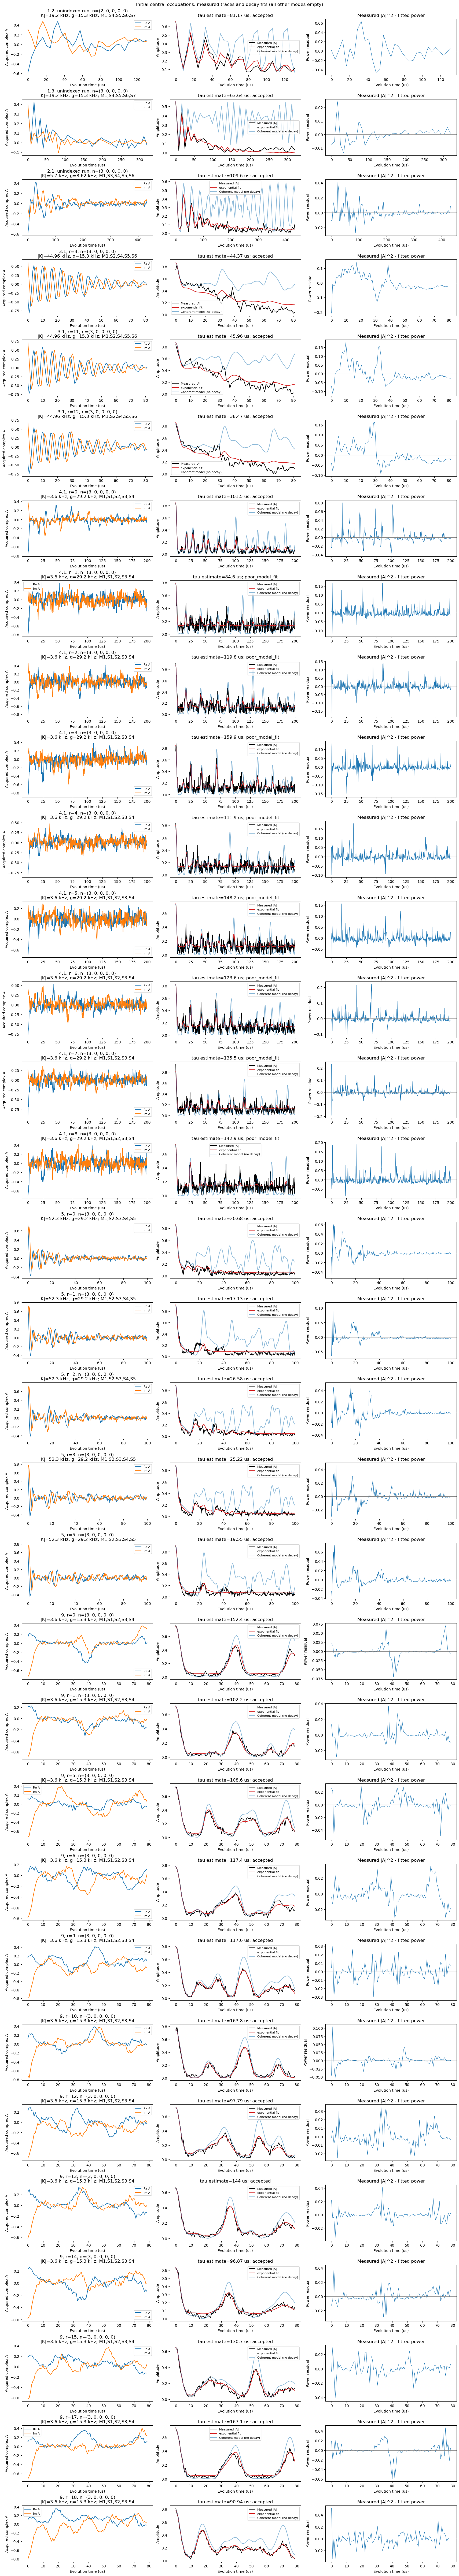

In [25]:
trace_figure = plot_trace_fits(
    fit_results, fit_details, envelope=PLOT_ENVELOPE,
    central_photons=(2, 3), pure_central=TRACE_PURE_CENTRAL,
    dataset_ids=TRACE_DATASET_IDS,
)
plt.show()


## Self-Kerr dependence: overview

Each dot is the arithmetic mean of accepted decay times at the same K, actual g, total N, central photon number, physical mode set, and disorder condition. Error bars show +/- 1 sample SD (ddof=1); n is the number of contributing traces. For n=1, only the mean point is shown. The average pools full occupations and realizations within that condition. Panels share actual g and total N; colors distinguish mode/disorder conditions. The default includes every n_M1=2 or 3 state; set `KERR_PURE_CENTRAL=True` for all other modes empty. The catalog has only one pure n_M1=2 condition, so comparisons across K at n_M1=2 mostly use N=3 states with a storage photon.

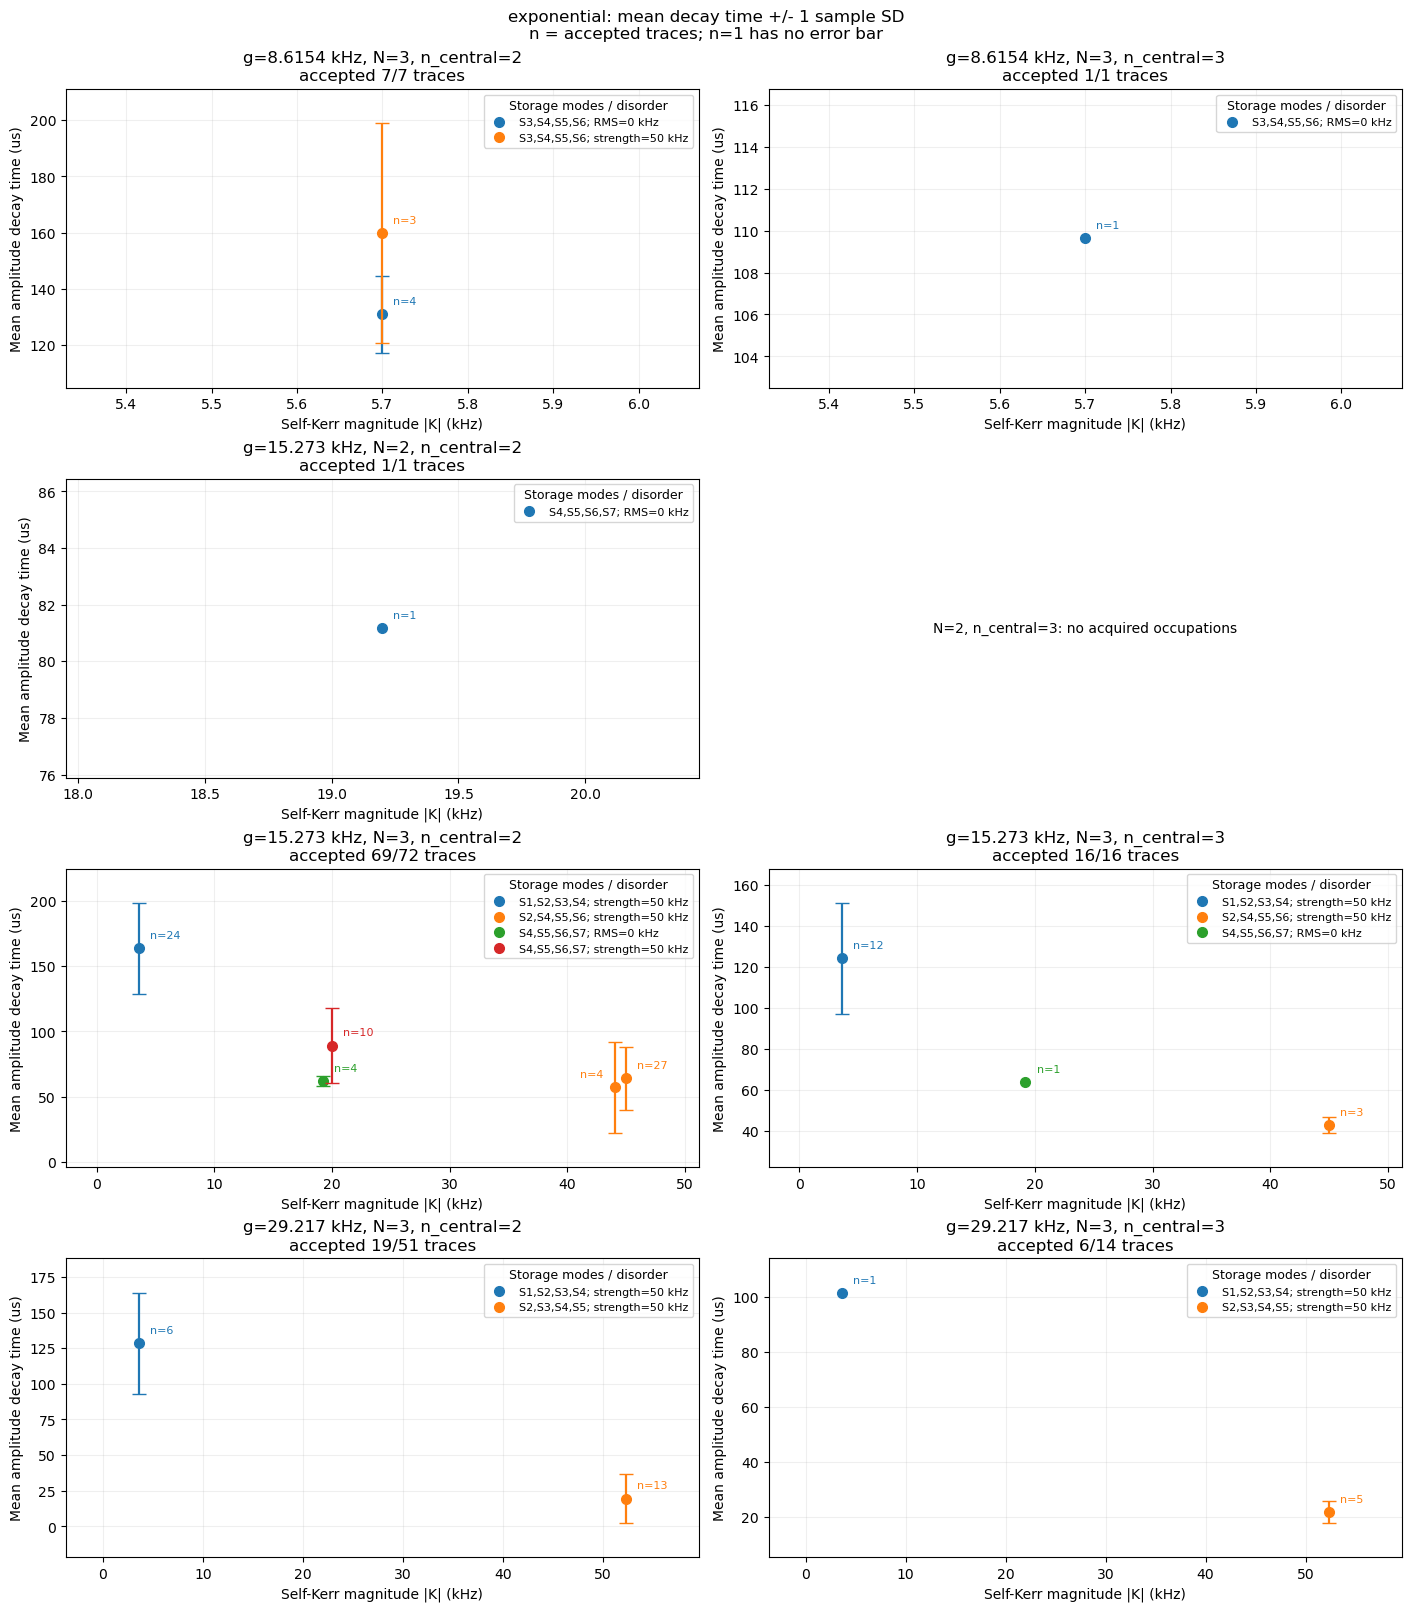

In [26]:
kerr_overview_figure = plot_kerr_overview(
    fit_results, envelope=PLOT_ENVELOPE, pure_central=KERR_PURE_CENTRAL,
)
plt.show()


## Self-Kerr dependence: separate mode sets and disorder

Each full initial occupation has one mean +/- 1 sample SD at each K, averaged across its accepted traces/realizations. Panels separate mode identities and disorder strength; legends identify the full occupation. n=1 has no SD bar. Some panels contain only one K, since the catalog does not supply a controlled Kerr sweep for every condition. Numerical grouping rounds g to 1e-9 kHz and disorder strength to 1e-6 kHz solely to remove floating-point roundoff; unrounded metadata remain in the tables.

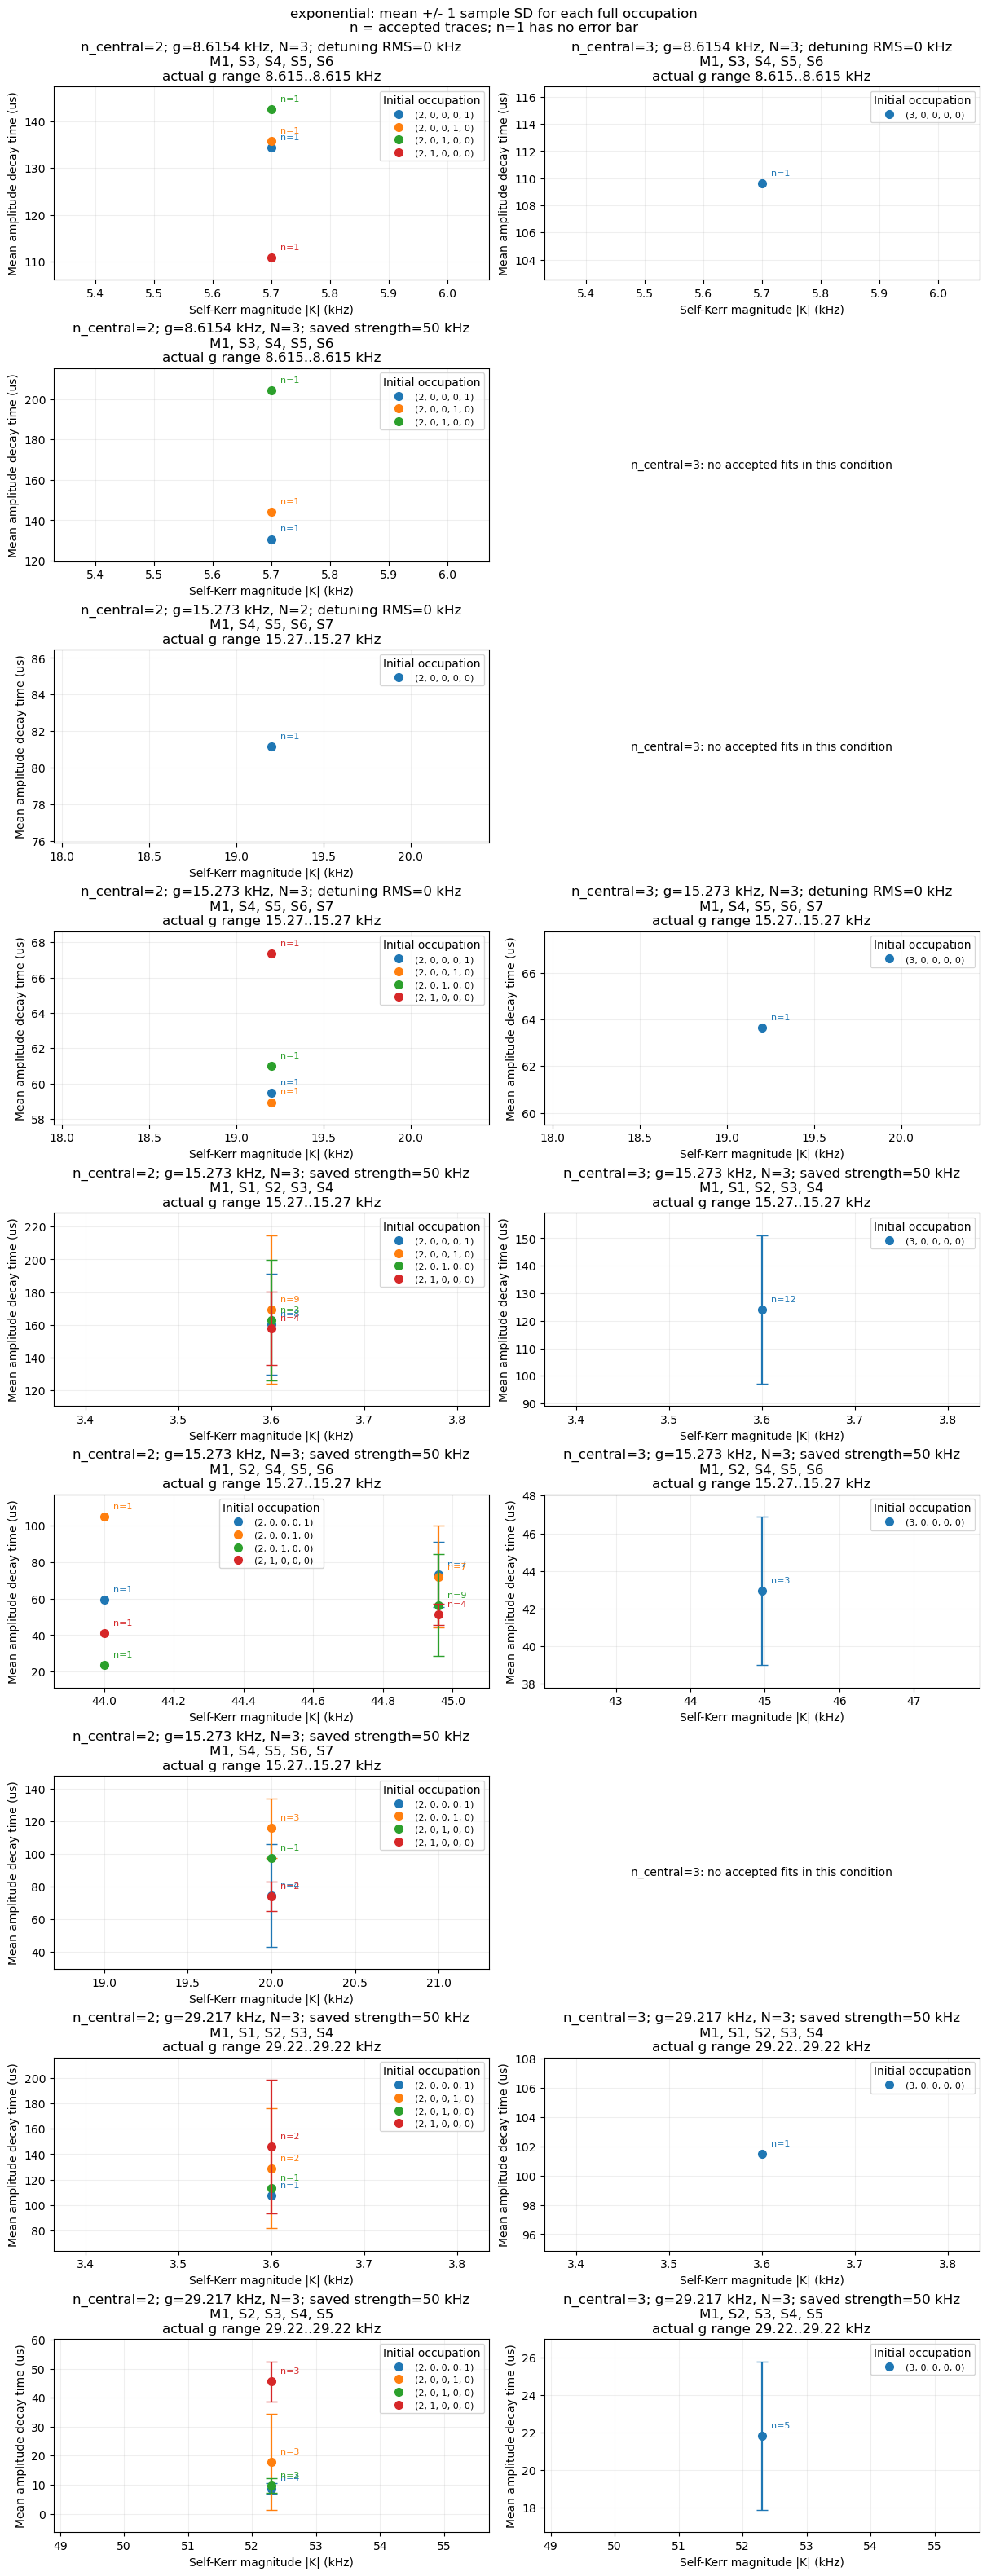

In [27]:
kerr_figure = plot_kerr_dependence(
    fit_results, envelope=PLOT_ENVELOPE, pure_central=KERR_PURE_CENTRAL,
)
plt.show()


## Photon-number dependence at fixed Kerr

At each photon number, one point shows the mean +/- 1 sample SD across accepted traces in the stated K/g/N/mode/disorder condition. n is the trace count; n=1 has no SD bar. Change `PHOTON_VIEW_MODE` to inspect a storage mode. Other modes can have different occupations within the average, so this is a descriptive comparison.

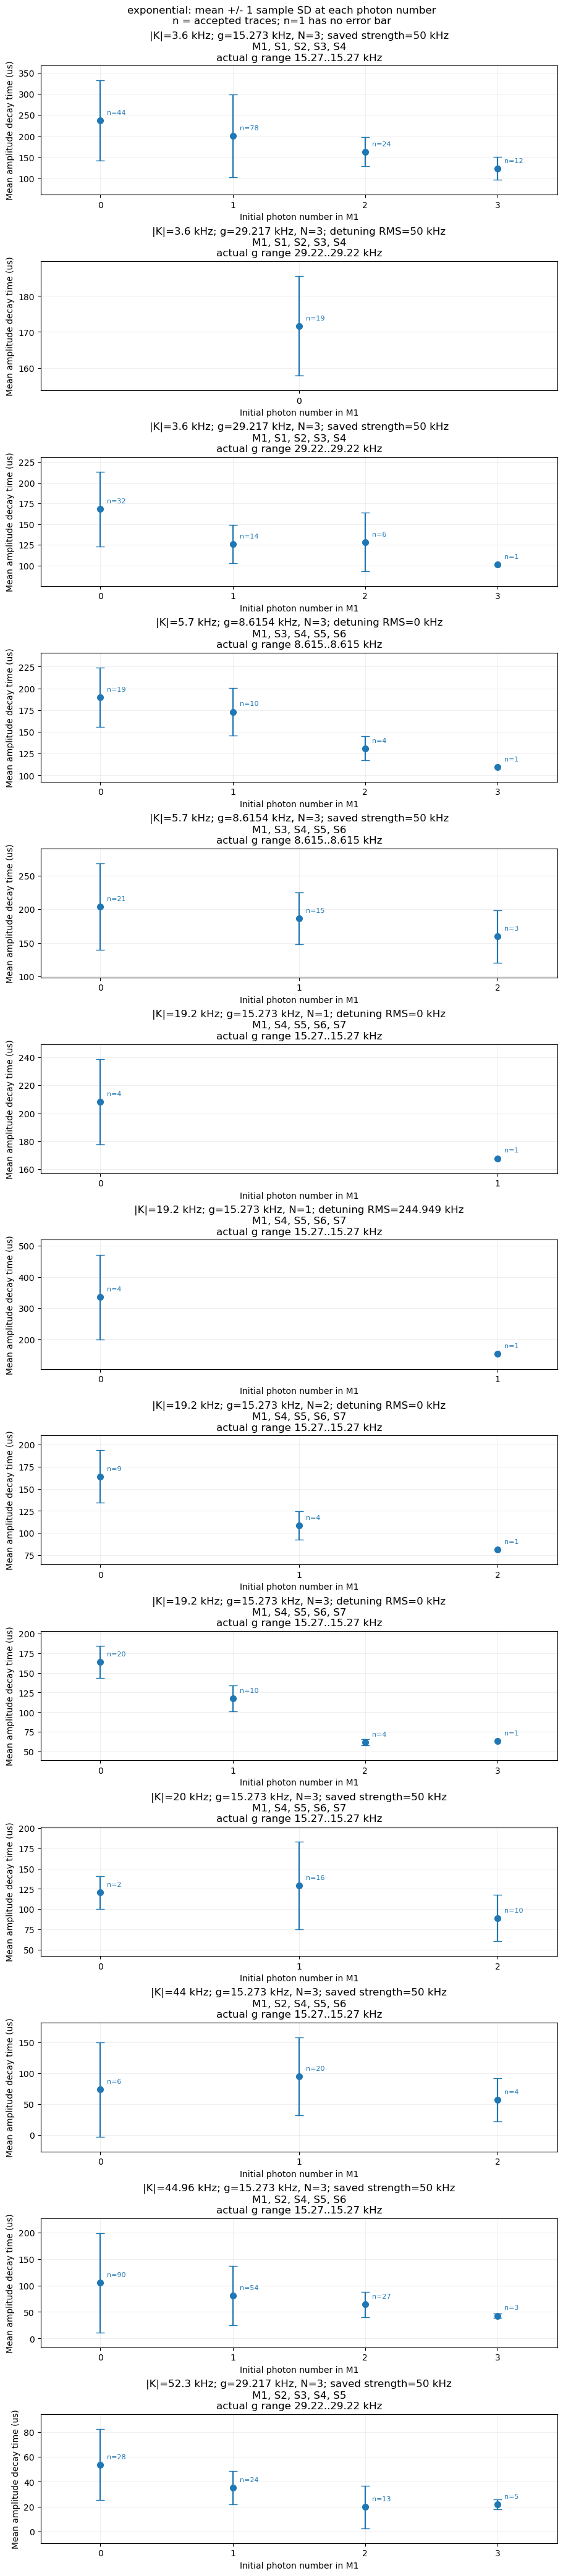

In [28]:
photon_figure = plot_photon_dependence(
    fit_results, mode=PHOTON_VIEW_MODE, envelope=PLOT_ENVELOPE,
)
plt.show()


## Kerr / photon-number map

The map shows arithmetic means of accepted decay times at measured combinations, with contributing trace counts. The color scale uses those means. Empty combinations are left blank. These are descriptive summaries over the other occupations and realizations, not interpolation or a controlled causal estimate.

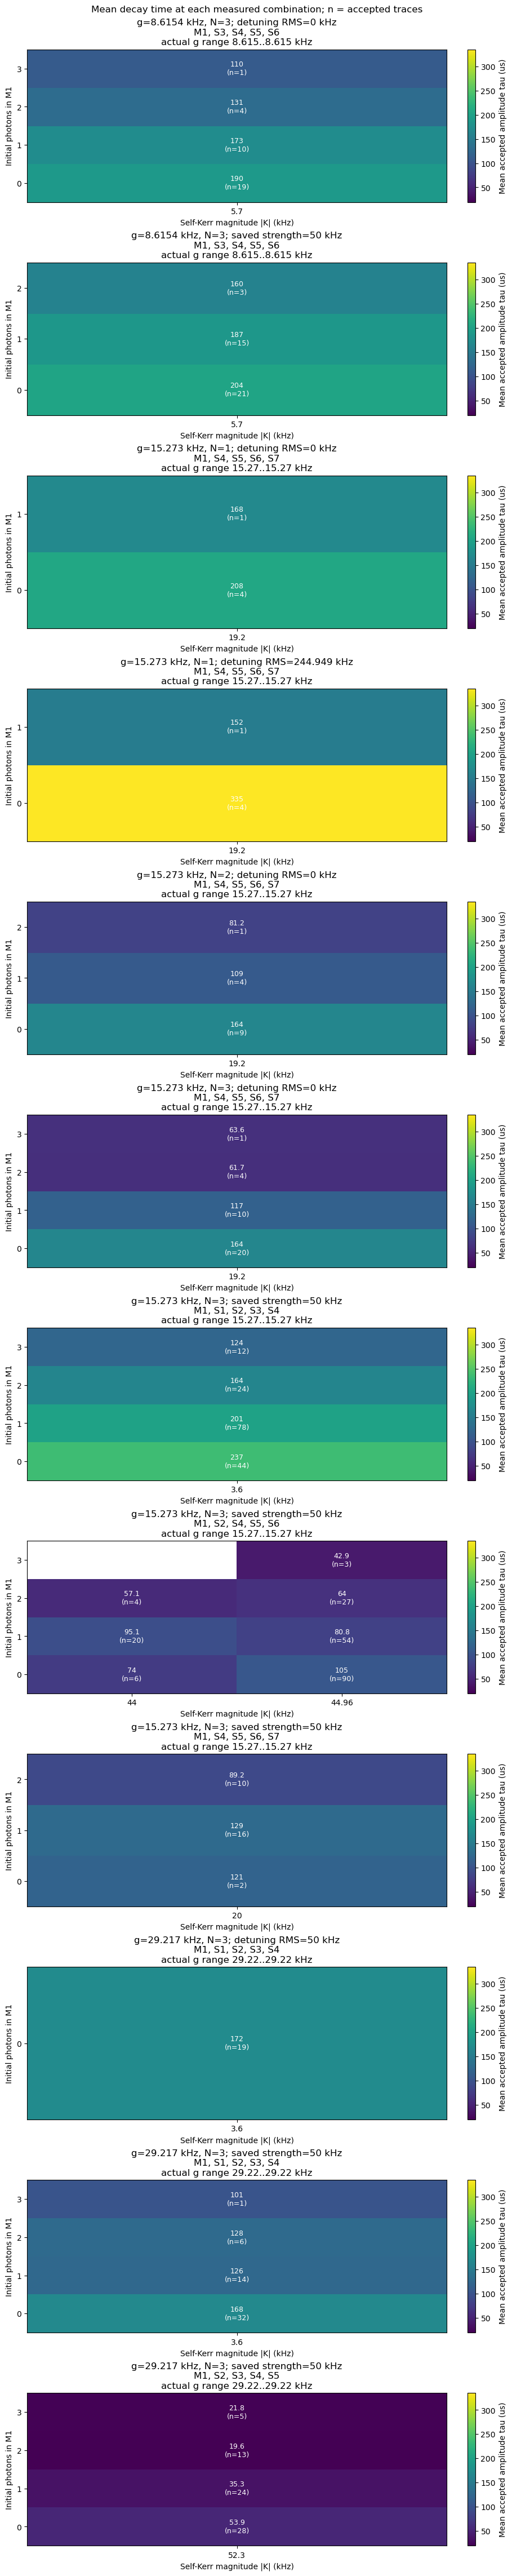

In [29]:
map_figure = plot_decay_map(
    fit_results, mode=PHOTON_VIEW_MODE, envelope=PLOT_ENVELOPE,
)
plt.show()


## Model and window sensitivity

Compare exponential and Gaussian tau and their AICc on the same traces before treating the trend as robust. Both tau values refer to amplitude 1/e, but the envelope shapes differ. For a window check, set `FIT_MAX_US` above and rerun the fit/plot cells; no data are altered.

In [30]:
if not fit_results.empty:
    sensitivity = fit_results.pivot(index="trace_id", columns="envelope",
                                   values=["tau_us", "tau_estimate_us", "aicc", "status"])
    display(sensitivity)

# Access one occupation and its complete JOB provenance without reloading files:
# trace = next(t for t in traces if t["dataset_id"] == "1.3" and t["n_central"] == 3)
# print("Spectroscopy JOB IDs:", ", ".join(trace["job_ids"]))
# print("Calibration reference JOB IDs:", ", ".join(trace["calibration_job_ids"]))
# time_us, complex_A = trace["time_us"], trace["A"]


tau_us              \
envelope                                           exponential    gaussian   
trace_id                                                                     
1.1/r=None/condition=5bbdc101f17c/occupation=(1...  152.396132  121.597859   
1.1/r=None/condition=8241fb57e2da/occupation=(0...  397.063097  199.207212   
1.1/r=None/condition=b6218bc8466c/occupation=(0...  428.035057  202.452566   
1.1/r=None/condition=bfaf01998b20/occupation=(0...  131.495355  118.000843   
1.1/r=None/condition=db5a54b99056/occupation=(0...  382.958884  168.321693   
...                                                        ...         ...   
9/r=9/condition=9b2ad0df5260/occupation=(1, 2, ...  138.865303   98.079515   
9/r=9/condition=a2745ed3d2af/occupation=(0, 0, ...  156.003902  115.546182   
9/r=9/condition=d20387cb2bdb/occupation=(1, 1, ...  178.046762  107.805927   
9/r=9/condition=f216e5c53097/occupation=(3, 0, ...  117.603907   75.448977   
9/r=9/condition=f9f889304947/occupation=(0, 1, ...  604.394355  224.676962   

                                                   tau_estimate_us  \
envelope                                               exponential   
trace_id                                                             
1.1/r=None/condition=5bbdc101f17c/occupation=(1...      152.396132   
1.1/r=None/condition=8241fb57e2da/occupation=(0...      397.063097   
1.1/r=None/condition=b6218bc8466c/occupation=(0...      428.035057   
1.1/r=None/condition=bfaf01998b20/occupation=(0...      131.495355   
1.1/r=None/condition=db5a54b99056/occupation=(0...      382.958884   
...                                                            ...   
9/r=9/condition=9b2ad0df5260/occupation=(1, 2, ...      138.865303   
9/r=9/condition=a2745ed3d2af/occupation=(0, 0, ...      156.003902   
9/r=9/condition=d20387cb2bdb/occupation=(1, 1, ...      178.046762   
9/r=9/condition=f216e5c53097/occupation=(3, 0, ...      117.603907   
9/r=9/condition=f9f889304947/occupation=(0, 1, ...      604.394355   

                                                                      aicc  \
envelope                                              gaussian exponential   
trace_id                                                                     
1.1/r=None/condition=5bbdc101f17c/occupation=(1...  121.597859 -284.677428   
1.1/r=None/condition=8241fb57e2da/occupation=(0...  199.207212  -327.02739   
1.1/r=None/condition=b6218bc8466c/occupation=(0...  202.452566 -320.621303   
1.1/r=None/condition=bfaf01998b20/occupation=(0...  118.000843 -282.646141   
1.1/r=None/condition=db5a54b99056/occupation=(0...  168.321693 -274.243008   
...                                                        ...         ...   
9/r=9/condition=9b2ad0df5260/occupation=(1, 2, ...   98.079515 -728.871156   
9/r=9/condition=a2745ed3d2af/occupation=(0, 0, ...  115.546182  -758.03061   
9/r=9/condition=d20387cb2bdb/occupation=(1, 1, ...  107.805927 -701.268467   
9/r=9/condition=f216e5c53097/occupation=(3, 0, ...   75.448977  -794.98327   
9/r=9/condition=f9f889304947/occupation=(0, 1, ...  224.676962 -572.558077   

                                                                    status  \
envelope                                              gaussian exponential   
trace_id                                                                     
1.1/r=None/condition=5bbdc101f17c/occupation=(1...  -284.04089    accepted   
1.1/r=None/condition=8241fb57e2da/occupation=(0... -306.374558    accepted   
1.1/r=None/condition=b6218bc8466c/occupation=(0... -310.178963    accepted   
1.1/r=None/condition=bfaf01998b20/occupation=(0... -259.953445    accepted   
1.1/r=None/condition=db5a54b99056/occupation=(0... -288.411758    accepted   
...                                                        ...         ...   
9/r=9/condition=9b2ad0df5260/occupation=(1, 2, ... -721.652107    accepted   
9/r=9/condition=a2745ed3d2af/occupation=(0, 0, ... -750.365377    accepted   
9/r=9/condition=d20387cb2bdb/oc